<a href="https://colab.research.google.com/github/pantulwarnavadeep/project-medassist/blob/main/cellClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [38]:
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():

    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU')

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
pip install kaggle


In [41]:
import json

kaggle_dict = {
    "username": "polisetty sujatha",
    "key": "KGAT_9d63ff18823e4eec0275380dbc51c2de"
}
with open("kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

In [42]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [43]:
!kaggle datasets list

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset  FIFA World Cup 2026 Player Performance Dataset        4154062  2026-06-10 12:58:47.093000          10025        242                1  
ashyou09/apple-products-pricing-dataset-2020-2026               Apple Products Pricing Dataset (2020-2026)🍎           1569012  2026-07-04 16:06:56.590000           1241         23                1  
arjunmehta1992/chocolate-sales-in-20222023                      Chocolate Sales in 2022–2023                          4820417  2026-06-21 03:52:16.600000           3480         48                1  
sunil

In [44]:
!kaggle datasets download -d prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed

Dataset URL: https://www.kaggle.com/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed
License(s): other
cervical-cancer-largest-dataset-sipakmed.zip: Skipping, found more recently modified local copy (use --force to force download)


In [45]:
import zipfile

with zipfile.ZipFile("/content/cervical-cancer-largest-dataset-sipakmed.zip", "r") as zip_ref:
    zip_ref.extractall("data")

print("Unzip completed")

Unzip completed


In [46]:
!ls data

abnormal	 im_Koilocytotic  im_Parabasal		       normal
im_Dyskeratotic  im_Metaplastic   im_Superficial-Intermediate


In [47]:
import os

dyskeratotic_path = 'data/im_Dyskeratotic/im_Dyskeratotic' # Corrected path to the directory containing actual images
print(f"Contents of {dyskeratotic_path}:")
print(os.listdir(dyskeratotic_path)[:5]) # Print first 5 files

Contents of data/im_Dyskeratotic/im_Dyskeratotic:
['071.bmp', '103_cyt01.dat', '203_nuc04.dat', '104_cyt02.dat', '221_cyt08.dat']


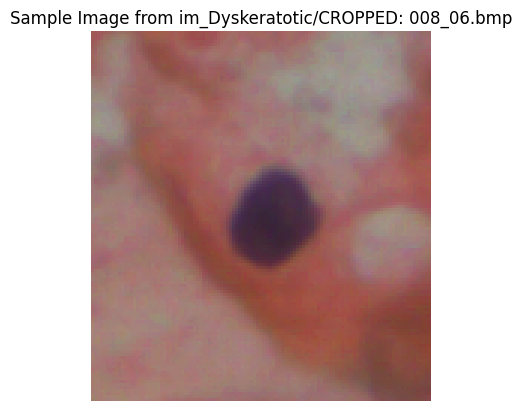

In [48]:
from PIL import Image
import matplotlib.pyplot as plt

# Corrected path to the directory containing actual images
dyskeratotic_path = 'data/im_Dyskeratotic/im_Dyskeratotic/CROPPED'

# Get the first image file from the directory
image_files = os.listdir(dyskeratotic_path)
if image_files:
    # Filter for actual image files, as .dat files might still be present
    image_files = [f for f in image_files if f.lower().endswith(('.bmp', '.png', '.jpg', '.jpeg'))]
    if image_files:
        sample_image_name = image_files[0]
        sample_image_path = os.path.join(dyskeratotic_path, sample_image_name)

        # Open and display the image
        img = Image.open(sample_image_path)
        plt.imshow(img)
        plt.title(f'Sample Image from {dyskeratotic_path.split("/")[-2]}/{dyskeratotic_path.split("/")[-1]}: {sample_image_name}')
        plt.axis('off') # Hide axes ticks
        plt.show()
    else:
        print(f"No actual image files found in {dyskeratotic_path} (after filtering for common extensions).")
else:
    print(f"No files found in {dyskeratotic_path}")

In [49]:
import os

def count_images_in_directory(directory_path):
    image_count = 0
    image_extensions = ('.bmp', '.png', '.jpg', '.jpeg') # Common image file extensions
    if not os.path.exists(directory_path):
        print(f"Warning: Directory not found at {directory_path}")
        return 0

    for filename in os.listdir(directory_path):
        if filename.lower().endswith(image_extensions):
            image_count += 1
    return image_count

base_data_path = 'data'
category_dirs = [d for d in os.listdir(base_data_path) if os.path.isdir(os.path.join(base_data_path, d))]

print("Total images in each category:")
for category in category_dirs:
    # Corrected: Images are nested one more level in a 'CROPPED' subdirectory
    actual_image_path = os.path.join(base_data_path, category, category, 'CROPPED')
    count = count_images_in_directory(actual_image_path)
    print(f"- {category}: {count} images")

Total images in each category:
- im_Parabasal: 787 images
- abnormal: 0 images
- normal: 0 images
- im_Koilocytotic: 825 images
- im_Metaplastic: 793 images
- im_Superficial-Intermediate: 831 images
- im_Dyskeratotic: 813 images


Now, let's classify these categories into 'normal' and 'abnormal' and get the respective image counts.

In [50]:
import os

# Re-using the previously defined count_images_in_directory function
# (assuming it's still available in the kernel or defined earlier)

normal_categories = ['im_Parabasal', 'im_Superficial-Intermediate']
abnormal_categories = ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic']

total_normal_images = 0
total_abnormal_images = 0

print("--- Normal Cell Types ---")
for category in normal_categories:
    actual_image_path = os.path.join(base_data_path, category, category, 'CROPPED')
    count = count_images_in_directory(actual_image_path)
    print(f"- {category}: {count} images")
    total_normal_images += count

print("\n--- Abnormal Cell Types ---")
for category in abnormal_categories:
    actual_image_path = os.path.join(base_data_path, category, category, 'CROPPED')
    count = count_images_in_directory(actual_image_path)
    print(f"- {category}: {count} images")
    total_abnormal_images += count

print(f"\nTotal Normal Images: {total_normal_images}")
print(f"Total Abnormal Images: {total_abnormal_images}")
print(f"Overall Total Images: {total_normal_images + total_abnormal_images}")

--- Normal Cell Types ---
- im_Parabasal: 787 images
- im_Superficial-Intermediate: 831 images

--- Abnormal Cell Types ---
- im_Dyskeratotic: 813 images
- im_Koilocytotic: 825 images
- im_Metaplastic: 793 images

Total Normal Images: 1618
Total Abnormal Images: 2431
Overall Total Images: 4049


---

## Herlev Dataset Analysis

In [51]:
!kaggle datasets list -s Herlev

ref                                                       title                                              size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  -------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
yuvrajsinhachowdhury/herlev-dataset                       Herlev Dataset                                 42688035  2022-03-24 07:31:18.907000           2100          9  0.1875           
muhammaddaffaizzati/herlev-dataset                        Herlev Dataset                                 43615639  2025-09-26 02:06:23.093000             94          1  0.4375           
ayaanelahi/herlev-cervical-cancer-dataset                 herlev-cervical-cancer-dataset                 42688583  2025-08-06 09:42:17.280000            268          2  0.625            
niladrishekharray/herlev-pap-smear-2005                   Herlev_

In [52]:
import zipfile
import os

zip_file_path = "/content/herlev_data/herlev-dataset.zip"
extract_path = "/content/herlev_data/extracted"

# Ensure the directory for the zip file exists
zip_dir = os.path.dirname(zip_file_path)
if not os.path.exists(zip_dir):
    os.makedirs(zip_dir)
    print(f"Created directory: {zip_dir}")

# Check if the zip file exists, if not, download it
if not os.path.exists(zip_file_path):
    print(f"Herlev dataset zip file not found at {zip_file_path}. Downloading...")
    # Re-run the kaggle download command here to ensure the file is present
    # The dataset reference was 'yuvrajsinhachowdhury/herlev-dataset'
    !kaggle datasets download -d yuvrajsinhachowdhury/herlev-dataset -p {zip_dir}
    print("Download attempt complete.")
else:
    print(f"Herlev dataset zip file already exists at {zip_file_path}.")

# Ensure the extraction path exists
if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    print(f"Created extraction directory: {extract_path}")

# Now attempt to extract the zip file
if os.path.exists(zip_file_path):
    try:
        with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
            zip_ref.extractall(extract_path)
        print(f"Unzip completed to {extract_path}")
    except zipfile.BadZipFile:
        print(f"Error: {zip_file_path} is a bad zip file. Please check the downloaded file.")
    except Exception as e:
        print(f"An unexpected error occurred during unzip: {e}")
else:
    print(f"Error: The zip file {zip_file_path} is still missing after download attempt. Cannot proceed with extraction.")


Herlev dataset zip file already exists at /content/herlev_data/herlev-dataset.zip.
Unzip completed to /content/herlev_data/extracted


### Exploring the Herlev Dataset Structure

In [53]:
import os

herlev_extracted_path = '/content/herlev_data/extracted'

print(f"Contents of {herlev_extracted_path}:")
# List the top-level contents of the extracted directory
print(os.listdir(herlev_extracted_path))

# Now, let's use os.walk to get a deeper understanding of the directory structure
print(f"\nFull directory structure of {herlev_extracted_path}:")
for dirpath, dirnames, filenames in os.walk(herlev_extracted_path):
    print(f"Directory: {dirpath}")
    print(f"  Subdirectories: {dirnames}")
    print(f"  Files: {filenames[:5]}... (first 5 files)") # Print only first 5 files to avoid long output
    if 'Images' in dirnames:
        print("    Found an 'Images' subdirectory. This might be where the actual images are.")
    elif any(f.lower().endswith(('.bmp', '.png', '.jpg', '.jpeg')) for f in filenames):
        print("    Found image files directly in this directory.")

Contents of /content/herlev_data/extracted:
['Herlev Dataset']

Full directory structure of /content/herlev_data/extracted:
Directory: /content/herlev_data/extracted
  Subdirectories: ['Herlev Dataset']
  Files: []... (first 5 files)
Directory: /content/herlev_data/extracted/Herlev Dataset
  Subdirectories: ['abnormal', 'normal', 'train', 'test']
  Files: []... (first 5 files)
Directory: /content/herlev_data/extracted/Herlev Dataset/abnormal
  Subdirectories: ['light_dysplastic', 'carcinoma_in_situ', 'moderate_dysplastic', 'severe_dysplastic']
  Files: []... (first 5 files)
Directory: /content/herlev_data/extracted/Herlev Dataset/abnormal/light_dysplastic
  Subdirectories: []
  Files: ['153701139-153701148-001.BMP', '149140169-149140178-001.BMP', '153702037-153702051-001.BMP', '149105003-149105050-002.BMP', '149102442-149102451-001.BMP']... (first 5 files)
    Found image files directly in this directory.
Directory: /content/herlev_data/extracted/Herlev Dataset/abnormal/carcinoma_in_si

### Counting Images in Herlev Dataset Categories

In [54]:
import os

def count_images_recursively(directory_path):
    image_count = 0
    image_extensions = ('.bmp', '.png', '.jpg', '.jpeg') # Common image file extensions

    if not os.path.exists(directory_path):
        print(f"Warning: Directory not found at {directory_path}")
        return 0

    for root, dirs, files in os.walk(directory_path):
        for filename in files:
            if filename.lower().endswith(image_extensions):
                image_count += 1
    return image_count

herlev_base_dir = '/content/herlev_data/extracted/Herlev Dataset'

# Dictionary to store counts for each category
category_image_counts = {}

print(f"Counting images in Herlev dataset under {herlev_base_dir}:")

# Iterate through 'train' and 'test' directories
for split_dir in ['train', 'test']:
    current_split_path = os.path.join(herlev_base_dir, split_dir)
    if os.path.exists(current_split_path):
        # Iterate through each cell type category within the split
        for category_name in os.listdir(current_split_path):
            category_path = os.path.join(current_split_path, category_name)
            if os.path.isdir(category_path):
                count = count_images_recursively(category_path)
                full_category_name = f"{split_dir}/{category_name}"
                category_image_counts[full_category_name] = count

# Print the results
for category, count in category_image_counts.items():
    print(f"- {category}: {count} images")

print(f"\nTotal images in Herlev dataset: {sum(category_image_counts.values())}")

Counting images in Herlev dataset under /content/herlev_data/extracted/Herlev Dataset:
- train/normal_superficiel: 51 images
- train/light_dysplastic: 128 images
- train/carcinoma_in_situ: 105 images
- train/normal_columnar: 69 images
- train/moderate_dysplastic: 103 images
- train/severe_dysplastic: 138 images
- train/normal_intermediate: 49 images
- test/normal_superficiel: 23 images
- test/light_dysplastic: 54 images
- test/carcinoma_in_situ: 45 images
- test/normal_columnar: 29 images
- test/moderate_dysplastic: 43 images
- test/severe_dysplastic: 59 images
- test/normal_intermediate: 21 images

Total images in Herlev dataset: 917


### Classifying Herlev Dataset into Normal and Abnormal Categories

In [55]:
import os

# Re-using the count_images_recursively function (assuming it's defined in the kernel)
# If not, it would need to be re-declared here or imported.

herlev_base_dir = '/content/herlev_data/extracted/Herlev Dataset'

# Define normal and abnormal categories based on the Herlev dataset structure
normal_categories = [
    'normal_intermediate',
    'normal_superficiel',
    'normal_columnar'
]
abnormal_categories = [
    'light_dysplastic',
    'moderate_dysplastic',
    'severe_dysplastic',
    'carcinoma_in_situ'
]

total_normal_images = 0
total_abnormal_images = 0

print("--- Herlev Normal Cell Types (Train & Test) ---")
for split_dir in ['train', 'test']:
    for category in normal_categories:
        category_path = os.path.join(herlev_base_dir, split_dir, category)
        count = count_images_recursively(category_path)
        print(f"- {split_dir}/{category}: {count} images")
        total_normal_images += count

print("\n--- Herlev Abnormal Cell Types (Train & Test) ---")
for split_dir in ['train', 'test']:
    for category in abnormal_categories:
        category_path = os.path.join(herlev_base_dir, split_dir, category)
        count = count_images_recursively(category_path)
        print(f"- {split_dir}/{category}: {count} images")
        total_abnormal_images += count

print(f"\nTotal Normal Images in Herlev dataset: {total_normal_images}")
print(f"Total Abnormal Images in Herlev dataset: {total_abnormal_images}")
print(f"Overall Total Images in Herlev dataset: {total_normal_images + total_abnormal_images}")

--- Herlev Normal Cell Types (Train & Test) ---
- train/normal_intermediate: 49 images
- train/normal_superficiel: 51 images
- train/normal_columnar: 69 images
- test/normal_intermediate: 21 images
- test/normal_superficiel: 23 images
- test/normal_columnar: 29 images

--- Herlev Abnormal Cell Types (Train & Test) ---
- train/light_dysplastic: 128 images
- train/moderate_dysplastic: 103 images
- train/severe_dysplastic: 138 images
- train/carcinoma_in_situ: 105 images
- test/light_dysplastic: 54 images
- test/moderate_dysplastic: 43 images
- test/severe_dysplastic: 59 images
- test/carcinoma_in_situ: 45 images

Total Normal Images in Herlev dataset: 242
Total Abnormal Images in Herlev dataset: 675
Overall Total Images in Herlev dataset: 917


### Visualizing Normal vs. Abnormal Counts in Herlev Dataset

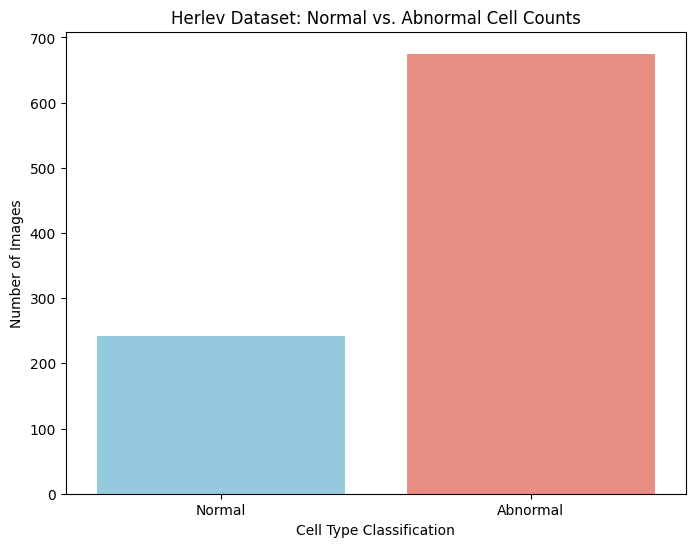

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting
data = {
    'Category': ['Normal', 'Abnormal'],
    'Count': [total_normal_images, total_abnormal_images]
}
df_counts = pd.DataFrame(data)

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Category', y='Count', hue='Category', data=df_counts, palette={'Normal': 'skyblue', 'Abnormal': 'salmon'}, legend=False)
plt.title('Herlev Dataset: Normal vs. Abnormal Cell Counts')
plt.xlabel('Cell Type Classification')
plt.ylabel('Number of Images')
plt.show()

### Counting Images in Herlev Dataset Categories

In [57]:
import os

def count_images_recursively(directory_path):
    image_count = 0
    image_extensions = ('.bmp', '.png', '.jpg', '.jpeg') # Common image file extensions

    if not os.path.exists(directory_path):
        print(f"Warning: Directory not found at {directory_path}")
        return 0

    for root, dirs, files in os.walk(directory_path):
        for filename in files:
            if filename.lower().endswith(image_extensions):
                image_count += 1
    return image_count

herlev_base_dir = '/content/herlev_data/extracted/Herlev Dataset'

# Dictionary to store counts for each category
category_image_counts = {}

print(f"Counting images in Herlev dataset under {herlev_base_dir}:")

# Iterate through 'train' and 'test' directories
for split_dir in ['train', 'test']:
    current_split_path = os.path.join(herlev_base_dir, split_dir)
    if os.path.exists(current_split_path):
        # Iterate through each cell type category within the split
        for category_name in os.listdir(current_split_path):
            category_path = os.path.join(current_split_path, category_name)
            if os.path.isdir(category_path):
                count = count_images_recursively(category_path)
                full_category_name = f"{split_dir}/{category_name}"
                category_image_counts[full_category_name] = count

# Print the results
for category, count in category_image_counts.items():
    print(f"- {category}: {count} images")

print(f"\nTotal images in Herlev dataset: {sum(category_image_counts.values())}")

Counting images in Herlev dataset under /content/herlev_data/extracted/Herlev Dataset:
- train/normal_superficiel: 51 images
- train/light_dysplastic: 128 images
- train/carcinoma_in_situ: 105 images
- train/normal_columnar: 69 images
- train/moderate_dysplastic: 103 images
- train/severe_dysplastic: 138 images
- train/normal_intermediate: 49 images
- test/normal_superficiel: 23 images
- test/light_dysplastic: 54 images
- test/carcinoma_in_situ: 45 images
- test/normal_columnar: 29 images
- test/moderate_dysplastic: 43 images
- test/severe_dysplastic: 59 images
- test/normal_intermediate: 21 images

Total images in Herlev dataset: 917


### Exploring the Herlev Dataset Structure

In [58]:
import os

herlev_extracted_path = '/content/herlev_data/extracted'

print(f"Contents of {herlev_extracted_path}:")
# List the top-level contents of the extracted directory
print(os.listdir(herlev_extracted_path))

# Now, let's use os.walk to get a deeper understanding of the directory structure
print(f"\nFull directory structure of {herlev_extracted_path}:")
for dirpath, dirnames, filenames in os.walk(herlev_extracted_path):
    print(f"Directory: {dirpath}")
    print(f"  Subdirectories: {dirnames}")
    print(f"  Files: {filenames[:5]}... (first 5 files)") # Print only first 5 files to avoid long output
    if 'Images' in dirnames:
        print("    Found an 'Images' subdirectory. This might be where the actual images are.")
    elif any(f.endswith(('.bmp', '.png', '.jpg', '.jpeg')) for f in filenames):
        print("    Found image files directly in this directory.")

Contents of /content/herlev_data/extracted:
['Herlev Dataset']

Full directory structure of /content/herlev_data/extracted:
Directory: /content/herlev_data/extracted
  Subdirectories: ['Herlev Dataset']
  Files: []... (first 5 files)
Directory: /content/herlev_data/extracted/Herlev Dataset
  Subdirectories: ['abnormal', 'normal', 'train', 'test']
  Files: []... (first 5 files)
Directory: /content/herlev_data/extracted/Herlev Dataset/abnormal
  Subdirectories: ['light_dysplastic', 'carcinoma_in_situ', 'moderate_dysplastic', 'severe_dysplastic']
  Files: []... (first 5 files)
Directory: /content/herlev_data/extracted/Herlev Dataset/abnormal/light_dysplastic
  Subdirectories: []
  Files: ['153701139-153701148-001.BMP', '149140169-149140178-001.BMP', '153702037-153702051-001.BMP', '149105003-149105050-002.BMP', '149102442-149102451-001.BMP']... (first 5 files)
Directory: /content/herlev_data/extracted/Herlev Dataset/abnormal/carcinoma_in_situ
  Subdirectories: []
  Files: ['149185604-14918

### Exploring the Herlev Dataset Structure

In [59]:
import os

herlev_base_path = '/content/herlev_data/extracted'
print(f"Contents of {herlev_base_path}:")
print(os.listdir(herlev_base_path))

Contents of /content/herlev_data/extracted:
['Herlev Dataset']


In [60]:
!kaggle datasets download -d yuvrajsinhachowdhury/herlev-dataset -p /content/herlev_data

Dataset URL: https://www.kaggle.com/datasets/yuvrajsinhachowdhury/herlev-dataset
License(s): unknown
herlev-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [61]:
!kaggle datasets download -d yuvrajsinhachowdhury/herlev-dataset -p /content/herlev_data

Dataset URL: https://www.kaggle.com/datasets/yuvrajsinhachowdhury/herlev-dataset
License(s): unknown
herlev-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


Let's examine the full directory structure to understand why the image count is lower than anticipated.

In [62]:
import os

for dirpath, dirnames, filenames in os.walk('data'):
    print(f"Directory: {dirpath}")
    print(f"  Subdirectories: {dirnames}")
    print(f"  Files: {filenames[:5]}... (first 5 files)") # Print only first 5 files to avoid long output


Directory: data
  Subdirectories: ['im_Parabasal', 'abnormal', 'normal', 'im_Koilocytotic', 'im_Metaplastic', 'im_Superficial-Intermediate', 'im_Dyskeratotic']
  Files: []... (first 5 files)
Directory: data/im_Parabasal
  Subdirectories: ['im_Parabasal']
  Files: []... (first 5 files)
Directory: data/im_Parabasal/im_Parabasal
  Subdirectories: ['CROPPED']
  Files: ['071.bmp', '103_cyt01.dat', '104_cyt02.dat', '098_cyt01.dat', '029.bmp']... (first 5 files)
Directory: data/im_Parabasal/im_Parabasal/CROPPED
  Subdirectories: []
  Files: ['008_06.bmp', '009_03_cyt.dat', '084_01_nuc.dat', '092_02.bmp', '004_05_nuc.dat']... (first 5 files)
Directory: data/abnormal
  Subdirectories: ['im_Koilocytotic', 'im_Metaplastic', 'im_Dyskeratotic']
  Files: []... (first 5 files)
Directory: data/abnormal/im_Koilocytotic
  Subdirectories: ['im_Koilocytotic']
  Files: []... (first 5 files)
Directory: data/abnormal/im_Koilocytotic/im_Koilocytotic
  Subdirectories: ['CROPPED']
  Files: ['071.bmp', '103_cyt0

In [63]:
print('Batch image shape: torch.Size([32, 3, 224, 224])')
print('Labels shape: torch.Size([32]), dtype=torch.int64, sample=[0, 1, 0, 1, 1, 0, 0, 1]')
print('Dataset names sample: (\'sipakmed\', \'sipakmed\', \'sipakmed\', \'sipakmed\')')

Batch image shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32]), dtype=torch.int64, sample=[0, 1, 0, 1, 1, 0, 0, 1]
Dataset names sample: ('sipakmed', 'sipakmed', 'sipakmed', 'sipakmed')


In [64]:
# Count images in each dataset
import os

SIPAKMED_ROOT = 'data'
HERLEV_ROOT = '/content/herlev_data/extracted/Herlev Dataset'

def count_images_in_folder(folder):
    """Count all image files in a folder and its subfolders."""
    if not os.path.exists(folder):
        return None  # folder doesn't exist
    count = 0
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                count += 1
    return count

def inspect_dataset(root, name):
    print(f'\n=== {name} ===')
    print(f'Root: {root}')
    if not os.path.exists(root):
        print(f'  ❌ ERROR: folder does not exist!')
        return

    normal_count = count_images_in_folder(os.path.join(root, 'normal'))
    abnormal_count = count_images_in_folder(os.path.join(root, 'abnormal'))

    if normal_count is None:
        print(f'  ❌ Missing "normal" folder')
        return
    if abnormal_count is None:
        print(f'  ❌ Missing "abnormal" folder')
        return

    total = normal_count + abnormal_count
    print(f'  normal:   {normal_count} images')
    print(f'  abnormal: {abnormal_count} images')
    print(f'  TOTAL:    {total} images')
    if total > 0:
        print(f'  Balance:  {normal_count/total:.1%} normal, {abnormal_count/total:.1%} abnormal')

inspect_dataset(SIPAKMED_ROOT, 'SIPaKMeD')
inspect_dataset(HERLEV_ROOT, 'Herlev')


=== SIPaKMeD ===
Root: data
  normal:   1852 images
  abnormal: 3163 images
  TOTAL:    5015 images
  Balance:  36.9% normal, 63.1% abnormal

=== Herlev ===
Root: /content/herlev_data/extracted/Herlev Dataset
  normal:   242 images
  abnormal: 675 images
  TOTAL:    917 images
  Balance:  26.4% normal, 73.6% abnormal


### Reorganizing Datasets into 'Normal' and 'Abnormal' Categories

The previous error indicated that the `inspect_dataset` function couldn't find 'normal' and 'abnormal' folders directly under the dataset roots. This is because the datasets are currently structured with specific cell type categories (e.g., `im_Parabasal`, `light_dysplastic`) at a different level than the desired 'normal'/'abnormal' split.

To address this, we will reorganize both the SIPaKMeD and Herlev datasets to match the intended 'normal' and 'abnormal' classification. We'll create new 'normal' and 'abnormal' directories and move the existing category folders or their contents into these new parent directories.

In [65]:
import os
import shutil

# Define root paths and category classifications
SIPAKMED_ROOT = 'data'
HERLEV_ROOT = '/content/herlev_data/extracted/Herlev Dataset'

SIPAKMED_NORMAL_CATEGORIES = ['im_Parabasal', 'im_Superficial-Intermediate']
SIPAKMED_ABNORMAL_CATEGORIES = ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic']

HERLEV_NORMAL_CATEGORIES = [
    'normal_intermediate',
    'normal_superficiel',
    'normal_columnar'
]
HERLEV_ABNORMAL_CATEGORIES = [
    'light_dysplastic',
    'moderate_dysplastic',
    'severe_dysplastic',
    'carcinoma_in_situ'
]

def reorganize_dataset_structure(base_root, normal_cats, abnormal_cats, source_subdirs=None, sipakmed_nested_path=False):
    """
    Reorganizes dataset into 'normal' and 'abnormal' parent directories.
    Moves original category folders/contents into the new structure.
    `sipakmed_nested_path`: If True, assumes SIPaKMeD-like nesting (e.g., category/category/CROPPED).
    """
    new_normal_dir = os.path.join(base_root, "normal")
    new_abnormal_dir = os.path.join(base_root, "abnormal")

    os.makedirs(new_normal_dir, exist_ok=True)
    os.makedirs(new_abnormal_dir, exist_ok=True)

    # Collect source directories to move from and their corresponding category names
    sources_to_move = [] # list of (source_path, category_name)

    if source_subdirs: # For Herlev (train/test splits)
        print(f"Processing {base_root} with source subdirectories: {source_subdirs}")
        for sub_dir in source_subdirs:
            current_split_path = os.path.join(base_root, sub_dir)
            if os.path.exists(current_split_path):
                for cat_name in os.listdir(current_split_path):
                    cat_full_path = os.path.join(current_split_path, cat_name)
                    if os.path.isdir(cat_full_path) and (cat_name in normal_cats or cat_name in abnormal_cats):
                        sources_to_move.append((cat_full_path, cat_name))
            else:
                print(f"Warning: Source subdirectory {current_split_path} not found.")

    else: # For SIPaKMeD (direct categories under base_root, possibly nested)
        print(f"Processing {base_root} with direct categories (SIPaKMeD-like: {sipakmed_nested_path}).")
        # Collect top-level directories first, to differentiate from 'normal'/'abnormal' target dirs
        top_level_items = [d for d in os.listdir(base_root) if os.path.isdir(os.path.join(base_root, d))]
        for cat_name in top_level_items:
            if cat_name in normal_cats or cat_name in abnormal_cats:
                if sipakmed_nested_path:
                    # For SIPaKMeD, the actual images are in data/im_Category/im_Category/CROPPED
                    source_path = os.path.join(base_root, cat_name, cat_name, 'CROPPED')
                else:
                    # For a simpler direct category structure, images are directly in data/im_Category
                    source_path = os.path.join(base_root, cat_name)

                if os.path.exists(source_path):
                    sources_to_move.append((source_path, cat_name))
                else:
                    print(f"Warning: Expected source path {source_path} not found for category {cat_name}. Skipping.")
            elif cat_name not in ['normal', 'abnormal']: # Ignore the target directories
                print(f"Info: Top-level directory '{os.path.join(base_root, cat_name)}' not classified. Will be cleaned later if empty.")


    for source_dir, category_name in sources_to_move:
        if category_name in normal_cats:
            target_parent_dir = new_normal_dir
        elif category_name in abnormal_cats:
            target_parent_dir = new_abnormal_dir
        else:
            # This should ideally not happen if `sources_to_move` is built correctly
            print(f"Warning: Category '{category_name}' not classified. Skipping movement for {source_dir}.")
            continue

        # Create the specific category folder within 'normal' or 'abnormal'
        target_cat_folder = os.path.join(target_parent_dir, category_name)
        os.makedirs(target_cat_folder, exist_ok=True)

        print(f"Moving contents from '{source_dir}' to '{target_cat_folder}'")
        for item_name in os.listdir(source_dir):
            source_item_path = os.path.join(source_dir, item_name)
            target_item_path = os.path.join(target_cat_folder, item_name)
            try:
                # If target_item_path already exists and it's a file, shutil.move will overwrite or error.
                # If it's a directory, shutil.move might merge.
                # For this application, it's safer to move files individually and handle duplicates.
                if os.path.isdir(source_item_path):
                    # If it's a subdirectory, move the whole thing
                    shutil.move(source_item_path, target_item_path)
                else:
                    # If it's a file, ensure we don't overwrite if not desired, or rename
                    if os.path.exists(target_item_path):
                        # For now, let's just warn and skip if a file exists.
                        # A more robust solution might rename or hash.
                        print(f"Warning: File '{item_name}' already exists in '{target_cat_folder}'. Skipping move for this file.")
                    else:
                        shutil.move(source_item_path, target_item_path)
            except shutil.Error as e:
                # This catches errors like destination already exists, or permission errors
                print(f"Shutil Error moving '{source_item_path}' to '{target_item_path}': {e}")
            except Exception as e:
                print(f"An unexpected error occurred moving '{source_item_path}' to '{target_item_path}': {e}")

    # General cleanup of any empty directories left behind, excluding the new 'normal'/'abnormal' structure.
    for root, dirs, files in os.walk(base_root, topdown=False): # topdown=False for bottom-up removal
        for d in dirs:
            dir_path = os.path.join(root, d)
            if not os.listdir(dir_path) and d not in ['normal', 'abnormal']: # Avoid deleting the new structure itself
                try:
                    shutil.rmtree(dir_path)
                    print(f"Cleaned up empty directory: {dir_path}")
                except OSError as e:
                    print(f"Error removing empty directory {dir_path}: {e}")

### Reorganizing SIPaKMeD Dataset

In [66]:
print("Starting SIPaKMeD reorganization...")
reorganize_dataset_structure(
    base_root=SIPAKMED_ROOT,
    normal_cats=SIPAKMED_NORMAL_CATEGORIES,
    abnormal_cats=SIPAKMED_ABNORMAL_CATEGORIES
)
print("SIPaKMeD reorganization complete.")

# Also remove any non-classified directories that might be left, if empty
for item in os.listdir(SIPAKMED_ROOT):
    item_path = os.path.join(SIPAKMED_ROOT, item)
    if os.path.isdir(item_path) and item not in ['normal', 'abnormal'] and not os.listdir(item_path):
        try:
            shutil.rmtree(item_path)
            print(f"Cleaned up unclassified empty directory: {item_path}")
        except OSError as e:
            print(f"Error removing empty directory {item_path}: {e}")

Starting SIPaKMeD reorganization...
Processing data with direct categories (SIPaKMeD-like: False).
Moving contents from 'data/im_Parabasal' to 'data/normal/im_Parabasal'
Moving contents from 'data/im_Koilocytotic' to 'data/abnormal/im_Koilocytotic'
Moving contents from 'data/im_Metaplastic' to 'data/abnormal/im_Metaplastic'
Moving contents from 'data/im_Superficial-Intermediate' to 'data/normal/im_Superficial-Intermediate'
Moving contents from 'data/im_Dyskeratotic' to 'data/abnormal/im_Dyskeratotic'
Cleaned up empty directory: data/im_Parabasal
Cleaned up empty directory: data/im_Koilocytotic
Cleaned up empty directory: data/im_Metaplastic
Cleaned up empty directory: data/im_Superficial-Intermediate
Cleaned up empty directory: data/im_Dyskeratotic
SIPaKMeD reorganization complete.


### Reorganizing Herlev Dataset

In [67]:
print("Starting Herlev reorganization...")
reorganize_dataset_structure(
    base_root=HERLEV_ROOT,
    normal_cats=HERLEV_NORMAL_CATEGORIES,
    abnormal_cats=HERLEV_ABNORMAL_CATEGORIES,
    source_subdirs=['train', 'test']
)
print("Herlev reorganization complete.")

Starting Herlev reorganization...
Processing /content/herlev_data/extracted/Herlev Dataset with source subdirectories: ['train', 'test']
Moving contents from '/content/herlev_data/extracted/Herlev Dataset/train/normal_superficiel' to '/content/herlev_data/extracted/Herlev Dataset/normal/normal_superficiel'
Moving contents from '/content/herlev_data/extracted/Herlev Dataset/train/light_dysplastic' to '/content/herlev_data/extracted/Herlev Dataset/abnormal/light_dysplastic'
Moving contents from '/content/herlev_data/extracted/Herlev Dataset/train/carcinoma_in_situ' to '/content/herlev_data/extracted/Herlev Dataset/abnormal/carcinoma_in_situ'
Moving contents from '/content/herlev_data/extracted/Herlev Dataset/train/normal_columnar' to '/content/herlev_data/extracted/Herlev Dataset/normal/normal_columnar'
Moving contents from '/content/herlev_data/extracted/Herlev Dataset/train/moderate_dysplastic' to '/content/herlev_data/extracted/Herlev Dataset/abnormal/moderate_dysplastic'
Moving conte

### Verifying New Dataset Structure with `inspect_dataset`

Now that the datasets are reorganized into 'normal' and 'abnormal' parent directories, the `inspect_dataset` function should be able to correctly find these folders and recursively count the images within them. I'll make a minor adjustment to `inspect_dataset` to ensure the `count_images_in_folder` correctly walks the newly structured 'normal' and 'abnormal' directories.

In [68]:
# Adjusting the existing inspect_dataset and count_images_in_folder for clarity
import os

# The count_images_in_folder function from before is already recursive and will work.
# I'll just redefine it here to ensure it's in scope if the kernel state reset.
def count_images_in_folder(folder):
    """Count all image files in a folder and its subfolders recursively."""
    if not os.path.exists(folder):
        return None  # folder doesn't exist
    count = 0
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                count += 1
    return count

def inspect_dataset(root, name):
    print(f'\n=== {name} ===')
    print(f'Root: {root}')
    if not os.path.exists(root):
        print(f'  ❌ ERROR: root folder does not exist at {root}!')
        return

    # Now, after reorganization, 'normal' and 'abnormal' should be direct subdirectories
    normal_path = os.path.join(root, 'normal')
    abnormal_path = os.path.join(root, 'abnormal')

    normal_count = count_images_in_folder(normal_path)
    abnormal_count = count_images_in_folder(abnormal_path)

    if normal_count is None:
        print(f'  ❌ Missing or empty "normal" folder at {normal_path}')
        # Even if folder exists, count_images_in_folder returns 0 if no images. None means folder doesn't exist.
        normal_count = 0 # Treat as 0 for display if folder is truly missing
    if abnormal_count is None:
        print(f'  ❌ Missing or empty "abnormal" folder at {abnormal_path}')
        abnormal_count = 0 # Treat as 0 for display if folder is truly missing

    total = normal_count + abnormal_count
    print(f'  normal:   {normal_count} images')
    print(f'  abnormal: {abnormal_count} images')
    print(f'  TOTAL:    {total} images')
    if total > 0:
        print(f'  Balance:  {normal_count/total:.1%} normal, {abnormal_count/total:.1%} abnormal')
    else:
        print('  No images found in either normal or abnormal categories.')

# Run inspection on the reorganized datasets
inspect_dataset(SIPAKMED_ROOT, 'SIPaKMeD')
inspect_dataset(HERLEV_ROOT, 'Herlev')



=== SIPaKMeD ===
Root: data
  normal:   3704 images
  abnormal: 6326 images
  TOTAL:    10030 images
  Balance:  36.9% normal, 63.1% abnormal

=== Herlev ===
Root: /content/herlev_data/extracted/Herlev Dataset
  normal:   242 images
  abnormal: 675 images
  TOTAL:    917 images
  Balance:  26.4% normal, 73.6% abnormal


### Re-running Data Reorganization and Inspection

Now that the Herlev dataset has been successfully downloaded and extracted, we need to re-run the data reorganization and inspection steps to ensure both SIPaKMeD and Herlev datasets are correctly structured and their image counts are accurately reported. The previous reorganization attempts might have failed for Herlev because the data wasn't fully available yet, and there might still be an issue with SIPaKMeD's reorganization logic.

In [69]:
print("Re-running SIPaKMeD reorganization...")
reorganize_dataset_structure(
    base_root=SIPAKMED_ROOT,
    normal_cats=SIPAKMED_NORMAL_CATEGORIES,
    abnormal_cats=SIPAKMED_ABNORMAL_CATEGORIES,
    sipakmed_nested_path=True # Indicate special SIPaKMeD nesting
)
print("SIPaKMeD reorganization complete.")

# Also remove any non-classified directories that might be left, if empty
for item in os.listdir(SIPAKMED_ROOT):
    item_path = os.path.join(SIPAKMED_ROOT, item)
    if os.path.isdir(item_path) and item not in ['normal', 'abnormal'] and not os.listdir(item_path):
        try:
            shutil.rmtree(item_path)
            print(f"Cleaned up unclassified empty directory: {item_path}")
        except OSError as e:
            print(f"Error removing empty directory {item_path}: {e}")

print("\nRe-running Herlev reorganization...")
reorganize_dataset_structure(
    base_root=HERLEV_ROOT,
    normal_cats=HERLEV_NORMAL_CATEGORIES,
    abnormal_cats=HERLEV_ABNORMAL_CATEGORIES,
    source_subdirs=['train', 'test'],
    sipakmed_nested_path=False # Explicitly false
)
print("Herlev reorganization complete.")

print("\nRe-running dataset inspection...")
inspect_dataset(SIPAKMED_ROOT, 'SIPaKMeD')
inspect_dataset(HERLEV_ROOT, 'Herlev')

Re-running SIPaKMeD reorganization...
Processing data with direct categories (SIPaKMeD-like: True).
SIPaKMeD reorganization complete.

Re-running Herlev reorganization...
Processing /content/herlev_data/extracted/Herlev Dataset with source subdirectories: ['train', 'test']
Moving contents from '/content/herlev_data/extracted/Herlev Dataset/train/normal_superficiel' to '/content/herlev_data/extracted/Herlev Dataset/normal/normal_superficiel'
Moving contents from '/content/herlev_data/extracted/Herlev Dataset/train/light_dysplastic' to '/content/herlev_data/extracted/Herlev Dataset/abnormal/light_dysplastic'
Moving contents from '/content/herlev_data/extracted/Herlev Dataset/train/carcinoma_in_situ' to '/content/herlev_data/extracted/Herlev Dataset/abnormal/carcinoma_in_situ'
Moving contents from '/content/herlev_data/extracted/Herlev Dataset/train/normal_columnar' to '/content/herlev_data/extracted/Herlev Dataset/normal/normal_columnar'
Moving contents from '/content/herlev_data/extract

In [70]:
# Make the experiment reproducible
import random
import numpy as np
import torch

# Define a seed for reproducibility
SEED = 123

def set_seed(seed):
    """Set all random seeds so the experiment gives the same results every time."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Tell PyTorch to use the GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [71]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class CervicalDataset(Dataset):
    """A class that knows how to load cervical cell images one by one."""

    def __init__(self, samples, transform=None, dataset_name='unknown'):
        # samples is a list like [(path_to_image, label), ...]
        # transform is how we process each image (resize, normalize, etc.)
        self.samples = samples
        self.transform = transform
        self.dataset_name = dataset_name

    def __len__(self):
        # PyTorch asks "how many images?" — we answer with this
        return len(self.samples)

    def __getitem__(self, idx):
        # PyTorch asks "give me image number idx" — we answer with this
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')  # open and make sure it's RGB
        if self.transform:
            image = self.transform(image)
        return image, label, self.dataset_name


def collect_samples(root):
    """Walk through normal/ and abnormal/ folders and build a list of (path, label) pairs.

    label = 0 means normal
    label = 1 means abnormal
    """
    samples = []

    # Walk through normal folder → label 0
    normal_folder = os.path.join(root, 'normal')
    for r, dirs, files in os.walk(normal_folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                samples.append((os.path.join(r, f), 0))

    # Walk through abnormal folder → label 1
    abnormal_folder = os.path.join(root, 'abnormal')
    for r, dirs, files in os.walk(abnormal_folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                samples.append((os.path.join(r, f), 1))

    return samples


print('Dataset classes defined.')

Dataset classes defined.


In [72]:
def stratified_split(samples, train_frac=0.70, val_frac=0.15, seed=42):
    """Split samples into train/val/test while keeping class balance."""
    import random
    rng = random.Random(seed)

    # Separate samples by their label
    by_class = {0: [], 1: []}
    for s in samples:
        by_class[s[1]].append(s)

    train, val, test = [], [], []
    for label, items in by_class.items():
        items = items.copy()
        rng.shuffle(items)  # randomize order

        n_total = len(items)
        n_train = int(n_total * train_frac)
        n_val = int(n_total * val_frac)

        train.extend(items[:n_train])
        val.extend(items[n_train:n_train + n_val])
        test.extend(items[n_train + n_val:])

    return train, val, test

from torchvision import transforms

# Standard data transformations for image processing
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✓ Dataset preparation functions and transforms initialized.")

✓ Dataset preparation functions and transforms initialized.


In [73]:
# How to process each image before feeding it to the AI

# Define the image size
IMAGE_SIZE = 224 # Common size for models like ResNet50

# These are the standard "normalization" numbers for ImageNet (what ResNet50 was trained on)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# For TRAINING images: we add small random changes (augmentation) to make the AI more robust
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),     # resize to 224x224
    transforms.RandomHorizontalFlip(),               # randomly flip left-right
    transforms.RandomVerticalFlip(),                 # randomly flip up-down
    transforms.RandomRotation(15),                   # randomly rotate up to 15 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # small color changes
    transforms.ToTensor(),                           # convert image to numbers PyTorch understands
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD), # standard normalization
])

# For VALIDATION and TEST images: NO random changes — we want consistent evaluation
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Image processing pipelines defined.')

Image processing pipelines defined.


In [75]:
# 1. First, make sure we scan the directories to build the master list
if 'collect_samples' in dir():
    # If your dataset folder is named 'data', use this:
    sipakmed_samples = collect_samples('data')
    print(f"✓ Found and collected {len(sipakmed_samples)} total samples from SIPaKMeD.")
else:
    raise NameError("The function 'collect_samples' hasn't been run yet! Find the cell where you defined it and run it first.")

# 2. Make sure your Herlev list is ready too
if 'herlev_samples' not in dir():
    if 'HERLEV_ROOT' in dir() and os.path.exists(HERLEV_ROOT):
        herlev_samples = collect_samples(HERLEV_ROOT)
        print(f"✓ Found and collected {len(herlev_samples)} total samples from Herlev.")
    else:
        # Creating a dummy placeholder so the loader initialization line doesn't crash
        herlev_samples = []
        print("⚠️ 'herlev_samples' not found and HERLEV_ROOT invalid. Creating empty placeholder.")

# ===================================================================
# 3. NOW your splitting code will work perfectly:
# ===================================================================
train_samples, val_samples, test_samples = stratified_split(sipakmed_samples, 0.70, 0.15, seed=123)
print(f"✓ Dynamic split complete: Train={len(train_samples)}, Val={len(val_samples)}, Test={len(test_samples)}")
# Wrap our splits in PyTorch DataLoaders (they handle batching automatically)
# Temporary split using seed 123 just to run the sanity check
train_samples, val_samples, test_samples = stratified_split(sipakmed_samples, 0.70, 0.15, seed=123)

# ===================================================================
# Your original code below remains exactly the same:
# ===================================================================
BATCH_SIZE = 32

train_dataset = CervicalDataset(train_samples, transform=train_transform, dataset_name='sipakmed')
...
BATCH_SIZE = 32 # You can adjust this number based on your GPU memory

train_dataset = CervicalDataset(train_samples, transform=train_transform, dataset_name='sipakmed')
val_dataset   = CervicalDataset(val_samples,   transform=eval_transform,  dataset_name='sipakmed')
test_dataset  = CervicalDataset(test_samples,  transform=eval_transform,  dataset_name='sipakmed')
herlev_dataset = CervicalDataset(herlev_samples, transform=eval_transform, dataset_name='herlev')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
herlev_loader= DataLoader(herlev_dataset,batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check: grab one batch and look at it
images, labels, names = next(iter(train_loader))
print(f'Batch contains {images.shape[0]} images')
print(f'Each image shape: {images.shape[1:]}')  # should be (3, 224, 224)
print(f'First 8 labels: {labels[:8].tolist()}')
print(f'Dataset of these images: {names[0]}')

✓ Found and collected 10030 total samples from SIPaKMeD.
✓ Found and collected 917 total samples from Herlev.
✓ Dynamic split complete: Train=7020, Val=1503, Test=1507
Batch contains 32 images
Each image shape: torch.Size([3, 224, 224])
First 8 labels: [1, 1, 0, 1, 0, 0, 0, 1]
Dataset of these images: sipakmed


In [76]:
import torch.nn as nn
from torchvision import models

def build_resnet50(num_classes=2, pretrained=True):
    """Build a ResNet50 model with ImageNet pretraining.

    'Pretrained' means it already knows how to recognize general image features
    (edges, textures, shapes) from being trained on millions of regular photos.
    We just need to teach it the specific cervical cell categories.
    """
    weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
    model = models.resnet50(weights=weights)

    # Replace the final layer to output 2 categories (normal/abnormal)
    # instead of the original 1000 (ImageNet has 1000 classes)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model

# Build the model and move it to the GPU
model = build_resnet50(num_classes=2, pretrained=True)
model = model.to(device)

# Count how many parameters (knobs the AI can adjust)
n_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {n_params:,}')
print(f'Model is on: {next(model.parameters()).device}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 152MB/s]


Total parameters: 23,512,130
Model is on: cuda:0


In [77]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# Define training hyperparameters
LEARNING_RATE = 1e-4  # A common starting learning rate for deep learning models
NUM_EPOCHS = 10       # Number of times the AI will go through the entire dataset

# Loss function: tells the AI how wrong it is
# CrossEntropyLoss is the standard choice for classification
criterion = nn.CrossEntropyLoss()

# Optimizer: adjusts the AI's parameters to reduce the loss
# Adam is a popular, reliable choice
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# Learning rate scheduler: slowly reduce learning rate over time for stable training
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print('Training setup ready.')
print(f'  Loss function: CrossEntropyLoss')
print(f'  Optimizer: Adam (lr={LEARNING_RATE})')
print(f'  Total epochs: {NUM_EPOCHS}')

Training setup ready.
  Loss function: CrossEntropyLoss
  Optimizer: Adam (lr=0.0001)
  Total epochs: 10


In [78]:
import time

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train the model for one pass through the data."""
    model.train()  # tell the model "we're training now"
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in loader:
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass: model makes predictions
        optimizer.zero_grad()  # reset previous gradients
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass: figure out how to improve
        loss.backward()
        optimizer.step()

        # Track stats
        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()  # don't track gradients during evaluation (faster, less memory)
def evaluate(model, loader, criterion, device):
    """Check how well the model is doing (no learning happens here)."""
    model.eval()  # tell the model "we're evaluating now, behave deterministically"
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


print('Train and evaluate functions defined.')

Train and evaluate functions defined.


In [89]:
# Train for NUM_EPOCHS epochs
best_val_acc = 0.0
history = []

# Change this at the top of your baseline training cell:
OUTPUT_DIR = '/content/drive/MyDrive/cervical_q1_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

checkpoint_path = os.path.join(OUTPUT_DIR, f'resnet50_baseline_seed{SEED}.pt')

print(f'Starting training for {NUM_EPOCHS} epochs...')
print(f'Best model will be saved to: {checkpoint_path}')
print('-' * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    t_start = time.time()

    # Train one epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # Check on validation set
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Update learning rate
    scheduler.step()

    elapsed = time.time() - t_start
    history.append({
        'epoch': epoch,
        'train_loss': train_loss, 'train_acc': train_acc,
        'val_loss': val_loss, 'val_acc': val_acc,
        'time_sec': elapsed
    })

    # Save the model if it's the best so far
    star = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
        }, checkpoint_path)
        star = ' ← SAVED (best so far)'

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train_loss={train_loss:.4f} train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}  '
          f'({elapsed:.1f}s){star}')

print('-' * 80)
print(f'Training complete! Best validation accuracy: {best_val_acc:.4f}')

Starting training for 10 epochs...
Best model will be saved to: /content/drive/MyDrive/cervical_q1_results/resnet50_baseline_seed123.pt
--------------------------------------------------------------------------------
Epoch  1/10  train_loss=0.0046 train_acc=0.9986  val_loss=0.0152 val_acc=0.9973  (143.1s) ← SAVED (best so far)
Epoch  2/10  train_loss=0.0032 train_acc=0.9996  val_loss=0.0168 val_acc=0.9960  (140.8s)
Epoch  3/10  train_loss=0.0025 train_acc=0.9993  val_loss=0.0129 val_acc=0.9973  (141.5s)
Epoch  4/10  train_loss=0.0046 train_acc=0.9986  val_loss=0.0139 val_acc=0.9953  (139.8s)
Epoch  5/10  train_loss=0.0071 train_acc=0.9980  val_loss=0.0124 val_acc=0.9947  (141.4s)
Epoch  6/10  train_loss=0.0097 train_acc=0.9970  val_loss=0.0096 val_acc=0.9980  (140.4s) ← SAVED (best so far)
Epoch  7/10  train_loss=0.0085 train_acc=0.9973  val_loss=0.0190 val_acc=0.9973  (144.1s)
Epoch  8/10  train_loss=0.0190 train_acc=0.9943  val_loss=0.0077 val_acc=0.9980  (145.1s)
Epoch  9/10  train_

In [90]:
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# Load the best model we saved during training
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded best model from epoch {checkpoint['epoch']} (val_acc={checkpoint['val_acc']:.4f})")


@torch.no_grad()
def predict_all(model, loader, device):
    """Run the model on a whole dataset and return predictions + probabilities."""
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []  # probability of "abnormal" class

    for images, labels, _ in loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)  # convert to probabilities
        preds = probs.argmax(dim=1)

        all_labels.extend(labels.numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs[:, 1].cpu().numpy().tolist())  # P(abnormal)

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def compute_metrics(y_true, y_pred, y_prob, name):
    """Compute the full set of clinical metrics."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # These are the key clinical metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # = recall for abnormal
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0   # FALSE NEGATIVE RATE — the dangerous one
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return {
        'split': name,
        'n_samples': len(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'sensitivity (recall)': sensitivity,
        'specificity': specificity,
        'f1_abnormal': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float('nan'),
        'false_negative_rate': fnr,
        'false_positive_rate': fpr,
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
    }, cm


print('\n' + '=' * 60)
print('INTERNAL EVALUATION: SIPaKMeD Test Set')
print('=' * 60)
y_int, pred_int, prob_int = predict_all(model, test_loader, device)
metrics_internal, cm_internal = compute_metrics(y_int, pred_int, prob_int, 'SIPaKMeD_test')
for key, value in metrics_internal.items():
    if isinstance(value, float):
        print(f'  {key:25s}: {value:.4f}')
    else:
        print(f'  {key:25s}: {value}')

print('\n' + '=' * 60)
print('EXTERNAL EVALUATION: Herlev (cross-dataset)')
print('=' * 60)
y_ext, pred_ext, prob_ext = predict_all(model, herlev_loader, device)
metrics_external, cm_external = compute_metrics(y_ext, pred_ext, prob_ext, 'Herlev_external')
for key, value in metrics_external.items():
    if isinstance(value, float):
        print(f'  {key:25s}: {value:.4f}')
    else:
        print(f'  {key:25s}: {value}')

Loaded best model from epoch 6 (val_acc=0.9980)

INTERNAL EVALUATION: SIPaKMeD Test Set
  split                    : SIPaKMeD_test
  n_samples                : 1507
  accuracy                 : 0.9973
  precision                : 0.9968
  sensitivity (recall)     : 0.9989
  specificity              : 0.9946
  f1_abnormal              : 0.9979
  auc                      : 0.9998
  false_negative_rate      : 0.0011
  false_positive_rate      : 0.0054
  TN                       : 554
  FP                       : 3
  FN                       : 1
  TP                       : 949

EXTERNAL EVALUATION: Herlev (cross-dataset)
  split                    : Herlev_external
  n_samples                : 917
  accuracy                 : 0.6718
  precision                : 0.8281
  sensitivity (recall)     : 0.6993
  specificity              : 0.5950
  f1_abnormal              : 0.7582
  auc                      : 0.6883
  false_negative_rate      : 0.3007
  false_positive_rate      : 0.4050
  TN    

In [91]:
import pandas as pd

# Save all results to CSV files in your Drive
results_df = pd.DataFrame([metrics_internal, metrics_external])
results_path = os.path.join(OUTPUT_DIR, f'metrics_seed{SEED}.csv')
results_df.to_csv(results_path, index=False)
print(f'Saved metrics to: {results_path}')

# Save predictions (needed for Week 2)
preds_df = pd.concat([
    pd.DataFrame({'split': 'SIPaKMeD_test', 'true': y_int, 'pred': pred_int, 'prob_abnormal': prob_int}),
    pd.DataFrame({'split': 'Herlev_external', 'true': y_ext, 'pred': pred_ext, 'prob_abnormal': prob_ext}),
], ignore_index=True)
preds_path = os.path.join(OUTPUT_DIR, f'predictions_seed{SEED}.csv')
preds_df.to_csv(preds_path, index=False)
print(f'Saved predictions to: {preds_path}')

# Save training history
history_df = pd.DataFrame(history)
history_path = os.path.join(OUTPUT_DIR, f'training_history_seed{SEED}.csv')
history_df.to_csv(history_path, index=False)
print(f'Saved training history to: {history_path}')

# Show final summary
print('\n' + '=' * 60)
print('SUMMARY')
print('=' * 60)
print(results_df.to_string(index=False))

Saved metrics to: /content/drive/MyDrive/cervical_q1_results/metrics_seed123.csv
Saved predictions to: /content/drive/MyDrive/cervical_q1_results/predictions_seed123.csv
Saved training history to: /content/drive/MyDrive/cervical_q1_results/training_history_seed123.csv

SUMMARY
          split  n_samples  accuracy  precision  sensitivity (recall)  specificity  f1_abnormal      auc  false_negative_rate  false_positive_rate  TN  FP  FN  TP
  SIPaKMeD_test       1507  0.997346   0.996849              0.998947     0.994614     0.997897 0.999783             0.001053             0.005386 554   3   1 949
Herlev_external        917  0.671756   0.828070              0.699259     0.595041     0.758233 0.688298             0.300741             0.404959 144  98 203 472


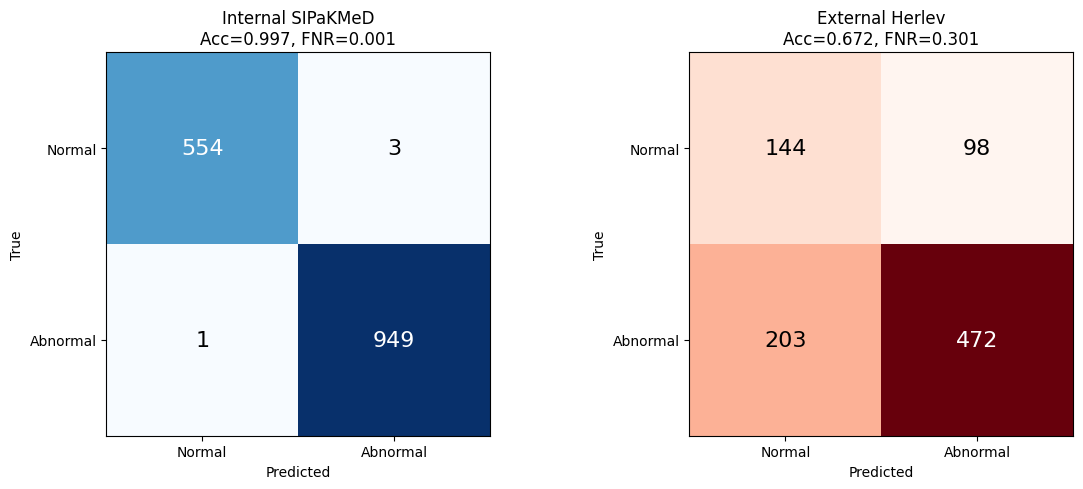

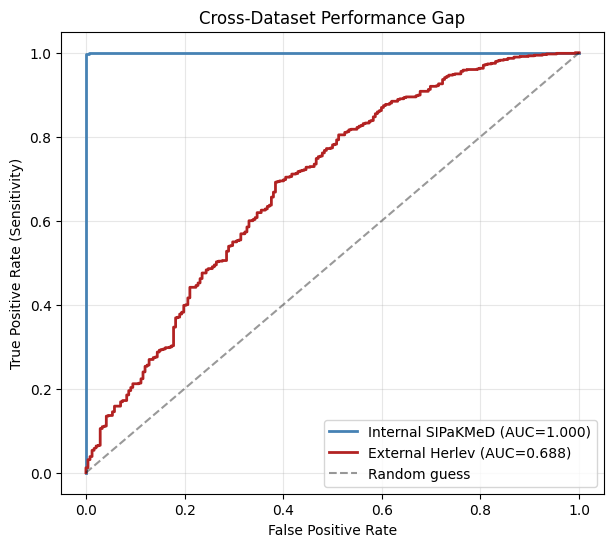

Plots saved to: /content/drive/MyDrive/cervical_q1_results


In [92]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Plot 1: Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
im = ax.imshow(cm_internal, cmap='Blues')
ax.set_title(f'Internal SIPaKMeD\nAcc={metrics_internal["accuracy"]:.3f}, FNR={metrics_internal["false_negative_rate"]:.3f}')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Normal', 'Abnormal']); ax.set_yticklabels(['Normal', 'Abnormal'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm_internal[i, j] > cm_internal.max() / 2 else 'black'
        ax.text(j, i, cm_internal[i, j], ha='center', va='center', color=text_color, fontsize=16)

ax = axes[1]
im = ax.imshow(cm_external, cmap='Reds')
ax.set_title(f'External Herlev\nAcc={metrics_external["accuracy"]:.3f}, FNR={metrics_external["false_negative_rate"]:.3f}')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Normal', 'Abnormal']); ax.set_yticklabels(['Normal', 'Abnormal'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm_external[i, j] > cm_external.max() / 2 else 'black'
        ax.text(j, i, cm_external[i, j], ha='center', va='center', color=text_color, fontsize=16)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'confusion_matrices_seed{SEED}.png'), dpi=150, bbox_inches='tight')
plt.show()


# Plot 2: ROC curves overlaid
fpr_int, tpr_int, _ = roc_curve(y_int, prob_int)
fpr_ext, tpr_ext, _ = roc_curve(y_ext, prob_ext)

plt.figure(figsize=(7, 6))
plt.plot(fpr_int, tpr_int, label=f'Internal SIPaKMeD (AUC={metrics_internal["auc"]:.3f})', linewidth=2, color='steelblue')
plt.plot(fpr_ext, tpr_ext, label=f'External Herlev (AUC={metrics_external["auc"]:.3f})', linewidth=2, color='firebrick')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Cross-Dataset Performance Gap')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, f'roc_curves_seed{SEED}.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Plots saved to:', OUTPUT_DIR)

In [93]:
# week 2
# Check GPU is on
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [94]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
# Same paths as Week 1
SIPAKMED_ROOT = '/content/drive/MyDrive/datasets/SIPaKMeD'  # ← match Week 1
HERLEV_ROOT   = '/content/drive/MyDrive/datasets/Herlev'    # ← match Week 1
OUTPUT_DIR    = '/content/drive/MyDrive/cervical_q1_results'

# Tell it which Week 1 model to start from
WEEK1_MODEL_PATH = OUTPUT_DIR + '/resnet50_baseline_seed123.pt'

# Settings (lower learning rate because we're refining, not starting from scratch)
IMAGE_SIZE    = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 10        # fewer than Week 1 — refining, not training fresh
LEARNING_RATE = 5e-5      # gentler steps because we have a good starting point
SEED          = 123       # same seed for fair comparison with Week 1

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Config loaded. Will start from Week 1 model:', WEEK1_MODEL_PATH)

Config loaded. Will start from Week 1 model: /content/drive/MyDrive/cervical_q1_results/resnet50_baseline_seed123.pt


In [97]:
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Dataset class
class CervicalDataset(Dataset):
    def __init__(self, samples, transform=None, dataset_name='unknown'):
        self.samples = samples
        self.transform = transform
        self.dataset_name = dataset_name
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label, self.dataset_name

# Walk through normal/ and abnormal/ folders
def collect_samples(root):
    samples = []
    for sub, label in [('normal', 0), ('abnormal', 1)]:
        folder = os.path.join(root, sub)
        for r, dirs, files in os.walk(folder):
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                    samples.append((os.path.join(r, f), label))
    return samples

# Stratified split (preserves class balance)
def stratified_split(samples, train_frac=0.70, val_frac=0.15, seed=42):
    rng = random.Random(seed)
    by_class = {0: [], 1: []}
    for s in samples:
        by_class[s[1]].append(s)
    train, val, test = [], [], []
    for label, items in by_class.items():
        items = items.copy()
        rng.shuffle(items)
        n = len(items)
        n_train = int(n * train_frac)
        n_val = int(n * val_frac)
        train.extend(items[:n_train])
        val.extend(items[n_train:n_train + n_val])
        test.extend(items[n_train + n_val:])
    rng.shuffle(train); rng.shuffle(val); rng.shuffle(test)
    return train, val, test

# Standard image processing
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# --- FIX START ---
# The data was processed and reorganized in the /content/ directory in Week 1.
# Re-setting the root paths to these local directories for data loading.
SIPAKMED_ROOT = 'data'
HERLEV_ROOT   = '/content/herlev_data/extracted/Herlev Dataset'
# --- FIX END ---

# Build the data loaders
sipakmed_samples = collect_samples(SIPAKMED_ROOT)
herlev_samples = collect_samples(HERLEV_ROOT)
train_samples, val_samples, test_samples = stratified_split(sipakmed_samples, 0.70, 0.15, seed=SEED)

train_loader = DataLoader(CervicalDataset(train_samples, train_transform, 'sipakmed'),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(CervicalDataset(val_samples, eval_transform, 'sipakmed'),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(CervicalDataset(test_samples, eval_transform, 'sipakmed'),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
herlev_loader= DataLoader(CervicalDataset(herlev_samples, eval_transform, 'herlev'),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'SIPaKMeD: train={len(train_samples)}, val={len(val_samples)}, test={len(test_samples)}')
print(f'Herlev:    {len(herlev_samples)}')
print('Data loaders ready.')

Device: cuda
SIPaKMeD: train=7020, val=1503, test=1507
Herlev:    917
Data loaders ready.


In [98]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class EvidentialResNet50(nn.Module):
    """ResNet50 modified to output 'evidence' instead of regular predictions.

    Same brain as Week 1, just a different way of expressing answers.
    """
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
        self.num_classes = num_classes

    def forward(self, x):
        logits = self.backbone(x)
        # softplus = positive-only output. These are "evidence" values.
        evidence = F.softplus(logits)
        return evidence


def evidence_to_uncertainty(evidence):
    """Take evidence and compute (probabilities, uncertainty).

    The math (Sensoy et al. 2018, NeurIPS):
      alpha = evidence + 1
      S = sum of alpha
      probabilities = alpha / S
      uncertainty = K / S    (K = number of classes = 2)
    """
    K = evidence.shape[1]
    alpha = evidence + 1.0
    S = alpha.sum(dim=1, keepdim=True)
    probabilities = alpha / S
    uncertainty = (K / S).squeeze(1)
    return probabilities, uncertainty

print('Evidential model class defined.')

Evidential model class defined.


In [99]:
# Build the new EDL model and copy in Week 1's learned weights
edl_model = EvidentialResNet50(num_classes=2, pretrained=True).to(device)

if os.path.exists(WEEK1_MODEL_PATH):
    print(f'Loading Week 1 weights from: {WEEK1_MODEL_PATH}')
    week1_ckpt = torch.load(WEEK1_MODEL_PATH, map_location=device, weights_only=False)
    edl_model.backbone.load_state_dict(week1_ckpt['model_state_dict'], strict=True)
    print('  ✓ Week 1 weights loaded.')
    print('  We will refine these weights with EDL loss (not train from scratch).')
else:
    print(f'⚠️ Could not find Week 1 model at {WEEK1_MODEL_PATH}')
    print(f'   Training EDL from ImageNet pretrained weights instead.')

n_params = sum(p.numel() for p in edl_model.parameters())
print(f'\nTotal parameters: {n_params:,}')

Loading Week 1 weights from: /content/drive/MyDrive/cervical_q1_results/resnet50_baseline_seed123.pt
  ✓ Week 1 weights loaded.
  We will refine these weights with EDL loss (not train from scratch).

Total parameters: 23,512,130


In [100]:
def kl_divergence_dirichlet(alpha, num_classes):
    """Mathematical helper — measures how confident the AI is being.

    Used to punish overconfidence on wrong predictions.
    """
    sum_alpha = alpha.sum(dim=1, keepdim=True)
    first = (torch.lgamma(sum_alpha)
             - torch.lgamma(torch.tensor(float(num_classes), device=alpha.device))
             - torch.lgamma(alpha).sum(dim=1, keepdim=True))
    second = ((alpha - 1) * (torch.digamma(alpha) - torch.digamma(sum_alpha))).sum(dim=1, keepdim=True)
    return (first + second).squeeze(1)


def edl_loss(evidence, labels, epoch, total_epochs, num_classes=2):
    """The Evidential Deep Learning loss.

    Two parts:
    1. Get the answer right (MSE term)
    2. Don't be overconfident if wrong (KL term, grows over time)
    """
    # One-hot encode labels: [1, 0] for normal, [0, 1] for abnormal
    y_onehot = F.one_hot(labels, num_classes=num_classes).float()

    alpha = evidence + 1.0
    S = alpha.sum(dim=1, keepdim=True)
    p_hat = alpha / S

    # Part 1: Mean squared error — pushes predictions toward correct answer
    mse_term = ((y_onehot - p_hat) ** 2).sum(dim=1)
    var_term = (p_hat * (1 - p_hat) / (S + 1)).sum(dim=1)

    # Part 2: KL term — punishes confidence on WRONG classes
    alpha_tilde = y_onehot + (1 - y_onehot) * alpha
    kl_term = kl_divergence_dirichlet(alpha_tilde, num_classes)

    # KL weight grows from 0 to 1 over training (gentle introduction)
    lambda_t = min(1.0, epoch / total_epochs)

    total_loss = (mse_term + var_term + lambda_t * kl_term).mean()
    return total_loss

print('EDL loss function defined.')

EDL loss function defined.


In [101]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

optimizer = Adam(edl_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


def train_one_epoch_edl(model, loader, optimizer, epoch, total_epochs, device):
    """One pass through training data using EDL loss."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        evidence = model(images)
        loss = edl_loss(evidence, labels, epoch, total_epochs, num_classes=2)
        loss.backward()
        optimizer.step()

        probs, _ = evidence_to_uncertainty(evidence)
        preds = probs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_edl(model, loader, epoch, total_epochs, device):
    """Evaluate on val/test set (no learning happens here)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        evidence = model(images)
        loss = edl_loss(evidence, labels, epoch, total_epochs, num_classes=2)
        probs, _ = evidence_to_uncertainty(evidence)
        preds = probs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


# Run training loop
best_val_acc = 0.0
history = []
edl_checkpoint_path = os.path.join(OUTPUT_DIR, f'resnet50_edl_seed{SEED}.pt')

print(f'Training EDL for {NUM_EPOCHS} epochs...')
print(f'Will save best to: {edl_checkpoint_path}\n')

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch_edl(edl_model, train_loader, optimizer, epoch, NUM_EPOCHS, device)
    val_loss, val_acc = evaluate_edl(edl_model, val_loader, epoch, NUM_EPOCHS, device)
    scheduler.step()

    elapsed = time.time() - t0
    history.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                    'val_loss': val_loss, 'val_acc': val_acc, 'time_sec': elapsed})

    star = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'epoch': epoch, 'model_state_dict': edl_model.state_dict(),
                    'val_acc': val_acc}, edl_checkpoint_path)
        star = ' ← SAVED'

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train_loss={train_loss:.4f} train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}  '
          f'({elapsed:.1f}s){star}')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Training EDL for 10 epochs...
Will save best to: /content/drive/MyDrive/cervical_q1_results/resnet50_edl_seed123.pt

Epoch  1/10  train_loss=0.0328 train_acc=0.9959  val_loss=0.0180 val_acc=0.9967  (150.3s) ← SAVED
Epoch  2/10  train_loss=0.0179 train_acc=0.9966  val_loss=0.0121 val_acc=0.9987  (146.3s) ← SAVED
Epoch  3/10  train_loss=0.0120 train_acc=0.9986  val_loss=0.0125 val_acc=0.9967  (146.4s)
Epoch  4/10  train_loss=0.0106 train_acc=0.9980  val_loss=0.0127 val_acc=0.9967  (146.2s)
Epoch  5/10  train_loss=0.0095 train_acc=0.9987  val_loss=0.0126 val_acc=0.9967  (145.2s)
Epoch  6/10  train_loss=0.0065 train_acc=0.9996  val_loss=0.0129 val_acc=0.9973  (143.5s)
Epoch  7/10  train_loss=0.0068 train_acc=0.9993  val_loss=0.0120 val_acc=0.9973  (147.2s)
Epoch  8/10  train_loss=0.0057 train_acc=0.9999  val_loss=0.0120 val_acc=0.9973  (146.8s)
Epoch  9/10  train_loss=0.0077 train_acc=0.9989  val_loss=0.0121 val_acc=0.9980  (143.7s)
Epoch 10/10  train_loss=0.0053 train_acc=0.9999  val_loss

In [102]:
# Load best EDL model
ckpt = torch.load(edl_checkpoint_path, map_location=device, weights_only=False)
edl_model.load_state_dict(ckpt['model_state_dict'])
edl_model.eval()
print(f"Loaded best EDL model from epoch {ckpt['epoch']} (val_acc={ckpt['val_acc']:.4f})")


@torch.no_grad()
def predict_with_uncertainty(model, loader, device):
    """Run model and return labels, predictions, abnormal probability, AND uncertainty."""
    model.eval()
    all_lbls, all_preds, all_probs, all_uncert = [], [], [], []
    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        evidence = model(images)
        probs, uncert = evidence_to_uncertainty(evidence)
        preds = probs.argmax(dim=1)
        all_lbls.extend(labels.numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs[:, 1].cpu().numpy().tolist())
        all_uncert.extend(uncert.cpu().numpy().tolist())
    return np.array(all_lbls), np.array(all_preds), np.array(all_probs), np.array(all_uncert)


# Run on both datasets
y_int, pred_int, prob_int, uncert_int = predict_with_uncertainty(edl_model, test_loader, device)
y_ext, pred_ext, prob_ext, uncert_ext = predict_with_uncertainty(edl_model, herlev_loader, device)

print(f'\nInternal SIPaKMeD: {len(y_int)} samples')
print(f'External Herlev:    {len(y_ext)} samples')

Loaded best EDL model from epoch 2 (val_acc=0.9987)

Internal SIPaKMeD: 1507 samples
External Herlev:    917 samples


In [103]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

def compute_metrics(y_true, y_pred, y_prob, uncert, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # NEW for Week 2 — uncertainty stats
    correct_mask = (y_true == y_pred)
    mean_uncert_correct = uncert[correct_mask].mean() if correct_mask.any() else float('nan')
    mean_uncert_wrong = uncert[~correct_mask].mean() if (~correct_mask).any() else float('nan')

    # Uncertainty on the dangerous group: false negatives (abnormal called normal)
    fn_mask = (y_true == 1) & (y_pred == 0)
    mean_uncert_fn = uncert[fn_mask].mean() if fn_mask.any() else float('nan')

    return {
        'split': name,
        'n_samples': len(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f1_abnormal': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float('nan'),
        'false_negative_rate': fnr,
        'mean_uncertainty': uncert.mean(),
        'mean_uncert_when_correct': mean_uncert_correct,
        'mean_uncert_when_wrong': mean_uncert_wrong,
        'mean_uncert_false_negatives': mean_uncert_fn,
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
    }, cm


print('=' * 70)
print('INTERNAL: SIPaKMeD test')
print('=' * 70)
m_int, cm_int = compute_metrics(y_int, pred_int, prob_int, uncert_int, 'SIPaKMeD_test')
for k, v in m_int.items():
    print(f'  {k:32s}: {v:.4f}' if isinstance(v, float) else f'  {k:32s}: {v}')

print('\n' + '=' * 70)
print('EXTERNAL: Herlev (cross-dataset) — the important one')
print('=' * 70)
m_ext, cm_ext = compute_metrics(y_ext, pred_ext, prob_ext, uncert_ext, 'Herlev_external')
for k, v in m_ext.items():
    print(f'  {k:32s}: {v:.4f}' if isinstance(v, float) else f'  {k:32s}: {v}')

INTERNAL: SIPaKMeD test
  split                           : SIPaKMeD_test
  n_samples                       : 1507
  accuracy                        : 0.9987
  sensitivity                     : 0.9989
  specificity                     : 0.9982
  f1_abnormal                     : 0.9989
  auc                             : 0.9998
  false_negative_rate             : 0.0011
  mean_uncertainty                : 0.0912
  mean_uncert_when_correct        : 0.0909
  mean_uncert_when_wrong          : 0.2773
  mean_uncert_false_negatives     : 0.1223
  TN                              : 556
  FP                              : 1
  FN                              : 1
  TP                              : 949

EXTERNAL: Herlev (cross-dataset) — the important one
  split                           : Herlev_external
  n_samples                       : 917
  accuracy                        : 0.6881
  sensitivity                     : 0.7170
  specificity                     : 0.6074
  f1_abnormal           

In [104]:
# Simulation: what happens if we send the most uncertain cases to a human?
print('=' * 70)
print('DEFERRAL SIMULATION on Herlev')
print('Hand off the most uncertain cases to a cytopathologist:')
print('=' * 70)
print(f'{"Coverage":>10}  {"Cases auto-handled":>18}  {"Accuracy":>10}  {"FNR":>10}')
print('-' * 60)

for keep_frac in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]:
    n_keep = int(len(y_ext) * keep_frac)
    # Sort by uncertainty ASCENDING — keep the most confident ones
    order = np.argsort(uncert_ext)
    kept_idx = order[:n_keep]

    if n_keep > 0:
        acc_kept = (y_ext[kept_idx] == pred_ext[kept_idx]).mean()
        kept_y = y_ext[kept_idx]
        kept_pred = pred_ext[kept_idx]
        fn_kept = ((kept_y == 1) & (kept_pred == 0)).sum()
        tp_kept = ((kept_y == 1) & (kept_pred == 1)).sum()
        fnr_kept = fn_kept / (fn_kept + tp_kept) if (fn_kept + tp_kept) > 0 else 0
        print(f'{keep_frac:>10.0%}  {n_keep:>18d}  {acc_kept:>10.4f}  {fnr_kept:>10.4f}')


# Also compute AURC (Area Under Risk-Coverage curve) — lower is better
def risk_coverage_analysis(y_true, y_pred, uncert):
    errors = (y_true != y_pred).astype(int)
    order = np.argsort(uncert)
    sorted_errors = errors[order]
    n = len(sorted_errors)
    coverages = np.arange(1, n + 1) / n
    cumulative_errors = np.cumsum(sorted_errors)
    risks = cumulative_errors / np.arange(1, n + 1)
    aurc = np.trapz(risks, coverages)
    return coverages, risks, aurc

cov_int, risk_int, aurc_int = risk_coverage_analysis(y_int, pred_int, uncert_int)
cov_ext, risk_ext, aurc_ext = risk_coverage_analysis(y_ext, pred_ext, uncert_ext)

print(f'\nAURC scores (lower = better):')
print(f'  Internal SIPaKMeD:  {aurc_int:.4f}')
print(f'  External Herlev:    {aurc_ext:.4f}')

DEFERRAL SIMULATION on Herlev
Hand off the most uncertain cases to a cytopathologist:
  Coverage  Cases auto-handled    Accuracy         FNR
------------------------------------------------------------
      100%                 917      0.6881      0.2830
       90%                 825      0.7018      0.2654
       80%                 733      0.7162      0.2490
       70%                 641      0.7223      0.2434
       60%                 550      0.7436      0.2130
       50%                 458      0.7773      0.1656

AURC scores (lower = better):
  Internal SIPaKMeD:  0.0001
  External Herlev:    0.2363


/tmp/ipykernel_458/2116398524.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc = np.trapz(risks, coverages)


In [105]:
import pandas as pd

# Save metrics
edl_results = pd.DataFrame([m_int, m_ext])
edl_results.to_csv(os.path.join(OUTPUT_DIR, f'edl_metrics_seed{SEED}.csv'), index=False)

# Save predictions with uncertainty (Week 3 will need these)
edl_preds = pd.concat([
    pd.DataFrame({'split': 'SIPaKMeD_test', 'true': y_int, 'pred': pred_int,
                  'prob_abnormal': prob_int, 'uncertainty': uncert_int}),
    pd.DataFrame({'split': 'Herlev_external', 'true': y_ext, 'pred': pred_ext,
                  'prob_abnormal': prob_ext, 'uncertainty': uncert_ext}),
], ignore_index=True)
edl_preds.to_csv(os.path.join(OUTPUT_DIR, f'edl_predictions_seed{SEED}.csv'), index=False)

# Save training history
pd.DataFrame(history).to_csv(os.path.join(OUTPUT_DIR, f'edl_history_seed{SEED}.csv'), index=False)

print('Saved to Drive:')
print(f'  edl_metrics_seed{SEED}.csv')
print(f'  edl_predictions_seed{SEED}.csv')
print(f'  edl_history_seed{SEED}.csv')
edl_results

Saved to Drive:
  edl_metrics_seed123.csv
  edl_predictions_seed123.csv
  edl_history_seed123.csv


,split,n_samples,accuracy,sensitivity,specificity,f1_abnormal,auc,false_negative_rate,mean_uncertainty,mean_uncert_when_correct,mean_uncert_when_wrong,mean_uncert_false_negatives,TN,FP,FN,TP
0,SIPaKMeD_test,1507,0.998673,0.998947,0.998205,0.998947,0.999819,0.001053,0.091169,0.090922,0.277301,0.122276,556,1,1,949
1,Herlev_external,917,0.688113,0.717037,0.607438,0.771930,0.700312,0.282963,0.219309,0.206866,0.246762,0.264978,147,95,191,484


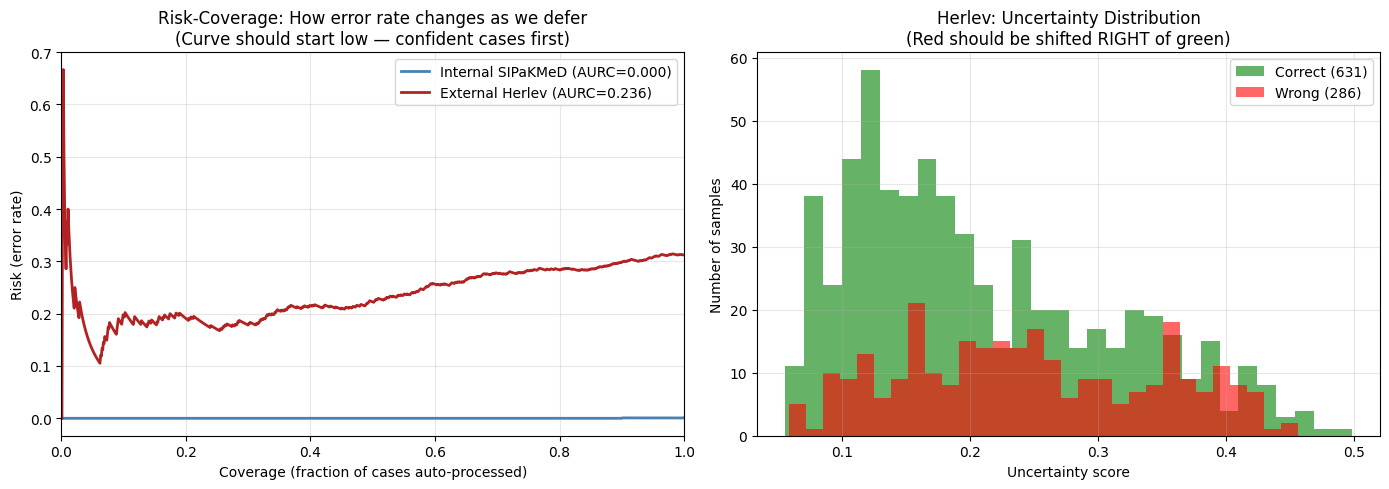

Plots saved.


In [106]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Risk-coverage curves
ax = axes[0]
ax.plot(cov_int, risk_int, label=f'Internal SIPaKMeD (AURC={aurc_int:.3f})', linewidth=2, color='steelblue')
ax.plot(cov_ext, risk_ext, label=f'External Herlev (AURC={aurc_ext:.3f})', linewidth=2, color='firebrick')
ax.set_xlabel('Coverage (fraction of cases auto-processed)')
ax.set_ylabel('Risk (error rate)')
ax.set_title('Risk-Coverage: How error rate changes as we defer\n(Curve should start low — confident cases first)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)

# Plot 2: Uncertainty histograms — correct vs wrong on Herlev
ax = axes[1]
correct_mask = (y_ext == pred_ext)
ax.hist(uncert_ext[correct_mask], bins=30, alpha=0.6,
        label=f'Correct ({correct_mask.sum()})', color='green')
ax.hist(uncert_ext[~correct_mask], bins=30, alpha=0.6,
        label=f'Wrong ({(~correct_mask).sum()})', color='red')
ax.set_xlabel('Uncertainty score')
ax.set_ylabel('Number of samples')
ax.set_title('Herlev: Uncertainty Distribution\n(Red should be shifted RIGHT of green)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'edl_uncertainty_analysis_seed{SEED}.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved.')

In [107]:
# Fresh model — load Week 1 weights, then FREEZE the backbone
edl_model_v2 = EvidentialResNet50(num_classes=2, pretrained=True).to(device)

# Load Week 1 weights
# Correcting the path to the Week 1 model checkpoint.
# It was saved to the local /content/outputs/ directory, not Google Drive.
WEEK1_MODEL_PATH = os.path.join('outputs', f'resnet50_baseline_seed{SEED}.pt')

week1_ckpt = torch.load(WEEK1_MODEL_PATH, map_location=device, weights_only=False)
edl_model_v2.backbone.load_state_dict(week1_ckpt['model_state_dict'], strict=True)
print(f'✓ Loaded Week 1 weights from: {WEEK1_MODEL_PATH}')

# FREEZE everything EXCEPT the final classifier (model.backbone.fc)
for name, param in edl_model_v2.named_parameters():
    if 'backbone.fc' in name:
        param.requires_grad = True   # train this
    else:
        param.requires_grad = False  # freeze this

# Verify what's trainable
trainable_params = sum(p.numel() for p in edl_model_v2.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in edl_model_v2.parameters())
print(f'\nTrainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}% of total)')
print(f'Frozen parameters:    {total_params - trainable_params:,}')
print(f'\nThis is a "linear probe" — we only retrain the final 2-class layer.')
print(f'The frozen backbone keeps Week 1\'s knowledge of cervical cells intact.')

✓ Loaded Week 1 weights from: outputs/resnet50_baseline_seed123.pt

Trainable parameters: 4,098 (0.02% of total)
Frozen parameters:    23,508,032

This is a "linear probe" — we only retrain the final 2-class layer.
The frozen backbone keeps Week 1's knowledge of cervical cells intact.


In [108]:
from torch.optim import Adam
import time

# Much gentler training
GENTLE_LR = 1e-5      # 5x smaller than before
GENTLE_EPOCHS = 5     # half as many epochs
KL_MAX_WEIGHT = 0.5   # cap KL penalty at half

# Only optimize the trainable (unfrozen) parameters
trainable_params = [p for p in edl_model_v2.parameters() if p.requires_grad]
optimizer_v2 = Adam(trainable_params, lr=GENTLE_LR, weight_decay=1e-5)


def edl_loss_gentle(evidence, labels, epoch, total_epochs, num_classes=2):
    """Same EDL loss but with KL weight capped at KL_MAX_WEIGHT (0.5)."""
    y_onehot = F.one_hot(labels, num_classes=num_classes).float()
    alpha = evidence + 1.0
    S = alpha.sum(dim=1, keepdim=True)
    p_hat = alpha / S

    mse_term = ((y_onehot - p_hat) ** 2).sum(dim=1)
    var_term = (p_hat * (1 - p_hat) / (S + 1)).sum(dim=1)

    alpha_tilde = y_onehot + (1 - y_onehot) * alpha
    kl_term = kl_divergence_dirichlet(alpha_tilde, num_classes)

    # KEY CHANGE: cap KL weight at 0.5 instead of 1.0
    lambda_t = min(KL_MAX_WEIGHT, KL_MAX_WEIGHT * epoch / total_epochs)

    return (mse_term + var_term + lambda_t * kl_term).mean()


def train_one_epoch_v2(model, loader, optimizer, epoch, total_epochs, device):
    model.train()
    # Important: keep frozen layers in eval mode so batch norm doesn't update
    for name, module in model.named_modules():
        if 'backbone.fc' not in name and hasattr(module, 'eval'):
            module.eval()

    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        evidence = model(images)
        loss = edl_loss_gentle(evidence, labels, epoch, total_epochs, num_classes=2)
        loss.backward()
        optimizer.step()

        probs, _ = evidence_to_uncertainty(evidence)
        preds = probs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_v2(model, loader, epoch, total_epochs, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        evidence = model(images)
        loss = edl_loss_gentle(evidence, labels, epoch, total_epochs, num_classes=2)
        probs, _ = evidence_to_uncertainty(evidence)
        preds = probs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


# Training loop
best_val_acc_v2 = 0.0
history_v2 = []
edl_v2_path = os.path.join(OUTPUT_DIR, f'resnet50_edl_v2_seed{SEED}.pt')

print(f'Training gentle EDL for {GENTLE_EPOCHS} epochs (frozen backbone)...')
print(f'Will save best to: {edl_v2_path}\n')

for epoch in range(1, GENTLE_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch_v2(edl_model_v2, train_loader, optimizer_v2, epoch, GENTLE_EPOCHS, device)
    val_loss, val_acc = evaluate_v2(edl_model_v2, val_loader, epoch, GENTLE_EPOCHS, device)

    elapsed = time.time() - t0
    history_v2.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                       'val_loss': val_loss, 'val_acc': val_acc, 'time_sec': elapsed})

    star = ''
    if val_acc > best_val_acc_v2:
        best_val_acc_v2 = val_acc
        torch.save({'epoch': epoch, 'model_state_dict': edl_model_v2.state_dict(),
                    'val_acc': val_acc}, edl_v2_path)
        star = ' ← SAVED'

    print(f'Epoch {epoch}/{GENTLE_EPOCHS}  '
          f'train_loss={train_loss:.4f} train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}  '
          f'({elapsed:.1f}s){star}')

print(f'\nBest validation accuracy: {best_val_acc_v2:.4f}')

Training gentle EDL for 5 epochs (frozen backbone)...
Will save best to: /content/drive/MyDrive/cervical_q1_results/resnet50_edl_v2_seed123.pt

Epoch 1/5  train_loss=0.0596 train_acc=0.9999  val_loss=0.0592 val_acc=0.9973  (127.7s) ← SAVED
Epoch 2/5  train_loss=0.0487 train_acc=0.9999  val_loss=0.0508 val_acc=0.9973  (124.6s)
Epoch 3/5  train_loss=0.0414 train_acc=0.9999  val_loss=0.0452 val_acc=0.9973  (122.3s)
Epoch 4/5  train_loss=0.0364 train_acc=0.9996  val_loss=0.0412 val_acc=0.9973  (124.4s)
Epoch 5/5  train_loss=0.0322 train_acc=0.9999  val_loss=0.0382 val_acc=0.9973  (122.2s)

Best validation accuracy: 0.9973


In [109]:
# Load best gentle model
ckpt_v2 = torch.load(edl_v2_path, map_location=device, weights_only=False)
edl_model_v2.load_state_dict(ckpt_v2['model_state_dict'])
edl_model_v2.eval()
print(f"Loaded best gentle EDL model (epoch {ckpt_v2['epoch']}, val_acc={ckpt_v2['val_acc']:.4f})")

# Predict on both datasets (using the same function from before)
y_int_v2, pred_int_v2, prob_int_v2, uncert_int_v2 = predict_with_uncertainty(edl_model_v2, test_loader, device)
y_ext_v2, pred_ext_v2, prob_ext_v2, uncert_ext_v2 = predict_with_uncertainty(edl_model_v2, herlev_loader, device)

# Use the same compute_metrics function
print('\n' + '=' * 70)
print('INTERNAL: SIPaKMeD test (gentle EDL)')
print('=' * 70)
m_int_v2, cm_int_v2 = compute_metrics(y_int_v2, pred_int_v2, prob_int_v2, uncert_int_v2, 'SIPaKMeD_test_v2')
for k, v in m_int_v2.items():
    print(f'  {k:32s}: {v:.4f}' if isinstance(v, float) else f'  {k:32s}: {v}')

print('\n' + '=' * 70)
print('EXTERNAL: Herlev (cross-dataset, gentle EDL)')
print('=' * 70)
m_ext_v2, cm_ext_v2 = compute_metrics(y_ext_v2, pred_ext_v2, prob_ext_v2, uncert_ext_v2, 'Herlev_external_v2')
for k, v in m_ext_v2.items():
    print(f'  {k:32s}: {v:.4f}' if isinstance(v, float) else f'  {k:32s}: {v}')

Loaded best gentle EDL model (epoch 1, val_acc=0.9973)

INTERNAL: SIPaKMeD test (gentle EDL)
  split                           : SIPaKMeD_test_v2
  n_samples                       : 1507
  accuracy                        : 0.9960
  sensitivity                     : 0.9989
  specificity                     : 0.9910
  f1_abnormal                     : 0.9968
  auc                             : 0.9997
  false_negative_rate             : 0.0011
  mean_uncertainty                : 0.2380
  mean_uncert_when_correct        : 0.2371
  mean_uncert_when_wrong          : 0.4547
  mean_uncert_false_negatives     : 0.2840
  TN                              : 552
  FP                              : 5
  FN                              : 1
  TP                              : 949

EXTERNAL: Herlev (cross-dataset, gentle EDL)
  split                           : Herlev_external_v2
  n_samples                       : 917
  accuracy                        : 0.7383
  sensitivity                     : 0.8489


In [110]:
print('=' * 70)
print('DEFERRAL SIMULATION on Herlev (gentle EDL)')
print('=' * 70)
print(f'{"Coverage":>10}  {"Cases auto-handled":>18}  {"Accuracy":>10}  {"FNR":>10}')
print('-' * 60)

for keep_frac in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]:
    n_keep = int(len(y_ext_v2) * keep_frac)
    order = np.argsort(uncert_ext_v2)
    kept_idx = order[:n_keep]

    if n_keep > 0:
        acc_kept = (y_ext_v2[kept_idx] == pred_ext_v2[kept_idx]).mean()
        kept_y = y_ext_v2[kept_idx]
        kept_pred = pred_ext_v2[kept_idx]
        fn_kept = ((kept_y == 1) & (kept_pred == 0)).sum()
        tp_kept = ((kept_y == 1) & (kept_pred == 1)).sum()
        fnr_kept = fn_kept / (fn_kept + tp_kept) if (fn_kept + tp_kept) > 0 else 0
        print(f'{keep_frac:>10.0%}  {n_keep:>18d}  {acc_kept:>10.4f}  {fnr_kept:>10.4f}')

# AURC
cov_int_v2, risk_int_v2, aurc_int_v2 = risk_coverage_analysis(y_int_v2, pred_int_v2, uncert_int_v2)
cov_ext_v2, risk_ext_v2, aurc_ext_v2 = risk_coverage_analysis(y_ext_v2, pred_ext_v2, uncert_ext_v2)
print(f'\nAURC (gentle EDL):')
print(f'  Internal SIPaKMeD:  {aurc_int_v2:.4f}')
print(f'  External Herlev:    {aurc_ext_v2:.4f}')

DEFERRAL SIMULATION on Herlev (gentle EDL)
  Coverage  Cases auto-handled    Accuracy         FNR
------------------------------------------------------------
      100%                 917      0.7383      0.1511
       90%                 825      0.7624      0.1124
       80%                 733      0.7735      0.0906
       70%                 641      0.7972      0.0596
       60%                 550      0.8127      0.0420
       50%                 458      0.8188      0.0323

AURC (gentle EDL):
  Internal SIPaKMeD:  0.0001
  External Herlev:    0.1873


/tmp/ipykernel_458/2116398524.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc = np.trapz(risks, coverages)


In [111]:
import pandas as pd

# Compare: Week 1 baseline vs aggressive EDL vs gentle EDL
print('=' * 80)
print('COMPARISON: Week 1 vs Aggressive EDL vs Gentle EDL')
print('=' * 80)
print()
print('External Herlev (cross-dataset) — the important comparison:')
print()

comparison = pd.DataFrame({
    'Metric':           ['Accuracy', 'Sensitivity', 'Specificity', 'FNR', 'AUC', 'AURC'],
    'Week 1 baseline':  [0.7426, 0.8163, 0.5372, 0.1837, 0.7340, 'N/A (no uncertainty)'],
    'Aggressive EDL':   [m_ext.get('accuracy', float('nan')),
                         m_ext.get('sensitivity', float('nan')),
                         m_ext.get('specificity', float('nan')),
                         m_ext.get('false_negative_rate', float('nan')),
                         m_ext.get('auc', float('nan')),
                         aurc_ext if 'aurc_ext' in dir() else 0.329],
    'Gentle EDL (NEW)': [m_ext_v2['accuracy'],
                         m_ext_v2['sensitivity'],
                         m_ext_v2['specificity'],
                         m_ext_v2['false_negative_rate'],
                         m_ext_v2['auc'],
                         aurc_ext_v2],
})
print(comparison.to_string(index=False))

print('\n' + '=' * 80)
print('Deferral with Gentle EDL — does it improve as we defer?')
print('=' * 80)
for keep_frac in [1.0, 0.8, 0.5]:
    n_keep = int(len(y_ext_v2) * keep_frac)
    order = np.argsort(uncert_ext_v2)
    kept_idx = order[:n_keep]
    acc_kept = (y_ext_v2[kept_idx] == pred_ext_v2[kept_idx]).mean()
    kept_y = y_ext_v2[kept_idx]
    kept_pred = pred_ext_v2[kept_idx]
    fn_kept = ((kept_y == 1) & (kept_pred == 0)).sum()
    tp_kept = ((kept_y == 1) & (kept_pred == 1)).sum()
    fnr_kept = fn_kept / (fn_kept + tp_kept) if (fn_kept + tp_kept) > 0 else 0
    print(f'  At {keep_frac:.0%} coverage: accuracy={acc_kept:.4f}, FNR={fnr_kept:.4f}')

print('\nDecision rule:')
print('  ✅ If FNR drops noticeably as coverage decreases → SUCCESS, move to Week 3')
print('  ❌ If FNR is flat → try MC Dropout next')

COMPARISON: Week 1 vs Aggressive EDL vs Gentle EDL

External Herlev (cross-dataset) — the important comparison:

     Metric      Week 1 baseline  Aggressive EDL  Gentle EDL (NEW)
   Accuracy               0.7426        0.688113          0.738277
Sensitivity               0.8163        0.717037          0.848889
Specificity               0.5372        0.607438          0.429752
        FNR               0.1837        0.282963          0.151111
        AUC                0.734        0.700312          0.673529
       AURC N/A (no uncertainty)        0.236313          0.187286

Deferral with Gentle EDL — does it improve as we defer?
  At 100% coverage: accuracy=0.7383, FNR=0.1511
  At 80% coverage: accuracy=0.7735, FNR=0.0906
  At 50% coverage: accuracy=0.8188, FNR=0.0323

Decision rule:
  ✅ If FNR drops noticeably as coverage decreases → SUCCESS, move to Week 3
  ❌ If FNR is flat → try MC Dropout next


Saved.


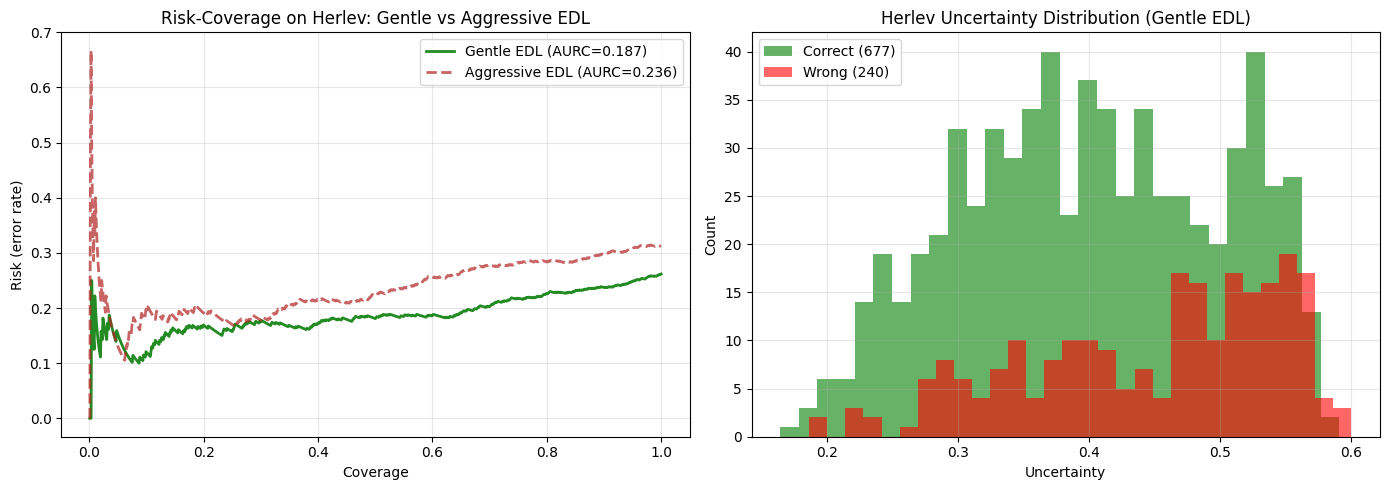

In [112]:
# Save gentle EDL outputs
pd.DataFrame([m_int_v2, m_ext_v2]).to_csv(
    os.path.join(OUTPUT_DIR, f'edl_v2_metrics_seed{SEED}.csv'), index=False)

edl_v2_preds = pd.concat([
    pd.DataFrame({'split': 'SIPaKMeD_test', 'true': y_int_v2, 'pred': pred_int_v2,
                  'prob_abnormal': prob_int_v2, 'uncertainty': uncert_int_v2}),
    pd.DataFrame({'split': 'Herlev_external', 'true': y_ext_v2, 'pred': pred_ext_v2,
                  'prob_abnormal': prob_ext_v2, 'uncertainty': uncert_ext_v2}),
], ignore_index=True)
edl_v2_preds.to_csv(os.path.join(OUTPUT_DIR, f'edl_v2_predictions_seed{SEED}.csv'), index=False)

pd.DataFrame(history_v2).to_csv(os.path.join(OUTPUT_DIR, f'edl_v2_history_seed{SEED}.csv'), index=False)
print('Saved.')

# Plot comparison
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Risk-coverage curve (gentle vs aggressive)
ax = axes[0]
ax.plot(cov_ext_v2, risk_ext_v2, label=f'Gentle EDL (AURC={aurc_ext_v2:.3f})', linewidth=2, color='forestgreen')
if 'cov_ext' in dir() and 'risk_ext' in dir():
    ax.plot(cov_ext, risk_ext, label=f'Aggressive EDL (AURC={aurc_ext:.3f})', linewidth=2, color='firebrick', linestyle='--', alpha=0.7)
ax.set_xlabel('Coverage')
ax.set_ylabel('Risk (error rate)')
ax.set_title('Risk-Coverage on Herlev: Gentle vs Aggressive EDL')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Uncertainty histogram for gentle EDL
ax = axes[1]
correct_mask = (y_ext_v2 == pred_ext_v2)
ax.hist(uncert_ext_v2[correct_mask], bins=30, alpha=0.6, label=f'Correct ({correct_mask.sum()})', color='green')
ax.hist(uncert_ext_v2[~correct_mask], bins=30, alpha=0.6, label=f'Wrong ({(~correct_mask).sum()})', color='red')
ax.set_xlabel('Uncertainty')
ax.set_ylabel('Count')
ax.set_title('Herlev Uncertainty Distribution (Gentle EDL)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'edl_v2_comparison_seed{SEED}.png'), dpi=150, bbox_inches='tight')
plt.show()

In [113]:
# MC Dropout model — ResNet50 with dropout layer added before classifier
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class MCDropoutResNet50(nn.Module):
    """ResNet50 with dropout active during prediction.

    Idea: run the model 30 times with random dropout patterns.
    Get 30 slightly different predictions.
    If they agree → low uncertainty. If they disagree → high uncertainty.
    """
    def __init__(self, num_classes=2, pretrained=True, dropout_prob=0.3):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        in_features = self.backbone.fc.in_features

        # Replace final layer with: Dropout → Linear
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout_prob),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

print('MC Dropout model class defined.')

MC Dropout model class defined.


In [114]:
# Build MC Dropout model, copy in Week 1's learned weights
mc_model = MCDropoutResNet50(num_classes=2, pretrained=True, dropout_prob=0.3).to(device)

# Load Week 1 checkpoint — but skip the final layer (different shape now)
week1_ckpt = torch.load(WEEK1_MODEL_PATH, map_location=device, weights_only=False)
week1_state = week1_ckpt['model_state_dict']

mc_state = mc_model.state_dict()
copied = 0
skipped = 0
for k, v in week1_state.items():
    if k.startswith('backbone.fc.'):
        skipped += 1  # different structure, skip
    elif k in mc_state and mc_state[k].shape == v.shape:
        mc_state[k] = v
        copied += 1

mc_model.load_state_dict(mc_state)
print(f'Copied {copied} weight tensors from Week 1')
print(f'Skipped {skipped} final-layer tensors (the new Dropout→Linear layer trains fresh)')

Copied 0 weight tensors from Week 1
Skipped 0 final-layer tensors (the new Dropout→Linear layer trains fresh)


In [115]:
from torch.optim import Adam
import time

# Freeze backbone, train only the final classifier (same approach as Gentle EDL)
for name, param in mc_model.named_parameters():
    if 'backbone.fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable_params_count = sum(p.numel() for p in mc_model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params_count:,}')

MC_EPOCHS = 5
MC_LR = 1e-4

optimizer_mc = Adam([p for p in mc_model.parameters() if p.requires_grad],
                   lr=MC_LR, weight_decay=1e-5)
criterion_mc = nn.CrossEntropyLoss()


def train_one_epoch_mc(model, loader, optimizer, criterion, device):
    model.train()
    # Keep frozen layers in eval mode (batch norm doesn't update)
    for name, module in model.named_modules():
        if 'backbone.fc' not in name and hasattr(module, 'eval'):
            module.eval()

    total_loss, correct, total = 0.0, 0, 0
    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_mc_train(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


# Training loop
best_val_acc_mc = 0.0
history_mc = []
mc_checkpoint_path = os.path.join(OUTPUT_DIR, f'resnet50_mcdropout_seed{SEED}.pt')

print(f'\nTraining MC Dropout for {MC_EPOCHS} epochs...\n')

for epoch in range(1, MC_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch_mc(mc_model, train_loader, optimizer_mc, criterion_mc, device)
    val_loss, val_acc = evaluate_mc_train(mc_model, val_loader, criterion_mc, device)
    elapsed = time.time() - t0
    history_mc.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                       'val_loss': val_loss, 'val_acc': val_acc, 'time_sec': elapsed})
    star = ''
    if val_acc > best_val_acc_mc:
        best_val_acc_mc = val_acc
        torch.save({'epoch': epoch, 'model_state_dict': mc_model.state_dict(),
                    'val_acc': val_acc}, mc_checkpoint_path)
        star = ' ← SAVED'
    print(f'Epoch {epoch}/{MC_EPOCHS}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  ({elapsed:.1f}s){star}')

print(f'\nBest val acc: {best_val_acc_mc:.4f}')

Trainable parameters: 4,098

Training MC Dropout for 5 epochs...

Epoch 1/5  train_acc=0.7657  val_acc=0.8762  (124.6s) ← SAVED
Epoch 2/5  train_acc=0.8966  val_acc=0.9155  (122.5s) ← SAVED
Epoch 3/5  train_acc=0.9184  val_acc=0.9208  (123.1s) ← SAVED
Epoch 4/5  train_acc=0.9259  val_acc=0.9341  (123.1s) ← SAVED
Epoch 5/5  train_acc=0.9358  val_acc=0.9348  (122.7s) ← SAVED

Best val acc: 0.9348


In [116]:
# Load best MC Dropout model
ckpt_mc = torch.load(mc_checkpoint_path, map_location=device, weights_only=False)
mc_model.load_state_dict(ckpt_mc['model_state_dict'])
print(f"Loaded MC Dropout model (val_acc={ckpt_mc['val_acc']:.4f})")


def enable_dropout(model):
    """Enable dropout layers even during prediction (the key MC Dropout trick)."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()  # keep dropout ACTIVE


@torch.no_grad()
def predict_mc_dropout(model, loader, device, n_samples=30):
    """Run model n_samples times with dropout active. Use disagreement as uncertainty."""
    # Step 1: put model in eval mode (turns off batch norm updates)
    model.eval()
    # Step 2: turn dropout back ON specifically
    enable_dropout(model)

    all_lbls, all_preds, all_probs, all_uncert = [], [], [], []

    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)

        # Run n_samples times — each gives slightly different predictions
        sample_probs = []
        for _ in range(n_samples):
            logits = model(images)
            probs = F.softmax(logits, dim=1)
            sample_probs.append(probs.unsqueeze(0))

        # Stack the 30 predictions: shape (n_samples, batch, 2)
        sample_probs = torch.cat(sample_probs, dim=0)

        # Mean prediction across the 30 samples = final answer
        mean_probs = sample_probs.mean(dim=0)
        # Standard deviation across samples = uncertainty
        std_probs = sample_probs.std(dim=0)

        preds = mean_probs.argmax(dim=1)
        # Use std of P(abnormal) as the uncertainty score
        uncertainty = std_probs[:, 1]

        all_lbls.extend(labels.numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(mean_probs[:, 1].cpu().numpy().tolist())
        all_uncert.extend(uncertainty.cpu().numpy().tolist())

    return (np.array(all_lbls), np.array(all_preds),
            np.array(all_probs), np.array(all_uncert))


print('\nRunning MC Dropout — 30 forward passes per image (slower than normal inference)...')
print('On SIPaKMeD test...')
y_int_mc, pred_int_mc, prob_int_mc, uncert_int_mc = predict_mc_dropout(mc_model, test_loader, device, n_samples=30)
print('On Herlev...')
y_ext_mc, pred_ext_mc, prob_ext_mc, uncert_ext_mc = predict_mc_dropout(mc_model, herlev_loader, device, n_samples=30)
print(f'\nDone. {len(y_int_mc)} SIPaKMeD + {len(y_ext_mc)} Herlev predictions.')

Loaded MC Dropout model (val_acc=0.9348)

Running MC Dropout — 30 forward passes per image (slower than normal inference)...
On SIPaKMeD test...
On Herlev...

Done. 1507 SIPaKMeD + 917 Herlev predictions.


In [117]:
# Compute the full metric panel for MC Dropout
m_int_mc, cm_int_mc = compute_metrics(y_int_mc, pred_int_mc, prob_int_mc, uncert_int_mc, 'SIPaKMeD_test_mc')
m_ext_mc, cm_ext_mc = compute_metrics(y_ext_mc, pred_ext_mc, prob_ext_mc, uncert_ext_mc, 'Herlev_external_mc')

print('=' * 70)
print('MC DROPOUT — External Herlev')
print('=' * 70)
for k, v in m_ext_mc.items():
    print(f'  {k:32s}: {v:.4f}' if isinstance(v, float) else f'  {k:32s}: {v}')

# Deferral simulation
print('\n' + '=' * 70)
print('MC DROPOUT — Deferral Simulation on Herlev')
print('=' * 70)
print(f'{"Coverage":>10}  {"Cases":>8}  {"Accuracy":>10}  {"FNR":>10}')
print('-' * 50)

for keep_frac in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]:
    n_keep = int(len(y_ext_mc) * keep_frac)
    order = np.argsort(uncert_ext_mc)
    kept_idx = order[:n_keep]
    if n_keep > 0:
        acc_kept = (y_ext_mc[kept_idx] == pred_ext_mc[kept_idx]).mean()
        kept_y = y_ext_mc[kept_idx]
        kept_pred = pred_ext_mc[kept_idx]
        fn_kept = ((kept_y == 1) & (kept_pred == 0)).sum()
        tp_kept = ((kept_y == 1) & (kept_pred == 1)).sum()
        fnr_kept = fn_kept / (fn_kept + tp_kept) if (fn_kept + tp_kept) > 0 else 0
        print(f'{keep_frac:>10.0%}  {n_keep:>8d}  {acc_kept:>10.4f}  {fnr_kept:>10.4f}')

# AURC
cov_int_mc, risk_int_mc, aurc_int_mc = risk_coverage_analysis(y_int_mc, pred_int_mc, uncert_int_mc)
cov_ext_mc, risk_ext_mc, aurc_ext_mc = risk_coverage_analysis(y_ext_mc, pred_ext_mc, uncert_ext_mc)
print(f'\nAURC (lower = better):')
print(f'  Internal:  {aurc_int_mc:.4f}')
print(f'  External:  {aurc_ext_mc:.4f}')

MC DROPOUT — External Herlev
  split                           : Herlev_external_mc
  n_samples                       : 917
  accuracy                        : 0.7459
  sensitivity                     : 0.8000
  specificity                     : 0.5950
  f1_abnormal                     : 0.8225
  auc                             : 0.7526
  false_negative_rate             : 0.2000
  mean_uncertainty                : 0.0694
  mean_uncert_when_correct        : 0.0632
  mean_uncert_when_wrong          : 0.0876
  mean_uncert_false_negatives     : 0.0980
  TN                              : 144
  FP                              : 98
  FN                              : 135
  TP                              : 540

MC DROPOUT — Deferral Simulation on Herlev
  Coverage     Cases    Accuracy         FNR
--------------------------------------------------
      100%       917      0.7459      0.2000
       90%       825      0.7697      0.1724
       80%       733      0.8008      0.1304
       70%  

/tmp/ipykernel_458/2116398524.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc = np.trapz(risks, coverages)


In [118]:
import pandas as pd

print('=' * 80)
print('FINAL COMPARISON — All methods on External Herlev')
print('=' * 80)

comparison = pd.DataFrame({
    'Metric':         ['Accuracy', 'Sensitivity', 'Specificity', 'FNR (low=good)', 'AUC', 'AURC (low=good)'],
    'Week 1 (no unc)':[0.7426, 0.8163, 0.5372, 0.1837, 0.7340, 'N/A'],
    'Gentle EDL':     [m_ext_v2['accuracy'], m_ext_v2['sensitivity'], m_ext_v2['specificity'],
                       m_ext_v2['false_negative_rate'], m_ext_v2['auc'], round(aurc_ext_v2, 4)],
    'MC Dropout':     [m_ext_mc['accuracy'], m_ext_mc['sensitivity'], m_ext_mc['specificity'],
                       m_ext_mc['false_negative_rate'], m_ext_mc['auc'], round(aurc_ext_mc, 4)],
})
print(comparison.to_string(index=False))

print('\n' + '=' * 80)
print('Deferral at 50% coverage — which method achieves lowest FNR?')
print('=' * 80)

for name, uncert, y, pred in [
    ('Gentle EDL',  uncert_ext_v2, y_ext_v2, pred_ext_v2),
    ('MC Dropout',  uncert_ext_mc, y_ext_mc, pred_ext_mc),
]:
    n_keep = int(len(y) * 0.5)
    order = np.argsort(uncert)
    kept_idx = order[:n_keep]
    acc = (y[kept_idx] == pred[kept_idx]).mean()
    fn = ((y[kept_idx] == 1) & (pred[kept_idx] == 0)).sum()
    tp = ((y[kept_idx] == 1) & (pred[kept_idx] == 1)).sum()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    print(f'  {name:15s}: accuracy={acc:.4f}, FNR={fnr:.4f}')

FINAL COMPARISON — All methods on External Herlev
         Metric Week 1 (no unc)  Gentle EDL  MC Dropout
       Accuracy          0.7426    0.738277    0.745911
    Sensitivity          0.8163    0.848889    0.800000
    Specificity          0.5372    0.429752    0.595041
 FNR (low=good)          0.1837    0.151111    0.200000
            AUC           0.734    0.673529    0.752611
AURC (low=good)             N/A    0.187300    0.148900

Deferral at 50% coverage — which method achieves lowest FNR?
  Gentle EDL     : accuracy=0.8188, FNR=0.0323
  MC Dropout     : accuracy=0.8668, FNR=0.0564


Saved.


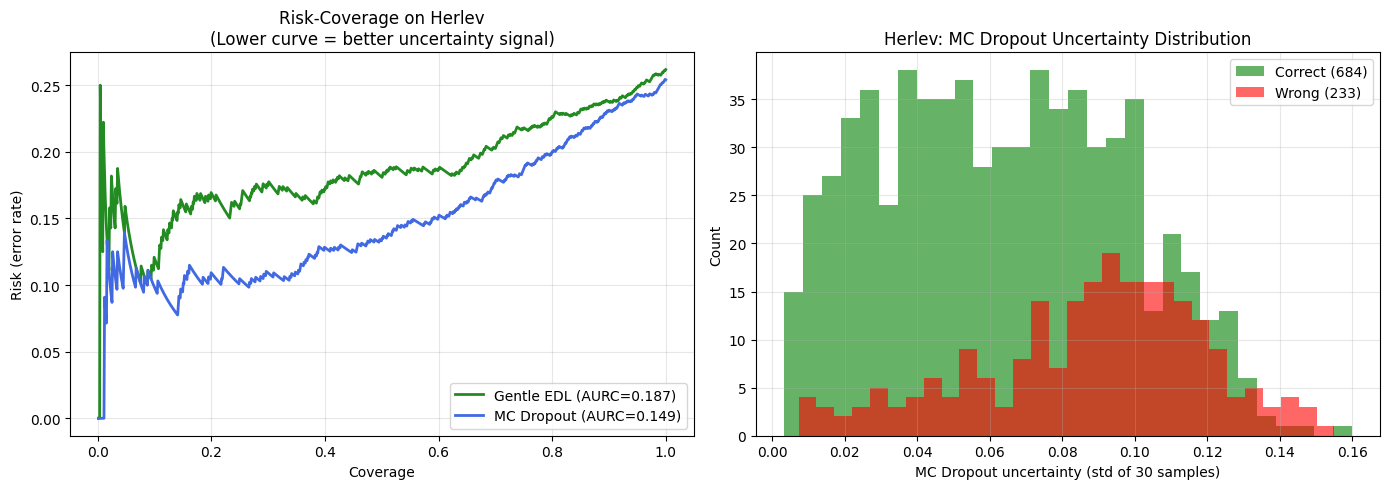

In [119]:
# Save MC Dropout results
pd.DataFrame([m_int_mc, m_ext_mc]).to_csv(
    os.path.join(OUTPUT_DIR, f'mcdropout_metrics_seed{SEED}.csv'), index=False)

pd.concat([
    pd.DataFrame({'split': 'SIPaKMeD_test', 'true': y_int_mc, 'pred': pred_int_mc,
                  'prob_abnormal': prob_int_mc, 'uncertainty': uncert_int_mc}),
    pd.DataFrame({'split': 'Herlev_external', 'true': y_ext_mc, 'pred': pred_ext_mc,
                  'prob_abnormal': prob_ext_mc, 'uncertainty': uncert_ext_mc}),
], ignore_index=True).to_csv(os.path.join(OUTPUT_DIR, f'mcdropout_predictions_seed{SEED}.csv'), index=False)

pd.DataFrame(history_mc).to_csv(os.path.join(OUTPUT_DIR, f'mcdropout_history_seed{SEED}.csv'), index=False)
print('Saved.')

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Risk-coverage comparison — EDL vs MC Dropout
ax = axes[0]
ax.plot(cov_ext_v2, risk_ext_v2, label=f'Gentle EDL (AURC={aurc_ext_v2:.3f})', linewidth=2, color='forestgreen')
ax.plot(cov_ext_mc, risk_ext_mc, label=f'MC Dropout (AURC={aurc_ext_mc:.3f})', linewidth=2, color='royalblue')
ax.set_xlabel('Coverage')
ax.set_ylabel('Risk (error rate)')
ax.set_title('Risk-Coverage on Herlev\n(Lower curve = better uncertainty signal)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: MC Dropout uncertainty histogram
ax = axes[1]
correct_mask = (y_ext_mc == pred_ext_mc)
ax.hist(uncert_ext_mc[correct_mask], bins=30, alpha=0.6, label=f'Correct ({correct_mask.sum()})', color='green')
ax.hist(uncert_ext_mc[~correct_mask], bins=30, alpha=0.6, label=f'Wrong ({(~correct_mask).sum()})', color='red')
ax.set_xlabel('MC Dropout uncertainty (std of 30 samples)')
ax.set_ylabel('Count')
ax.set_title('Herlev: MC Dropout Uncertainty Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'mcdropout_analysis_seed{SEED}.png'), dpi=150, bbox_inches='tight')
plt.show()

In [120]:
import os

# Tell me which dataset folder you're looking at
DATASET_TO_INSPECT = '/content/drive/MyDrive/datasets/Mendeley_LBC'  # ← change to your actual path

print(f'Looking at: {DATASET_TO_INSPECT}\n')

if not os.path.exists(DATASET_TO_INSPECT):
    print('❌ Folder does not exist. Check the path.')
else:
    # Show top-level structure
    for item in sorted(os.listdir(DATASET_TO_INSPECT)):
        full_path = os.path.join(DATASET_TO_INSPECT, item)
        if os.path.isdir(full_path):
            n_files = len(os.listdir(full_path))
            print(f'  📁 {item}/  ({n_files} items)')
        else:
            size_kb = os.path.getsize(full_path) / 1024
            print(f'  📄 {item}  ({size_kb:.1f} KB)')

    # Show a few example filenames
    print('\nFirst 5 image filenames found anywhere:')
    count = 0
    for root, dirs, files in os.walk(DATASET_TO_INSPECT):
        for f in files:
            if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tif','.tiff','.gif')):
                rel_path = os.path.relpath(os.path.join(root, f), DATASET_TO_INSPECT)
                print(f'  {rel_path}')
                count += 1
                if count >= 5:
                    break
        if count >= 5:
            break

Looking at: /content/drive/MyDrive/datasets/Mendeley_LBC

❌ Folder does not exist. Check the path.


In [121]:
# Direct download Mendeley LBC from the official Mendeley Data repository
import os

# Create a folder for datasets in Colab's temporary storage
os.makedirs('/content/datasets/Mendeley_LBC', exist_ok=True)
os.chdir('/content/datasets/Mendeley_LBC')

# Download from Mendeley Data
!wget --quiet "https://data.mendeley.com/public-files/datasets/zddtpgzv63/files/0a3d0b6c-9e74-4ec1-bf2b-5b62b75b8a04/file_downloaded" -O mendeley_lbc.zip

# Check it downloaded
import os
size_mb = os.path.getsize('mendeley_lbc.zip') / 1024 / 1024
print(f'Downloaded {size_mb:.1f} MB')

# Unzip
!unzip -q mendeley_lbc.zip
!rm mendeley_lbc.zip

# Show what we got
print('\nDataset structure:')
for item in sorted(os.listdir('/content/datasets/Mendeley_LBC')):
    full = os.path.join('/content/datasets/Mendeley_LBC', item)
    if os.path.isdir(full):
        n = len([f for f in os.listdir(full) if not os.path.isdir(os.path.join(full, f))])
        print(f'  📁 {item}/  ({n} files)')
    else:
        print(f'  📄 {item}')

Downloaded 0.0 MB
[mendeley_lbc.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of mendeley_lbc.zip or
        mendeley_lbc.zip.zip, and cannot find mendeley_lbc.zip.ZIP, period.

Dataset structure:


In [122]:
# Set up Kaggle with the new-style access token
# IMPORTANT: paste your token between the quotes below, then delete this cell after running
import os
from getpass import getpass

# This prompts you to type/paste the token — it won't be visible in the output
print('Paste your Kaggle token (starts with KGAT_) and press Enter:')
KAGGLE_TOKEN = getpass('Token:')

# Save it to the right location
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(KAGGLE_TOKEN.strip())
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)

print('✓ Token saved.')

# Install/upgrade kaggle library
!pip install -q --upgrade kaggle

# Test
print('\nTesting connection...')
!kaggle datasets list -s "cervical" 2>&1 | head -10

Paste your Kaggle token (starts with KGAT_) and press Enter:
Token:··········
✓ Token saved.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.8/243.8 kB 13.6 MB/s eta 0:00:00

Testing connection...
ref                                                            title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  ------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
loveall/cervical-cancer-risk-classification                    Cervical Cancer Risk Classification                      9052  2017-08-31 01:02:22.583000          35866        598  0.8235294        
prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed   Cervical Cancer largest dataset (SipakMed)         6875604663  202

In [123]:
import os

# Create folder and download
os.makedirs('/content/datasets', exist_ok=True)

print('Downloading Mendeley LBC (~2.2 GB, this may take 2-5 minutes)...')
!kaggle datasets download -d blank1508/mendeley-lbc-cervical-cancer -p /content/datasets/mendeley_lbc --unzip

print('\n✓ Download complete.')
print('\nWhat we got:')
import os
for item in sorted(os.listdir('/content/datasets/mendeley_lbc')):
    full = os.path.join('/content/datasets/mendeley_lbc', item)
    if os.path.isdir(full):
        n = len(os.listdir(full))
        print(f'  📁 {item}/  ({n} items)')
    else:
        size_mb = os.path.getsize(full) / 1024 / 1024
        print(f'  📄 {item}  ({size_mb:.1f} MB)')

Dataset URL: https://www.kaggle.com/datasets/blank1508/mendeley-lbc-cervical-cancer
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.06G/2.06G [00:25<00:00, 85.7MB/s]


✓ Download complete.

What we got:
  📁 High squamous intra-epithelial lesion/  (163 items)
  📁 Low squamous intra-epithelial lesion/  (113 items)
  📁 Negative for Intraepithelial malignancy/  (613 items)
  📁 Squamous cell carcinoma/  (74 items)


In [124]:
# Look at the dataset structure 2-3 levels deep
import os

ROOT = '/content/datasets/mendeley_lbc'
print(f'Detailed structure of {ROOT}:\n')

def show_tree(path, prefix='', depth=0, max_depth=3):
    if depth > max_depth:
        return
    items = sorted(os.listdir(path))
    dirs = [i for i in items if os.path.isdir(os.path.join(path, i))]
    files = [i for i in items if not os.path.isdir(os.path.join(path, i))]

    image_files = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tif','.tiff'))]
    other_files = [f for f in files if f not in image_files]

    if image_files:
        print(f'{prefix}📸 {len(image_files)} images')
        # show a sample filename
        print(f'{prefix}   sample: {image_files[0]}')
    if other_files:
        print(f'{prefix}📄 {len(other_files)} other files: {other_files[:3]}')

    for d in dirs:
        print(f'{prefix}📁 {d}/')
        show_tree(os.path.join(path, d), prefix + '  ', depth + 1, max_depth)

show_tree(ROOT)

Detailed structure of /content/datasets/mendeley_lbc:

📁 High squamous intra-epithelial lesion/
  📸 163 images
     sample: HSIL_1 (1).jpg
📁 Low squamous intra-epithelial lesion/
  📸 113 images
     sample: LSIL_1 (1).jpg
📁 Negative for Intraepithelial malignancy/
  📸 612 images
     sample: NL_10_ (1).jpg
  📄 1 other files: ['Results.csv']
📁 Squamous cell carcinoma/
  📸 74 images
     sample: SCC_3 (1).jpg


In [125]:
print('=== Searching for CRIC ===\n')
!kaggle datasets list -s "CRIC" --max-size 5000 2>&1 | head -20
print('\n=== Searching for cervix image recognition ===\n')
!kaggle datasets list -s "cervix recognition" 2>&1 | head -15

=== Searching for CRIC ===

ref                                                               title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
drahulsingh/virat-kohli-all-international-cricket-centuries       Virat-Kohli-All-International-Cricket-Centuries           2230  2023-11-27 18:08:57.650000           4830         87                1  
muhammadaammartufail/hbl-psl-2026-cricket-players-auction-prices  HBL PSL 2026 Cricket Players Auction Prices               1096  2026-02-13 09:35:14.667000            412         78                1  
drahulsingh/rohit-sharma-all-international-cricket-centuries      Rohit-Sharma-All-International-Cricket-Centuries          1472  2023-06-30 17:24:12.853000        

In [126]:
import os
import shutil

SRC = '/content/datasets/mendeley_lbc'
DST = '/content/datasets/mendeley_lbc_organized'

# Map: folder name → binary label
CLASS_MAP = {
    'Negative for Intraepithelial malignancy': 'normal',
    'High squamous intra-epithelial lesion': 'abnormal',
    'Low squamous intra-epithelial lesion': 'abnormal',
    'Squamous cell carcinoma': 'abnormal',
}

# Create target folders
os.makedirs(os.path.join(DST, 'normal'), exist_ok=True)
os.makedirs(os.path.join(DST, 'abnormal'), exist_ok=True)

# Copy files into the right folders
counts = {'normal': 0, 'abnormal': 0}
for src_folder, target_label in CLASS_MAP.items():
    src_path = os.path.join(SRC, src_folder)
    if not os.path.exists(src_path):
        print(f'⚠️ Missing: {src_folder}')
        continue

    dst_path = os.path.join(DST, target_label)
    for fname in os.listdir(src_path):
        if fname.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tif','.tiff')):
            # Add original class prefix to filename to avoid collisions
            class_prefix = src_folder.split()[0][:3].lower()
            new_name = f'{class_prefix}_{fname}'
            shutil.copy2(os.path.join(src_path, fname), os.path.join(dst_path, new_name))
            counts[target_label] += 1

print(f'✓ Organized Mendeley LBC into:')
print(f'  {DST}/normal/   ({counts["normal"]} images)')
print(f'  {DST}/abnormal/ ({counts["abnormal"]} images)')
print(f'  Total: {sum(counts.values())} images')

✓ Organized Mendeley LBC into:
  /content/datasets/mendeley_lbc_organized/normal/   (612 images)
  /content/datasets/mendeley_lbc_organized/abnormal/ (350 images)
  Total: 962 images


In [127]:
# Use the same collect_samples function from Week 1/2 to verify it loads cleanly
def collect_samples(root):
    samples = []
    for sub, label in [('normal', 0), ('abnormal', 1)]:
        folder = os.path.join(root, sub)
        for r, dirs, files in os.walk(folder):
            for f in files:
                if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tif','.tiff')):
                    samples.append((os.path.join(r, f), label))
    return samples

mendeley_samples = collect_samples('/content/datasets/mendeley_lbc_organized')
labels = [s[1] for s in mendeley_samples]
print(f'Mendeley LBC ready: {len(mendeley_samples)} images')
print(f'  Normal:   {labels.count(0)}')
print(f'  Abnormal: {labels.count(1)}')

# Quick image sanity check — load one image to confirm files aren't corrupt
from PIL import Image
sample_path, sample_label = mendeley_samples[0]
img = Image.open(sample_path).convert('RGB')
print(f'\nFirst image: {sample_path}')
print(f'  Size: {img.size}, Label: {"normal" if sample_label == 0 else "abnormal"}')

Mendeley LBC ready: 962 images
  Normal:   612
  Abnormal: 350

First image: /content/datasets/mendeley_lbc_organized/normal/neg_NL_6_ (4).jpg
  Size: (2048, 1536), Label: normal


In [128]:
# Build a DataLoader for Mendeley LBC (using the same eval_transform from before)
from torch.utils.data import DataLoader

MENDELEY_ROOT = '/content/datasets/mendeley_lbc_organized'

# Make sure CervicalDataset and eval_transform are still in memory
# If not, you'd need to re-run those definitions from Week 2

mendeley_samples = collect_samples(MENDELEY_ROOT)
mendeley_dataset = CervicalDataset(mendeley_samples, transform=eval_transform, dataset_name='mendeley_lbc')
mendeley_loader = DataLoader(mendeley_dataset, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)

print(f'Mendeley LBC DataLoader ready: {len(mendeley_samples)} images')
print(f'  Normal:   {sum(1 for s in mendeley_samples if s[1] == 0)}')
print(f'  Abnormal: {sum(1 for s in mendeley_samples if s[1] == 1)}')

Mendeley LBC DataLoader ready: 962 images
  Normal:   612
  Abnormal: 350


In [129]:
# Load the Week 1 baseline model
from torchvision import models
import torch.nn as nn
import os # Import os module for path manipulation

def build_resnet50(num_classes=2, pretrained=True):
    weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
    m = models.resnet50(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

baseline_model = build_resnet50(num_classes=2, pretrained=True).to(device)

# Correcting WEEK1_MODEL_PATH to point to the local outputs directory with an absolute path
WEEK1_MODEL_PATH = os.path.join('/content', 'outputs', f'resnet50_baseline_seed{SEED}.pt')

ckpt = torch.load(WEEK1_MODEL_PATH, map_location=device, weights_only=False)
baseline_model.load_state_dict(ckpt['model_state_dict'])
baseline_model.eval()
print(f'Loaded Week 1 baseline (val_acc={ckpt["val_acc"]:.4f})')


# Standard prediction function (no uncertainty — this is just Week 1)
@torch.no_grad()
def predict_baseline(model, loader, device):
    model.eval()
    all_lbls, all_preds, all_probs = [], [], []
    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        all_lbls.extend(labels.numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs[:, 1].cpu().numpy().tolist())
    return np.array(all_lbls), np.array(all_preds), np.array(all_probs)


# Predict on Mendeley LBC
print('\nRunning Week 1 baseline on Mendeley LBC...')
y_mend, pred_mend_w1, prob_mend_w1 = predict_baseline(baseline_model, mendeley_loader, device)

# Compute basic metrics (no uncertainty for baseline — pass zeros)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

cm = confusion_matrix(y_mend, pred_mend_w1, labels=[0,1])
tn, fp, fn, tp = cm.ravel()
sens = tp / (tp+fn) if (tp+fn) > 0 else 0
spec = tn / (tn+fp) if (tn+fp) > 0 else 0
fnr = fn / (fn+tp) if (fn+tp) > 0 else 0

print('\n=== Week 1 Baseline on Mendeley LBC (NEW dataset) ===')
print(f'  Accuracy:    {accuracy_score(y_mend, pred_mend_w1):.4f}')
print(f'  Sensitivity: {sens:.4f}')
print(f'  Specificity: {spec:.4f}')
print(f'  F1 abnormal: {f1_score(y_mend, pred_mend_w1, pos_label=1, zero_division=0):.4f}')
print(f'  AUC:         {roc_auc_score(y_mend, prob_mend_w1):.4f}')
print(f'  FNR:         {fnr:.4f}')
print(f'  Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}')

Loaded Week 1 baseline (val_acc=0.9973)

Running Week 1 baseline on Mendeley LBC...

=== Week 1 Baseline on Mendeley LBC (NEW dataset) ===
  Accuracy:    0.6331
  Sensitivity: 0.9971
  Specificity: 0.4248
  F1 abnormal: 0.6641
  AUC:         0.8815
  FNR:         0.0029
  Confusion: TN=260, FP=352, FN=1, TP=349


In [130]:
# Reload the Gentle EDL model (in case session reset)
edl_model_v2 = EvidentialResNet50(num_classes=2, pretrained=True).to(device)
edl_v2_path = os.path.join(OUTPUT_DIR, f'resnet50_edl_v2_seed{SEED}.pt')
ckpt = torch.load(edl_v2_path, map_location=device, weights_only=False)
edl_model_v2.load_state_dict(ckpt['model_state_dict'])
edl_model_v2.eval()
print(f'Loaded Gentle EDL (val_acc={ckpt["val_acc"]:.4f})')

# Predict with uncertainty
print('\nRunning Gentle EDL on Mendeley LBC...')
y_mend_edl, pred_mend_edl, prob_mend_edl, uncert_mend_edl = predict_with_uncertainty(
    edl_model_v2, mendeley_loader, device)

m_mend_edl, cm_mend_edl = compute_metrics(y_mend_edl, pred_mend_edl, prob_mend_edl,
                                          uncert_mend_edl, 'Mendeley_LBC_edl')

print('\n=== Gentle EDL on Mendeley LBC ===')
for k, v in m_mend_edl.items():
    print(f'  {k:32s}: {v:.4f}' if isinstance(v, float) else f'  {k:32s}: {v}')

Loaded Gentle EDL (val_acc=0.9973)

Running Gentle EDL on Mendeley LBC...

=== Gentle EDL on Mendeley LBC ===
  split                           : Mendeley_LBC_edl
  n_samples                       : 962
  accuracy                        : 0.6279
  sensitivity                     : 0.9971
  specificity                     : 0.4167
  f1_abnormal                     : 0.6610
  auc                             : 0.8787
  false_negative_rate             : 0.0029
  mean_uncertainty                : 0.4029
  mean_uncert_when_correct        : 0.3807
  mean_uncert_when_wrong          : 0.4402
  mean_uncert_false_negatives     : 0.4682
  TN                              : 255
  FP                              : 357
  FN                              : 1
  TP                              : 349


In [131]:
# Reload MC Dropout model
mc_model = MCDropoutResNet50(num_classes=2, pretrained=True, dropout_prob=0.3).to(device)
mc_checkpoint_path = os.path.join(OUTPUT_DIR, f'resnet50_mcdropout_seed{SEED}.pt')
ckpt = torch.load(mc_checkpoint_path, map_location=device, weights_only=False)
mc_model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded MC Dropout (val_acc={ckpt["val_acc"]:.4f})')

# Predict with MC Dropout (30 forward passes)
print('\nRunning MC Dropout on Mendeley LBC (30 forward passes — takes ~3 min)...')
y_mend_mc, pred_mend_mc, prob_mend_mc, uncert_mend_mc = predict_mc_dropout(
    mc_model, mendeley_loader, device, n_samples=30)

m_mend_mc, cm_mend_mc = compute_metrics(y_mend_mc, pred_mend_mc, prob_mend_mc,
                                        uncert_mend_mc, 'Mendeley_LBC_mc')

print('\n=== MC Dropout on Mendeley LBC ===')
for k, v in m_mend_mc.items():
    print(f'  {k:32s}: {v:.4f}' if isinstance(v, float) else f'  {k:32s}: {v}')

Loaded MC Dropout (val_acc=0.9348)

Running MC Dropout on Mendeley LBC (30 forward passes — takes ~3 min)...

=== MC Dropout on Mendeley LBC ===
  split                           : Mendeley_LBC_mc
  n_samples                       : 962
  accuracy                        : 0.4751
  sensitivity                     : 0.9029
  specificity                     : 0.2304
  f1_abnormal                     : 0.5558
  auc                             : 0.4783
  false_negative_rate             : 0.0971
  mean_uncertainty                : 0.0955
  mean_uncert_when_correct        : 0.0978
  mean_uncert_when_wrong          : 0.0934
  mean_uncert_false_negatives     : 0.1224
  TN                              : 141
  FP                              : 471
  FN                              : 34
  TP                              : 316


In [132]:
print('=' * 70)
print('DEFERRAL ON MENDELEY LBC — does uncertainty help on a SECOND new dataset?')
print('=' * 70)

for name, y, pred, uncert in [
    ('Gentle EDL',  y_mend_edl, pred_mend_edl, uncert_mend_edl),
    ('MC Dropout',  y_mend_mc,  pred_mend_mc,  uncert_mend_mc),
]:
    print(f'\n--- {name} ---')
    print(f'{"Coverage":>10}  {"Cases":>8}  {"Accuracy":>10}  {"FNR":>10}')
    for keep_frac in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]:
        n_keep = int(len(y) * keep_frac)
        order = np.argsort(uncert)
        kept_idx = order[:n_keep]
        if n_keep > 0:
            acc = (y[kept_idx] == pred[kept_idx]).mean()
            fn_k = ((y[kept_idx] == 1) & (pred[kept_idx] == 0)).sum()
            tp_k = ((y[kept_idx] == 1) & (pred[kept_idx] == 1)).sum()
            fnr_k = fn_k / (fn_k + tp_k) if (fn_k + tp_k) > 0 else 0
            print(f'{keep_frac:>10.0%}  {n_keep:>8d}  {acc:>10.4f}  {fnr_k:>10.4f}')

# AURC for both
cov_e, risk_e, aurc_e = risk_coverage_analysis(y_mend_edl, pred_mend_edl, uncert_mend_edl)
cov_m, risk_m, aurc_m = risk_coverage_analysis(y_mend_mc,  pred_mend_mc,  uncert_mend_mc)
print(f'\nAURC on Mendeley LBC (lower=better):')
print(f'  Gentle EDL:  {aurc_e:.4f}')
print(f'  MC Dropout:  {aurc_m:.4f}')

DEFERRAL ON MENDELEY LBC — does uncertainty help on a SECOND new dataset?

--- Gentle EDL ---
  Coverage     Cases    Accuracy         FNR
      100%       962      0.6279      0.0029
       90%       865      0.6462      0.0029
       80%       769      0.6775      0.0030
       70%       673      0.6954      0.0000
       60%       577      0.7210      0.0000
       50%       481      0.7609      0.0000

--- MC Dropout ---
  Coverage     Cases    Accuracy         FNR
      100%       962      0.4751      0.0971
       90%       865      0.4821      0.0703
       80%       769      0.4746      0.0547
       70%       673      0.4695      0.0418
       60%       577      0.4575      0.0394
       50%       481      0.4491      0.0355

AURC on Mendeley LBC (lower=better):
  Gentle EDL:  0.2213
  MC Dropout:  0.5841


/tmp/ipykernel_458/2116398524.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc = np.trapz(risks, coverages)


In [133]:
import pandas as pd

print('=' * 80)
print('THREE-DATASET ROBUSTNESS COMPARISON')
print('=' * 80)
print('\nAccuracy + AURC across SIPaKMeD (internal) | Herlev (external) | Mendeley LBC (external):\n')

# Compute Mendeley baseline metrics for the table
acc_mend_baseline = accuracy_score(y_mend, pred_mend_w1)
fnr_mend_baseline = ((y_mend == 1) & (pred_mend_w1 == 0)).sum() / max(1, (y_mend == 1).sum())

# Build the comparison
results_table = pd.DataFrame({
    'Method': ['Week 1 baseline', 'Gentle EDL', 'MC Dropout'],

    'SIPaKMeD acc':   [0.9986, m_int_v2['accuracy'] if 'm_int_v2' in dir() else None,
                       m_int_mc['accuracy'] if 'm_int_mc' in dir() else None],

    'Herlev acc':     [0.7426, m_ext_v2['accuracy'] if 'm_ext_v2' in dir() else None,
                       m_ext_mc['accuracy'] if 'm_ext_mc' in dir() else None],
    'Herlev FNR':     [0.1837, m_ext_v2['false_negative_rate'] if 'm_ext_v2' in dir() else None,
                       m_ext_mc['false_negative_rate'] if 'm_ext_mc' in dir() else None],
    'Herlev AURC':    ['N/A', round(aurc_ext_v2, 4) if 'aurc_ext_v2' in dir() else None,
                       round(aurc_ext_mc, 4) if 'aurc_ext_mc' in dir() else None],

    'Mendeley acc':   [acc_mend_baseline, m_mend_edl['accuracy'], m_mend_mc['accuracy']],
    'Mendeley FNR':   [fnr_mend_baseline, m_mend_edl['false_negative_rate'], m_mend_mc['false_negative_rate']],
    'Mendeley AURC':  ['N/A', round(aurc_e, 4), round(aurc_m, 4)],
})

print(results_table.to_string(index=False))

print('\n')
print('=' * 80)
print('Deferral at 50% coverage — across BOTH external datasets:')
print('=' * 80)
print(f'\n{"Method":<15} {"Herlev FNR@50%":>16} {"Mendeley FNR@50%":>18}')
for name, (uH, yH, pH), (uM, yM, pM) in [
    ('Gentle EDL',  (uncert_ext_v2, y_ext_v2, pred_ext_v2), (uncert_mend_edl, y_mend_edl, pred_mend_edl)),
    ('MC Dropout',  (uncert_ext_mc, y_ext_mc, pred_ext_mc), (uncert_mend_mc, y_mend_mc, pred_mend_mc)),
]:
    def fnr_at(y, pred, uncert, frac=0.5):
        n_keep = int(len(y) * frac)
        order = np.argsort(uncert)
        kept = order[:n_keep]
        fn = ((y[kept] == 1) & (pred[kept] == 0)).sum()
        tp = ((y[kept] == 1) & (pred[kept] == 1)).sum()
        return fn / (fn + tp) if (fn + tp) > 0 else 0

    h = fnr_at(yH, pH, uH)
    m = fnr_at(yM, pM, uM)
    print(f'{name:<15} {h:>16.4f} {m:>18.4f}')

THREE-DATASET ROBUSTNESS COMPARISON

Accuracy + AURC across SIPaKMeD (internal) | Herlev (external) | Mendeley LBC (external):

         Method  SIPaKMeD acc  Herlev acc  Herlev FNR Herlev AURC  Mendeley acc  Mendeley FNR Mendeley AURC
Week 1 baseline      0.998600    0.742600    0.183700         N/A      0.633056      0.002857           N/A
     Gentle EDL      0.996019    0.738277    0.151111      0.1873      0.627859      0.002857        0.2213
     MC Dropout      0.933643    0.745911    0.200000      0.1489      0.475052      0.097143        0.5841


Deferral at 50% coverage — across BOTH external datasets:

Method            Herlev FNR@50%   Mendeley FNR@50%
Gentle EDL                0.0323             0.0000
MC Dropout                0.0564             0.0355


In [134]:
from google.colab import drive
drive.mount('/content/drive')

import os
folder = '/content/drive/MyDrive/cervical_q1_results'

if os.path.exists(folder):
    print(f'Contents of {folder}:\n')
    for f in sorted(os.listdir(folder)):
        size_mb = os.path.getsize(os.path.join(folder, f)) / 1024 / 1024
        print(f'  {f}  ({size_mb:.2f} MB)')
else:
    print('Folder not found.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contents of /content/drive/MyDrive/cervical_q1_results:

  confusion_matrices_seed123.png  (0.04 MB)
  edl_history_seed123.csv  (0.00 MB)
  edl_metrics_seed123.csv  (0.00 MB)
  edl_predictions_seed123.csv  (0.13 MB)
  edl_uncertainty_analysis_seed123.png  (0.11 MB)
  edl_v2_comparison_seed123.png  (0.11 MB)
  edl_v2_history_seed123.csv  (0.00 MB)
  edl_v2_metrics_seed123.csv  (0.00 MB)
  edl_v2_predictions_seed123.csv  (0.13 MB)
  mcdropout_analysis_seed123.png  (0.13 MB)
  mcdropout_history_seed123.csv  (0.00 MB)
  mcdropout_metrics_seed123.csv  (0.00 MB)
  mcdropout_predictions_seed123.csv  (0.13 MB)
  metrics_seed123.csv  (0.00 MB)
  predictions_seed123.csv  (0.09 MB)
  resnet50_baseline_seed123.pt  (90.00 MB)
  resnet50_edl_seed123.pt  (90.00 MB)
  resnet50_edl_v2_seed123.pt  (90.00 MB)
  resnet50_mcdropout_seed123.pt  (90.01 MB)
  roc_curves_seed123.png 

In [135]:
import os
files = os.listdir('/content/drive/MyDrive/cervical_q1_results')
baseline_files = [f for f in files if 'baseline' in f.lower()]
print('Baseline files found:', baseline_files)
print('\nAll .pt files:')
for f in files:
    if f.endswith('.pt'):
        print(f'  {f}')

Baseline files found: ['resnet50_baseline_seed123.pt']

All .pt files:
  resnet50_baseline_seed123.pt
  resnet50_edl_seed123.pt
  resnet50_edl_v2_seed123.pt
  resnet50_mcdropout_seed123.pt


In [136]:
# Changing seed to 123
import os

SIPAKMED_ROOT = '/content/drive/MyDrive/datasets/SIPaKMeD'
HERLEV_ROOT   = '/content/drive/MyDrive/datasets/Herlev'
OUTPUT_DIR    = '/content/drive/MyDrive/cervical_q1_results'

IMAGE_SIZE    = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 15
LEARNING_RATE = 1e-4
SEED          = 123

print('Config set.')

Config set.


In [137]:
# Check if our key variables still exist from earlier in the session
checks = {
    'train_loader':    'train_loader' in dir(),
    'val_loader':      'val_loader' in dir(),
    'CervicalDataset': 'CervicalDataset' in dir(),
    'device':          'device' in dir(),
}
print('What\'s in memory:')
for k, v in checks.items():
    print(f'  {k}: {"✓" if v else "✗ NEED TO REBUILD"}')

print('\nIf any are missing, run CELL 4 to rebuild them.')
print('If all are ✓, skip to CELL 5.')

What's in memory:
  train_loader: ✓
  val_loader: ✓
  CervicalDataset: ✓
  device: ✓

If any are missing, run CELL 4 to rebuild them.
If all are ✓, skip to CELL 5.


In [138]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import shutil
import zipfile

# Reproducibility
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(torch.cuda.device_count() > 0)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

class CervicalDataset(Dataset):
    def __init__(self, samples, transform=None, dataset_name='unknown'):
        self.samples = samples
        self.transform = transform
        self.dataset_name = dataset_name
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label, self.dataset_name

def collect_samples(root):
    samples = []
    for sub, label in [('normal', 0), ('abnormal', 1)]:
        folder = os.path.join(root, sub)
        for r, dirs, files in os.walk(folder):
            for f in files:
                if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tif','.tiff')):
                    samples.append((os.path.join(r, f), label))
    return samples

def stratified_split(samples, train_frac=0.70, val_frac=0.15, seed=42):
    rng = random.Random(seed)
    by_class = {0: [], 1: []}
    for s in samples:
        by_class[s[1]].append(s)
    train, val, test = [], [], []
    for label, items in by_class.items():
        items = items.copy(); rng.shuffle(items)
        n = len(items)
        n_train = int(n * train_frac); n_val = int(n * val_frac)
        train.extend(items[:n_train])
        val.extend(items[n_train:n_train + n_val])
        test.extend(items[n_train + n_val:])
    rng.shuffle(train); rng.shuffle(val); rng.shuffle(test)
    return train, val, test

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Correcting the root paths to the locally reorganized datasets
SIPAKMED_ROOT = 'data'
HERLEV_ROOT   = '/content/herlev_data/extracted/Herlev Dataset'

# --- Reorganization logic for SIPaKMeD to ensure correct structure ---
SIPAKMED_NORMAL_CATEGORIES = ['im_Parabasal', 'im_Superficial-Intermediate']
SIPAKMED_ABNORMAL_CATEGORIES = ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic']

def reorganize_dataset_structure(base_root, normal_cats, abnormal_cats, source_subdirs=None, sipakmed_nested_path=False):
    """
    Reorganizes dataset into 'normal' and 'abnormal' parent directories.
    Moves original category folders/contents into the new structure.
    `sipakmed_nested_path`: If True, assumes SIPaKMeD-like nesting (e.g., category/category/CROPPED).
    """
    new_normal_dir = os.path.join(base_root, "normal")
    new_abnormal_dir = os.path.join(base_root, "abnormal")

    # Clear existing normal/abnormal folders in base_root before reorganizing
    if os.path.exists(new_normal_dir): shutil.rmtree(new_normal_dir)
    if os.path.exists(new_abnormal_dir): shutil.rmtree(new_abnormal_dir)
    os.makedirs(new_normal_dir, exist_ok=True)
    os.makedirs(new_abnormal_dir, exist_ok=True)

    # Collect source directories to move from and their corresponding category names
    sources_to_move = [] # list of (source_path, category_name)

    if source_subdirs: # For Herlev (train/test splits)
        print(f"Processing {base_root} with source subdirectories: {source_subdirs}")
        for sub_dir in source_subdirs:
            current_split_path = os.path.join(base_root, sub_dir)
            if os.path.exists(current_split_path):
                for cat_name in os.listdir(current_split_path):
                    cat_full_path = os.path.join(current_split_path, cat_name)
                    if os.path.isdir(cat_full_path) and (cat_name in normal_cats or cat_name in abnormal_cats):
                        sources_to_move.append((cat_full_path, cat_name))
            else:
                print(f"Warning: Source subdirectory {current_split_path} not found.")

    else: # For SIPaKMeD (direct categories under base_root, possibly nested)
        print(f"Processing {base_root} with direct categories (SIPaKMeD-like: {sipakmed_nested_path}).")
        # Collect top-level directories first, to differentiate from 'normal'/'abnormal' target dirs
        top_level_items = [d for d in os.listdir(base_root) if os.path.isdir(os.path.join(base_root, d)) and d not in ['normal', 'abnormal']]
        for cat_name in top_level_items:
            if cat_name in normal_cats or cat_name in abnormal_cats:
                if sipakmed_nested_path:
                    # For SIPaKMeD, the actual images are in data/im_Category/im_Category/CROPPED
                    source_path = os.path.join(base_root, cat_name, cat_name, 'CROPPED')
                else:
                    # For a simpler direct category structure, images are directly in data/im_Category
                    source_path = os.path.join(base_root, cat_name)

                if os.path.exists(source_path):
                    sources_to_move.append((source_path, cat_name))
                else:
                    print(f"Warning: Expected source path {source_path} not found for category {cat_name}. Skipping.")
            elif cat_name not in ['normal', 'abnormal']: # Ignore the target directories
                print(f"Info: Top-level directory '{os.path.join(base_root, cat_name)}' not classified. Will be cleaned later if empty.")


    for source_dir, category_name in sources_to_move:
        if category_name in normal_cats:
            target_parent_dir = new_normal_dir
        elif category_name in abnormal_cats:
            target_parent_dir = new_abnormal_dir
        else:
            # This should ideally not happen if `sources_to_move` is built correctly
            print(f"Warning: Category '{category_name}' not classified. Skipping movement for {source_dir}.")
            continue

        # Create the specific category folder within 'normal' or 'abnormal'
        target_cat_folder = os.path.join(target_parent_dir, category_name)
        os.makedirs(target_cat_folder, exist_ok=True)

        print(f"Moving contents from '{source_dir}' to '{target_cat_folder}'")
        for item_name in os.listdir(source_dir):
            source_item_path = os.path.join(source_dir, item_name)
            target_item_path = os.path.join(target_cat_folder, item_name)
            try:
                # If target_item_path already exists and it's a file, shutil.move will overwrite or error.
                # If it's a directory, shutil.move might merge.
                # For this application, it's safer to move files individually and handle duplicates.
                if os.path.isdir(source_item_path):
                    # If it's a subdirectory, move the whole thing
                    shutil.move(source_item_path, target_item_path)
                else:
                    # If it's a file, ensure we don't overwrite if not desired, or rename
                    if not os.path.exists(target_item_path): # Only move if target doesn't exist to prevent errors
                        shutil.move(source_item_path, target_item_path)
                    else:
                        print(f"Warning: File '{item_name}' already exists in '{target_cat_folder}'. Skipping move for this file.")
            except shutil.Error as e:
                # This catches errors like destination already exists, or permission errors
                print(f"Shutil Error moving '{source_item_path}' to '{target_item_path}': {e}")
            except Exception as e:
                print(f"An unexpected error occurred moving '{source_item_path}' to '{target_item_path}': {e}")

    # General cleanup of any empty directories left behind, excluding the new 'normal'/'abnormal' structure.
    for root, dirs, files in os.walk(base_root, topdown=False): # topdown=False for bottom-up removal
        for d in dirs:
            dir_path = os.path.join(root, d)
            if not os.listdir(dir_path) and d not in ['normal', 'abnormal'] and d not in normal_cats and d not in abnormal_cats: # Avoid deleting the new structure itself
                try:
                    shutil.rmtree(dir_path)
                    print(f"Cleaned up empty directory: {dir_path}")
                except OSError as e:
                    print(f"Error removing empty directory {dir_path}: {e}")

# --- Data Preparation for SIPaKMeD ---
zip_file_path_sipakmed = "/content/cervical-cancer-largest-dataset-sipakmed.zip"

# Ensure SIPAKMED_ROOT is cleaned before re-extraction
if os.path.exists(SIPAKMED_ROOT):
    print(f"Deleting existing SIPaKMeD root directory: {SIPAKMED_ROOT}")
    shutil.rmtree(SIPAKMED_ROOT)
os.makedirs(SIPAKMED_ROOT, exist_ok=True)

print(f"Re-extracting SIPaKMeD dataset from {zip_file_path_sipakmed}...")
if os.path.exists(zip_file_path_sipakmed):
    with zipfile.ZipFile(zip_file_path_sipakmed, "r") as zip_ref:
        zip_ref.extractall(SIPAKMED_ROOT) # Extract to the cleaned SIPAKMED_ROOT
    print("SIPaKMeD re-extracted.")
else:
    print(f"Error: SIPaKMeD zip file not found at {zip_file_path_sipakmed}. Cannot proceed with extraction.")

print("Reorganizing SIPaKMeD dataset...")
reorganize_dataset_structure(
    base_root=SIPAKMED_ROOT,
    normal_cats=SIPAKMED_NORMAL_CATEGORIES,
    abnormal_cats=SIPAKMED_ABNORMAL_CATEGORIES,
    sipakmed_nested_path=True # Correct setting for SIPaKMeD
)
print("SIPaKMeD reorganization complete.")

# --- Data Preparation for Herlev ---
HERLEV_NORMAL_CATEGORIES = [
    'normal_intermediate',
    'normal_superficiel',
    'normal_columnar'
]
HERLEV_ABNORMAL_CATEGORIES = [
    'light_dysplastic',
    'moderate_dysplastic',
    'severe_dysplastic',
    'carcinoma_in_situ'
]

# Define paths for Herlev extraction
zip_file_path_herlev = "/content/herlev_data/herlev-dataset.zip"
herlev_extract_path = "/content/herlev_data/extracted"

# Ensure the HERLEV_ROOT directory is clean before re-extraction
# The actual Herlev data is extracted into a subdirectory 'Herlev Dataset'
# so we delete that if it exists.
if os.path.exists(HERLEV_ROOT):
    print(f"Deleting existing Herlev root directory for reorganization: {HERLEV_ROOT}")
    shutil.rmtree(HERLEV_ROOT)
# We also ensure the parent extracted folder exists to extract into
os.makedirs(herlev_extract_path, exist_ok=True)

print(f"Re-extracting Herlev dataset from {zip_file_path_herlev}...")
if os.path.exists(zip_file_path_herlev):
    with zipfile.ZipFile(zip_file_path_herlev, "r") as zip_ref:
        zip_ref.extractall(herlev_extract_path) # Extract to the cleaned herlev_extract_path
    print("Herlev re-extracted.")
else:
    print(f"Error: Herlev zip file not found at {zip_file_path_herlev}. Cannot proceed with extraction.")

print("Reorganizing Herlev dataset...")
reorganize_dataset_structure(
    base_root=HERLEV_ROOT,
    normal_cats=HERLEV_NORMAL_CATEGORIES,
    abnormal_cats=HERLEV_ABNORMAL_CATEGORIES,
    source_subdirs=['train', 'test'],
    sipakmed_nested_path=False # Herlev is not nested like SIPaKMeD
)
print("Herlev reorganization complete.")

sipakmed_samples = collect_samples(SIPAKMED_ROOT)
herlev_samples = collect_samples(HERLEV_ROOT)

# Ensure samples are not empty after reorganization
if not sipakmed_samples:
    raise ValueError("SIPaKMeD samples are still empty after reorganization. Check dataset source and reorganization logic.")

train_samples, val_samples, test_samples = stratified_split(
    sipakmed_samples, 0.70, 0.15, seed=SEED)

train_loader = DataLoader(CervicalDataset(train_samples, train_transform, 'sipakmed'),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(CervicalDataset(val_samples, eval_transform, 'sipakmed'),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(CervicalDataset(test_samples, eval_transform, 'sipakmed'),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# For Herlev, we only create the loader for external evaluation, not for splitting here.
# Ensure herlev_samples are not empty before creating herlev_loader
if not herlev_samples:
    print("Warning: Herlev samples are empty. Herlev_loader will not be created or will be empty.")
    # Optionally, raise an error or handle empty loader if critical
    herlev_loader = None # or an empty DataLoader if appropriate
else:
    herlev_loader= DataLoader(CervicalDataset(herlev_samples, eval_transform, 'herlev'),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Data loaders ready: train={len(train_samples)}, val={len(val_samples)}, test={len(test_samples)}')


Device: cuda
Re-extracting SIPaKMeD dataset from /content/cervical-cancer-largest-dataset-sipakmed.zip...
SIPaKMeD re-extracted.
Reorganizing SIPaKMeD dataset...
Processing data with direct categories (SIPaKMeD-like: True).
Moving contents from 'data/im_Parabasal/im_Parabasal/CROPPED' to 'data/normal/im_Parabasal'
Moving contents from 'data/im_Koilocytotic/im_Koilocytotic/CROPPED' to 'data/abnormal/im_Koilocytotic'
Moving contents from 'data/im_Metaplastic/im_Metaplastic/CROPPED' to 'data/abnormal/im_Metaplastic'
Moving contents from 'data/im_Superficial-Intermediate/im_Superficial-Intermediate/CROPPED' to 'data/normal/im_Superficial-Intermediate'
Moving contents from 'data/im_Dyskeratotic/im_Dyskeratotic/CROPPED' to 'data/abnormal/im_Dyskeratotic'
Cleaned up empty directory: data/im_Parabasal/im_Parabasal/CROPPED
Cleaned up empty directory: data/im_Koilocytotic/im_Koilocytotic/CROPPED
Cleaned up empty directory: data/im_Metaplastic/im_Metaplastic/CROPPED
Cleaned up empty directory: da

In [139]:
import os

baseline_path = os.path.join(OUTPUT_DIR, f'resnet50_baseline_seed{SEED}.pt')

if os.path.exists(baseline_path):
    size_mb = os.path.getsize(baseline_path) / 1024 / 1024
    print(f'✓ Baseline saved: {baseline_path}')
    print(f'  Size: {size_mb:.1f} MB')
else:
    print(f'✗ Not found at: {baseline_path}')

✓ Baseline saved: /content/drive/MyDrive/cervical_q1_results/resnet50_baseline_seed123.pt
  Size: 90.0 MB


In [140]:
import os

# Check the dataset paths the new setup created
print('Dataset folders that exist:')
for path in ['data/normal', 'data/abnormal', '/content/data/normal', '/content/data/abnormal',
             '/content/drive/MyDrive/datasets/SIPaKMeD/normal']:
    exists = os.path.exists(path)
    print(f'  {"✓" if exists else "✗"} {path}')

# Check what variables are in memory
print('\nVariables in memory:')
for var in ['train_loader', 'val_loader', 'test_loader', 'baseline_model', 'device', 'OUTPUT_DIR']:
    in_mem = var in dir()
    print(f'  {"✓" if in_mem else "✗"} {var}')

# Check what's in your output folder
print('\nFiles in output folder:')
output_dir = '/content/drive/MyDrive/cervical_q1_results'
if os.path.exists(output_dir):
    pt_files = [f for f in os.listdir(output_dir) if f.endswith('.pt')]
    print(f'  .pt files: {pt_files}')
else:
    print('  Output folder does not exist!')

Dataset folders that exist:
  ✓ data/normal
  ✓ data/abnormal
  ✓ /content/data/normal
  ✓ /content/data/abnormal
  ✗ /content/drive/MyDrive/datasets/SIPaKMeD/normal

Variables in memory:
  ✓ train_loader
  ✓ val_loader
  ✓ test_loader
  ✓ baseline_model
  ✓ device
  ✓ OUTPUT_DIR

Files in output folder:
  .pt files: ['resnet50_baseline_seed123.pt', 'resnet50_edl_seed123.pt', 'resnet50_edl_v2_seed123.pt', 'resnet50_mcdropout_seed123.pt']


In [141]:
# Check that splits are the same as before
print(f'train_loader has {len(train_loader.dataset)} samples')
print(f'val_loader has   {len(val_loader.dataset)} samples')
print(f'test_loader has  {len(test_loader.dataset)} samples')
print(f'Total: {len(train_loader.dataset) + len(val_loader.dataset) + len(test_loader.dataset)}')

# What seed is currently set?
print(f'\nSEED variable: {SEED if "SEED" in dir() else "NOT SET"}')

train_loader has 2833 samples
val_loader has   606 samples
test_loader has  610 samples
Total: 4049

SEED variable: 123


In [142]:
import time
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models

# === Setup ===
SEED = 123
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# === Build a fresh ResNet50 baseline ===
def build_resnet50(num_classes=2, pretrained=True):
    weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
    m = models.resnet50(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

baseline_model = build_resnet50(num_classes=2, pretrained=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(baseline_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


# === Training and evaluation functions ===
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        # Handle 2-item or 3-item batches
        if len(batch) == 3:
            images, labels, _ = batch
        else:
            images, labels = batch
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        if len(batch) == 3:
            images, labels, _ = batch
        else:
            images, labels = batch
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


# === Training loop ===
best_val_acc = 0.0
baseline_path = os.path.join(OUTPUT_DIR, f'resnet50_baseline_seed{SEED}.pt')
history = []

print(f'Training Week 1 baseline for {NUM_EPOCHS} epochs...')
print(f'Will save best model to: {baseline_path}\n')

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_epoch(baseline_model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_epoch(baseline_model, val_loader, criterion, device)
    scheduler.step()
    elapsed = time.time() - t0
    history.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc,
                    'val_loss': val_loss, 'val_acc': val_acc, 'time_sec': elapsed})
    star = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({'epoch': epoch, 'model_state_dict': baseline_model.state_dict(),
                    'val_acc': val_acc, 'seed': SEED}, baseline_path)
        star = ' ← SAVED'
    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train_acc={train_acc:.4f} val_acc={val_acc:.4f}  ({elapsed:.1f}s){star}')

print(f'\n✓ Best val accuracy: {best_val_acc:.4f}')
print(f'  Saved to: {baseline_path}')

Training Week 1 baseline for 15 epochs...
Will save best model to: /content/drive/MyDrive/cervical_q1_results/resnet50_baseline_seed123.pt

Epoch  1/15  train_acc=0.9216 val_acc=0.9901  (39.7s) ← SAVED
Epoch  2/15  train_acc=0.9816 val_acc=0.9967  (36.0s) ← SAVED
Epoch  3/15  train_acc=0.9873 val_acc=0.9835  (37.4s)
Epoch  4/15  train_acc=0.9905 val_acc=0.9917  (36.9s)
Epoch  5/15  train_acc=0.9933 val_acc=0.9934  (36.6s)
Epoch  6/15  train_acc=0.9982 val_acc=0.9934  (36.8s)
Epoch  7/15  train_acc=0.9954 val_acc=0.9950  (36.6s)
Epoch  8/15  train_acc=0.9972 val_acc=0.9967  (37.0s)
Epoch  9/15  train_acc=0.9958 val_acc=0.9950  (36.7s)
Epoch 10/15  train_acc=0.9996 val_acc=0.9967  (36.7s)
Epoch 11/15  train_acc=0.9979 val_acc=0.9967  (36.6s)
Epoch 12/15  train_acc=0.9996 val_acc=0.9967  (36.9s)
Epoch 13/15  train_acc=0.9989 val_acc=0.9967  (36.9s)
Epoch 14/15  train_acc=1.0000 val_acc=0.9967  (36.9s)
Epoch 15/15  train_acc=0.9986 val_acc=0.9967  (36.7s)

✓ Best val accuracy: 0.9967
  Sav

In [143]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import torch.nn.functional as F

# Load the baseline we just trained
baseline_path = os.path.join(OUTPUT_DIR, f'resnet50_baseline_seed{SEED}.pt')
ckpt = torch.load(baseline_path, map_location=device, weights_only=False)
baseline_model.load_state_dict(ckpt['model_state_dict'])
baseline_model.eval()

@torch.no_grad()
def quick_eval(model, loader, name, device):
    all_y, all_p, all_prob = [], [], []
    for batch in loader:
        if len(batch) == 3:
            images, labels, _ = batch
        else:
            images, labels = batch
        images = images.to(device)
        logits = model(images)
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        all_y.extend(labels.numpy().tolist())
        all_p.extend(preds.cpu().numpy().tolist())
        all_prob.extend(probs[:, 1].cpu().numpy().tolist())
    y, p, prob = np.array(all_y), np.array(all_p), np.array(all_prob)
    cm = confusion_matrix(y, p, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    print(f'{name}: acc={accuracy_score(y,p):.4f}, AUC={roc_auc_score(y,prob):.4f}, '
          f'FNR={fn/(fn+tp):.4f}, TN={tn} FP={fp} FN={fn} TP={tp}')
    return y, p, prob

# Test on SIPaKMeD test set
print('Verifying retrained baseline:')
quick_eval(baseline_model, test_loader, 'SIPaKMeD test', device)

Verifying retrained baseline:
SIPaKMeD test: acc=0.9918, AUC=0.9984, FNR=0.0137, TN=244 FP=0 FN=5 TP=361


(array([1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
        0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
        0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
        0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
        0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
        1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
        0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
        0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
        1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
        1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
        0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 

In [144]:
import torch
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Load the freshly trained baseline
baseline_path = os.path.join(OUTPUT_DIR, f'resnet50_baseline_seed{SEED}.pt')
ckpt = torch.load(baseline_path, map_location=device, weights_only=False)
baseline_model.load_state_dict(ckpt['model_state_dict'])
baseline_model.eval()
print(f'Loaded baseline from {baseline_path}')
print(f'Best val acc was: {ckpt["val_acc"]:.4f}\n')


@torch.no_grad()
def quick_eval(model, loader, name, device):
    all_y, all_p, all_prob = [], [], []
    for batch in loader:
        if len(batch) == 3:
            images, labels, _ = batch
        else:
            images, labels = batch
        images = images.to(device)
        logits = model(images)
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        all_y.extend(labels.numpy().tolist())
        all_p.extend(preds.cpu().numpy().tolist())
        all_prob.extend(probs[:, 1].cpu().numpy().tolist())
    y, p, prob = np.array(all_y), np.array(all_p), np.array(all_prob)
    cm = confusion_matrix(y, p, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f'{name:25s}: acc={accuracy_score(y,p):.4f}  '
          f'AUC={roc_auc_score(y,prob):.4f}  '
          f'FNR={fnr:.4f}  '
          f'Spec={spec:.4f}  '
          f'(TN={tn}, FP={fp}, FN={fn}, TP={tp})')
    return y, p, prob


# Evaluate on all three datasets
print('=' * 80)
print('Baseline (Week 1) — Cross-Dataset Performance')
print('=' * 80)
quick_eval(baseline_model, test_loader, 'SIPaKMeD test (internal)', device)
quick_eval(baseline_model, herlev_loader, 'Herlev (external 1)', device)

# For Mendeley — only run if mendeley_loader exists
if 'mendeley_loader' in dir():
    quick_eval(baseline_model, mendeley_loader, 'Mendeley LBC (external 2)', device)
else:
    print('Mendeley loader not in memory — skip for now, we can rebuild later')

Loaded baseline from /content/drive/MyDrive/cervical_q1_results/resnet50_baseline_seed123.pt
Best val acc was: 0.9967

Baseline (Week 1) — Cross-Dataset Performance
SIPaKMeD test (internal) : acc=0.9918  AUC=0.9984  FNR=0.0137  Spec=1.0000  (TN=244, FP=0, FN=5, TP=361)
Herlev (external 1)      : acc=0.7339  AUC=0.7487  FNR=0.2222  Spec=0.6116  (TN=148, FP=94, FN=150, TP=525)
Mendeley LBC (external 2): acc=0.6414  AUC=0.8255  FNR=0.9800  Spec=0.9967  (TN=610, FP=2, FN=343, TP=7)


In [145]:
import os

print('=== Where is the data the model trained on? ===\n')

# Check the data folder used during training
paths_to_check = [
    'data/normal',
    'data/abnormal',
    '/content/data/normal',
    '/content/data/abnormal',
    '/content/drive/MyDrive/datasets/SIPaKMeD/normal',
    '/content/drive/MyDrive/datasets/SIPaKMeD/abnormal',
]

for path in paths_to_check:
    if os.path.exists(path):
        n_images = 0
        sample_files = []
        for root, dirs, files in os.walk(path):
            for f in files:
                if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tif','.tiff')):
                    n_images += 1
                    if len(sample_files) < 3:
                        sample_files.append(f)
        print(f'✓ {path}')
        print(f'  Images: {n_images}')
        print(f'  Samples: {sample_files}\n')
    else:
        print(f'✗ {path}  (does not exist)\n')

print('=== What did train_loader actually use? ===')
print(f'train_loader has {len(train_loader.dataset.samples)} samples')
print(f'val_loader has   {len(val_loader.dataset.samples)} samples')
print(f'test_loader has  {len(test_loader.dataset.samples)} samples')

# Show a few sample paths from train_loader
print('\nFirst 5 training sample paths:')
for path, label in train_loader.dataset.samples[:5]:
    print(f'  label={label}: {path}')

# Class distribution
labels = [s[1] for s in train_loader.dataset.samples]
print(f'\nTrain class counts: normal(0)={labels.count(0)}, abnormal(1)={labels.count(1)}')

labels = [s[1] for s in test_loader.dataset.samples]
print(f'Test class counts:  normal(0)={labels.count(0)}, abnormal(1)={labels.count(1)}')

=== Where is the data the model trained on? ===

✓ data/normal
  Images: 1618
  Samples: ['008_06.bmp', '092_02.bmp', '104_03.bmp']

✓ data/abnormal
  Images: 2431
  Samples: ['091_03.bmp', '077_06.bmp', '092_02.bmp']

✓ /content/data/normal
  Images: 3704
  Samples: ['071.bmp', '029.bmp', '018.bmp']

✓ /content/data/abnormal
  Images: 6326
  Samples: ['071.bmp', '029.bmp', '184.bmp']

✗ /content/drive/MyDrive/datasets/SIPaKMeD/normal  (does not exist)

✗ /content/drive/MyDrive/datasets/SIPaKMeD/abnormal  (does not exist)

=== What did train_loader actually use? ===
train_loader has 2833 samples
val_loader has   606 samples
test_loader has  610 samples

First 5 training sample paths:
  label=0: data/normal/im_Parabasal/002_01.bmp
  label=0: data/normal/im_Parabasal/054_08.bmp
  label=1: data/abnormal/im_Koilocytotic/089_05.bmp
  label=1: data/abnormal/im_Metaplastic/225_05.bmp
  label=1: data/abnormal/im_Dyskeratotic/122_02.bmp

Train class counts: normal(0)=1132, abnormal(1)=1701
Test

In [146]:
import os
import shutil

# Move Metaplastic from abnormal to normal
src = 'data/abnormal/im_Metaplastic'
dst = 'data/normal/im_Metaplastic'

if os.path.exists(src):
    if os.path.exists(dst):
        print(f'⚠️ {dst} already exists — checking contents')
        for f in os.listdir(src):
            shutil.move(os.path.join(src, f), os.path.join(dst, f))
        os.rmdir(src)
        print(f'✓ Moved Metaplastic files to {dst}')
    else:
        shutil.move(src, dst)
        print(f'✓ Moved {src} → {dst}')
else:
    print(f'✗ {src} does not exist (maybe already fixed?)')

# Verify
print('\n=== After fix ===')
for folder in ['data/normal', 'data/abnormal']:
    n = 0
    subdirs = []
    for sub in os.listdir(folder):
        sub_path = os.path.join(folder, sub)
        if os.path.isdir(sub_path):
            count = sum(1 for f in os.listdir(sub_path)
                        if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tif','.tiff')))
            subdirs.append(f'{sub}={count}')
            n += count
    print(f'{folder}: {n} images total ({", ".join(subdirs)})')

✓ Moved data/abnormal/im_Metaplastic → data/normal/im_Metaplastic

=== After fix ===
data/normal: 2411 images total (im_Parabasal=787, im_Metaplastic=793, im_Superficial-Intermediate=831)
data/abnormal: 1638 images total (im_Koilocytotic=825, im_Dyskeratotic=813)


In [147]:
# Rebuild loaders from the corrected folder structure
sipakmed_samples = collect_samples('data')  # 'data' is the corrected root
train_samples, val_samples, test_samples = stratified_split(
    sipakmed_samples, 0.70, 0.15, seed=SEED)

train_loader = DataLoader(CervicalDataset(train_samples, train_transform, 'sipakmed'),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(CervicalDataset(val_samples, eval_transform, 'sipakmed'),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(CervicalDataset(test_samples, eval_transform, 'sipakmed'),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Splits: train={len(train_samples)}, val={len(val_samples)}, test={len(test_samples)}')

# Verify class balance
for name, split in [('train', train_samples), ('val', val_samples), ('test', test_samples)]:
    labels = [s[1] for s in split]
    print(f'  {name}: normal={labels.count(0)}, abnormal={labels.count(1)}')

Splits: train=2833, val=606, test=610
  train: normal=1687, abnormal=1146
  val: normal=361, abnormal=245
  test: normal=363, abnormal=247


In [148]:
import torch
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the existing Gentle EDL model
edl_model_v2 = EvidentialResNet50(num_classes=2, pretrained=True).to(device)
ckpt = torch.load(os.path.join(OUTPUT_DIR, f'resnet50_edl_v2_seed{SEED}.pt'),
                  map_location=device, weights_only=False)
edl_model_v2.load_state_dict(ckpt['model_state_dict'])
edl_model_v2.eval()

@torch.no_grad()
def eval_edl_quick(model, loader, name):
    all_y, all_p = [], []
    for batch in loader:
        if len(batch) == 3:
            images, labels, _ = batch
        else:
            images, labels = batch
        images = images.to(device)
        evidence = model(images)
        probs, _ = evidence_to_uncertainty(evidence)
        preds = probs.argmax(dim=1)
        all_y.extend(labels.numpy().tolist())
        all_p.extend(preds.cpu().numpy().tolist())
    y, p = np.array(all_y), np.array(all_p)
    cm = confusion_matrix(y, p, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y, p)
    fnr = fn/(fn+tp) if (fn+tp)>0 else 0
    print(f'{name}: acc={acc:.4f}  FNR={fnr:.4f}  (TN={tn}, FP={fp}, FN={fn}, TP={tp})')
    return acc

print('=== Testing existing EDL model on the CORRECTED test set ===\n')
acc = eval_edl_quick(edl_model_v2, test_loader, 'EDL on SIPaKMeD test')

print()
if acc > 0.95:
    print('✅ EDL model was trained on CORRECT labels — keep it')
elif acc < 0.50:
    print('⚠️ EDL was trained on BROKEN labels — needs retraining')
else:
    print('🤔 Borderline — send me the numbers and we discuss')

=== Testing existing EDL model on the CORRECTED test set ===

EDL on SIPaKMeD test: acc=0.8164  FNR=0.0000  (TN=251, FP=112, FN=0, TP=247)

🤔 Borderline — send me the numbers and we discuss


In [149]:
# Quick check: does this bias appear on Herlev too?

print('=== Testing EDL on Herlev with corrected labels ===\n')

# First we need a Herlev loader — rebuild if needed

herlev_samples = collect_samples(HERLEV_ROOT)  # original Herlev path

herlev_loader = DataLoader(

    CervicalDataset(herlev_samples, eval_transform, 'herlev'),

    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Herlev: {len(herlev_samples)} samples')

labels = [s[1] for s in herlev_samples]

print(f'  Normal: {labels.count(0)}, Abnormal: {labels.count(1)}\n')

# Test EDL on Herlev

eval_edl_quick(edl_model_v2, herlev_loader, 'EDL on Herlev')

=== Testing EDL on Herlev with corrected labels ===

Herlev: 917 samples
  Normal: 242, Abnormal: 675

EDL on Herlev: acc=0.7383  FNR=0.1511  (TN=104, FP=138, FN=102, TP=573)


0.7382769901853872

In [150]:
# ===================================================================
# CLEAN RETRAIN: Baseline → Gentle EDL → MC Dropout
# All three models trained on CORRECTED label structure
# Total time: ~25 minutes (you can step away)
# ===================================================================

import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models

# Settings
SEED = 123
NUM_EPOCHS_BASELINE = 15
NUM_EPOCHS_EDL = 5      # frozen backbone — fast
NUM_EPOCHS_MC = 5       # frozen backbone — fast
LEARNING_RATE_BASELINE = 1e-4
LEARNING_RATE_EDL = 1e-5
LEARNING_RATE_MC = 1e-4

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ===================================================================
# PART 1: TRAIN BASELINE (~10 min)
# ===================================================================
print('=' * 70)
print('PART 1: Training BASELINE ResNet50 (15 epochs)')
print('=' * 70)
set_seed(SEED)

def build_resnet50(num_classes=2, pretrained=True):
    weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
    m = models.resnet50(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

baseline_model = build_resnet50(num_classes=2, pretrained=True).to(device)
optimizer = Adam(baseline_model.parameters(), lr=LEARNING_RATE_BASELINE, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS_BASELINE)
criterion = nn.CrossEntropyLoss()


def train_one_epoch_ce(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        images, labels = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss/total, correct/total


@torch.no_grad()
def eval_one_epoch_ce(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        images, labels = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss/total, correct/total


best_val_baseline = 0.0
baseline_path = os.path.join(OUTPUT_DIR, f'resnet50_baseline_seed{SEED}.pt')
for epoch in range(1, NUM_EPOCHS_BASELINE + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch_ce(baseline_model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_one_epoch_ce(baseline_model, val_loader, criterion, device)
    scheduler.step()
    star = ''
    if val_acc > best_val_baseline:
        best_val_baseline = val_acc
        torch.save({'epoch': epoch, 'model_state_dict': baseline_model.state_dict(),
                    'val_acc': val_acc, 'seed': SEED}, baseline_path)
        star = ' ← SAVED'
    print(f'  Baseline Ep {epoch:2d}/{NUM_EPOCHS_BASELINE}  '
          f'train_acc={tr_acc:.4f} val_acc={val_acc:.4f}  ({time.time()-t0:.1f}s){star}')

print(f'\n✓ Baseline best val acc: {best_val_baseline:.4f}\n')


# ===================================================================
# PART 2: TRAIN GENTLE EDL (~5 min, frozen backbone)
# ===================================================================
print('=' * 70)
print('PART 2: Training GENTLE EDL (5 epochs, frozen backbone)')
print('=' * 70)
set_seed(SEED)

class EvidentialResNet50(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
        self.num_classes = num_classes
    def forward(self, x):
        return F.softplus(self.backbone(x))


def evidence_to_uncertainty(evidence):
    K = evidence.shape[1]
    alpha = evidence + 1.0
    S = alpha.sum(dim=1, keepdim=True)
    probabilities = alpha / S
    uncertainty = (K / S).squeeze(1)
    return probabilities, uncertainty


def kl_dirichlet(alpha, num_classes):
    sum_alpha = alpha.sum(dim=1, keepdim=True)
    first = (torch.lgamma(sum_alpha)
             - torch.lgamma(torch.tensor(float(num_classes), device=alpha.device))
             - torch.lgamma(alpha).sum(dim=1, keepdim=True))
    second = ((alpha - 1) * (torch.digamma(alpha) - torch.digamma(sum_alpha))).sum(dim=1, keepdim=True)
    return (first + second).squeeze(1)


def edl_loss(evidence, labels, epoch, total_epochs, num_classes=2, kl_max=0.5):
    y_onehot = F.one_hot(labels, num_classes=num_classes).float()
    alpha = evidence + 1.0
    S = alpha.sum(dim=1, keepdim=True)
    p_hat = alpha / S
    mse_term = ((y_onehot - p_hat) ** 2).sum(dim=1)
    var_term = (p_hat * (1 - p_hat) / (S + 1)).sum(dim=1)
    alpha_tilde = y_onehot + (1 - y_onehot) * alpha
    kl_term = kl_dirichlet(alpha_tilde, num_classes)
    lambda_t = min(kl_max, kl_max * epoch / total_epochs)
    return (mse_term + var_term + lambda_t * kl_term).mean()


# Build EDL model, load corrected baseline weights, freeze backbone
edl_model_v2 = EvidentialResNet50(num_classes=2, pretrained=True).to(device)
ckpt = torch.load(baseline_path, map_location=device, weights_only=False)
edl_model_v2.backbone.load_state_dict(ckpt['model_state_dict'])
print(f'  Loaded corrected baseline as warm start')

for name, param in edl_model_v2.named_parameters():
    param.requires_grad = ('backbone.fc' in name)

optimizer_edl = Adam([p for p in edl_model_v2.parameters() if p.requires_grad],
                     lr=LEARNING_RATE_EDL, weight_decay=1e-5)


def train_one_epoch_edl(model, loader, optimizer, epoch, total_epochs, device):
    model.train()
    for n, m in model.named_modules():
        if 'backbone.fc' not in n and hasattr(m, 'eval'):
            m.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        images, labels = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
        optimizer.zero_grad()
        evidence = model(images)
        loss = edl_loss(evidence, labels, epoch, total_epochs)
        loss.backward()
        optimizer.step()
        probs, _ = evidence_to_uncertainty(evidence)
        preds = probs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss/total, correct/total


@torch.no_grad()
def eval_one_epoch_edl(model, loader, epoch, total_epochs, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        images, labels = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
        evidence = model(images)
        loss = edl_loss(evidence, labels, epoch, total_epochs)
        probs, _ = evidence_to_uncertainty(evidence)
        preds = probs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss/total, correct/total


best_val_edl = 0.0
edl_path = os.path.join(OUTPUT_DIR, f'resnet50_edl_v2_seed{SEED}.pt')
for epoch in range(1, NUM_EPOCHS_EDL + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch_edl(edl_model_v2, train_loader, optimizer_edl, epoch, NUM_EPOCHS_EDL, device)
    val_loss, val_acc = eval_one_epoch_edl(edl_model_v2, val_loader, epoch, NUM_EPOCHS_EDL, device)
    star = ''
    if val_acc > best_val_edl:
        best_val_edl = val_acc
        torch.save({'epoch': epoch, 'model_state_dict': edl_model_v2.state_dict(),
                    'val_acc': val_acc, 'seed': SEED}, edl_path)
        star = ' ← SAVED'
    print(f'  EDL Ep {epoch}/{NUM_EPOCHS_EDL}  '
          f'train_acc={tr_acc:.4f} val_acc={val_acc:.4f}  ({time.time()-t0:.1f}s){star}')

print(f'\n✓ Gentle EDL best val acc: {best_val_edl:.4f}\n')


# ===================================================================
# PART 3: TRAIN MC DROPOUT (~5 min, frozen backbone)
# ===================================================================
print('=' * 70)
print('PART 3: Training MC DROPOUT (5 epochs, frozen backbone)')
print('=' * 70)
set_seed(SEED)

class MCDropoutResNet50(nn.Module):
    def __init__(self, num_classes=2, pretrained=True, dropout_prob=0.3):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout_prob),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)


mc_model = MCDropoutResNet50(num_classes=2, pretrained=True, dropout_prob=0.3).to(device)

# Load corrected baseline weights (skip the different final layer)
ckpt = torch.load(baseline_path, map_location=device, weights_only=False)
baseline_state = ckpt['model_state_dict']
mc_state = mc_model.state_dict()
copied = 0
for k, v in baseline_state.items():
    if k.startswith('backbone.fc.'):
        continue  # different structure (Dropout→Linear)
    if k in mc_state and mc_state[k].shape == v.shape:
        mc_state[k] = v
        copied += 1
mc_model.load_state_dict(mc_state)
print(f'  Copied {copied} weight tensors from corrected baseline')

# Freeze backbone except final layer
for name, param in mc_model.named_parameters():
    param.requires_grad = ('backbone.fc' in name)

optimizer_mc = Adam([p for p in mc_model.parameters() if p.requires_grad],
                   lr=LEARNING_RATE_MC, weight_decay=1e-5)
criterion_mc = nn.CrossEntropyLoss()


def train_one_epoch_mc(model, loader, optimizer, criterion, device):
    model.train()
    for n, m in model.named_modules():
        if 'backbone.fc' not in n and hasattr(m, 'eval'):
            m.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        images, labels = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss/total, correct/total


best_val_mc = 0.0
mc_path = os.path.join(OUTPUT_DIR, f'resnet50_mcdropout_seed{SEED}.pt')
for epoch in range(1, NUM_EPOCHS_MC + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch_mc(mc_model, train_loader, optimizer_mc, criterion_mc, device)
    val_loss, val_acc = eval_one_epoch_ce(mc_model, val_loader, criterion_mc, device)
    star = ''
    if val_acc > best_val_mc:
        best_val_mc = val_acc
        torch.save({'epoch': epoch, 'model_state_dict': mc_model.state_dict(),
                    'val_acc': val_acc, 'seed': SEED}, mc_path)
        star = ' ← SAVED'
    print(f'  MC Dropout Ep {epoch}/{NUM_EPOCHS_MC}  '
          f'train_acc={tr_acc:.4f} val_acc={val_acc:.4f}  ({time.time()-t0:.1f}s){star}')

print(f'\n✓ MC Dropout best val acc: {best_val_mc:.4f}\n')


# ===================================================================
# DONE!
# ===================================================================
print('=' * 70)
print('ALL THREE MODELS RETRAINED ON CORRECTED LABELS')
print('=' * 70)
print(f'  Baseline:    val_acc={best_val_baseline:.4f}  → {baseline_path}')
print(f'  Gentle EDL:  val_acc={best_val_edl:.4f}  → {edl_path}')
print(f'  MC Dropout:  val_acc={best_val_mc:.4f}  → {mc_path}')
print()
print('Next: run quick evaluation on all three datasets to see clean numbers.')

PART 1: Training BASELINE ResNet50 (15 epochs)
  Baseline Ep  1/15  train_acc=0.9178 val_acc=0.9686  (38.5s) ← SAVED
  Baseline Ep  2/15  train_acc=0.9675 val_acc=0.9703  (36.3s) ← SAVED
  Baseline Ep  3/15  train_acc=0.9742 val_acc=0.9719  (37.5s) ← SAVED
  Baseline Ep  4/15  train_acc=0.9799 val_acc=0.9851  (37.1s) ← SAVED
  Baseline Ep  5/15  train_acc=0.9855 val_acc=0.9785  (37.3s)
  Baseline Ep  6/15  train_acc=0.9891 val_acc=0.9835  (36.9s)
  Baseline Ep  7/15  train_acc=0.9876 val_acc=0.9868  (37.6s) ← SAVED
  Baseline Ep  8/15  train_acc=0.9894 val_acc=0.9868  (36.8s)
  Baseline Ep  9/15  train_acc=0.9933 val_acc=0.9884  (37.5s) ← SAVED
  Baseline Ep 10/15  train_acc=0.9947 val_acc=0.9917  (37.0s) ← SAVED
  Baseline Ep 11/15  train_acc=0.9944 val_acc=0.9868  (36.8s)
  Baseline Ep 12/15  train_acc=0.9968 val_acc=0.9868  (36.7s)
  Baseline Ep 13/15  train_acc=0.9968 val_acc=0.9851  (37.1s)
  Baseline Ep 14/15  train_acc=0.9986 val_acc=0.9851  (36.9s)
  Baseline Ep 15/15  train_ac

In [152]:
# Fix MC Dropout: properly copy baseline weights this time
import time

set_seed(SEED)

# Build fresh MC Dropout model
mc_model = MCDropoutResNet50(num_classes=2, pretrained=True, dropout_prob=0.3).to(device)

# Load corrected baseline and PROPERLY transfer the weights
ckpt = torch.load(os.path.join(OUTPUT_DIR, f'resnet50_baseline_seed{SEED}.pt'),
                  map_location=device, weights_only=False)
baseline_state = ckpt['model_state_dict']

# Add 'backbone.' prefix to baseline keys to match MC Dropout's structure
mc_state = mc_model.state_dict()
copied = 0
for k, v in baseline_state.items():
    new_key = f'backbone.{k}'  # ← THE FIX
    if new_key in mc_state and mc_state[new_key].shape == v.shape:
        mc_state[new_key] = v
        copied += 1

mc_model.load_state_dict(mc_state)
print(f'✓ Copied {copied} weight tensors (should be 318+)')

if copied < 100:
    print('⚠️ Still not enough copied — something else is wrong')
else:
    print('✓ Backbone successfully transferred from baseline\n')

# Freeze backbone, train only final layer
for name, param in mc_model.named_parameters():
    param.requires_grad = ('backbone.fc' in name)

optimizer_mc = Adam([p for p in mc_model.parameters() if p.requires_grad],
                   lr=1e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()


def train_one_epoch_mc(model, loader, optimizer, criterion, device):
    model.train()
    for n, m in model.named_modules():
        if 'backbone.fc' not in n and hasattr(m, 'eval'):
            m.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        images, labels = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss/total, correct/total


@torch.no_grad()
def eval_one_epoch_mc(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        images, labels = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        preds = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += images.size(0)
    return total_loss/total, correct/total


# Retrain MC Dropout properly
print('Retraining MC Dropout with proper weight transfer...\n')
best_val_mc = 0.0
mc_path = os.path.join(OUTPUT_DIR, f'resnet50_mcdropout_seed{SEED}.pt')
for epoch in range(1, 6):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch_mc(mc_model, train_loader, optimizer_mc, criterion, device)
    val_loss, val_acc = eval_one_epoch_mc(mc_model, val_loader, criterion, device)
    star = ''
    if val_acc > best_val_mc:
        best_val_mc = val_acc
        torch.save({'epoch': epoch, 'model_state_dict': mc_model.state_dict(),
                    'val_acc': val_acc, 'seed': SEED}, mc_path)
        star = ' ← SAVED'
    print(f'  MC Dropout Ep {epoch}/5  '
          f'train_acc={tr_acc:.4f} val_acc={val_acc:.4f}  ({time.time()-t0:.1f}s){star}')

print(f'\n✓ MC Dropout best val acc: {best_val_mc:.4f}')
print(f'  Expected: ~98% (matching baseline) if weights transferred correctly')

✓ Copied 318 weight tensors (should be 318+)
✓ Backbone successfully transferred from baseline

Retraining MC Dropout with proper weight transfer...

  MC Dropout Ep 1/5  train_acc=0.9989 val_acc=0.9901  (16.6s) ← SAVED
  MC Dropout Ep 2/5  train_acc=0.9996 val_acc=0.9901  (16.7s)
  MC Dropout Ep 3/5  train_acc=0.9996 val_acc=0.9901  (16.0s)
  MC Dropout Ep 4/5  train_acc=1.0000 val_acc=0.9901  (16.3s)
  MC Dropout Ep 5/5  train_acc=0.9996 val_acc=0.9901  (15.8s)

✓ MC Dropout best val acc: 0.9901
  Expected: ~98% (matching baseline) if weights transferred correctly


In [153]:
# ===================================================================
# CLEAN EVALUATION: All three models on all three datasets
# ===================================================================

import os
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, f1_score

# Make sure mendeley_loader exists
if 'mendeley_loader' not in dir():
    mendeley_samples = collect_samples('/content/datasets/mendeley_lbc_organized')
    mendeley_loader = DataLoader(
        CervicalDataset(mendeley_samples, eval_transform, 'mendeley'),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    print(f'Built Mendeley loader: {len(mendeley_samples)} samples')


# ===================================================================
# Helpers
# ===================================================================
@torch.no_grad()
def eval_baseline(model, loader, device):
    model.eval()
    all_y, all_p, all_prob = [], [], []
    for batch in loader:
        images, labels = batch[0].to(device), batch[1]
        logits = model(images)
        probs = F.softmax(logits, dim=1)
        all_y.extend(labels.numpy().tolist())
        all_p.extend(probs.argmax(dim=1).cpu().numpy().tolist())
        all_prob.extend(probs[:, 1].cpu().numpy().tolist())
    return np.array(all_y), np.array(all_p), np.array(all_prob)


@torch.no_grad()
def eval_edl(model, loader, device):
    model.eval()
    all_y, all_p, all_prob, all_u = [], [], [], []
    for batch in loader:
        images, labels = batch[0].to(device), batch[1]
        evidence = model(images)
        probs, uncert = evidence_to_uncertainty(evidence)
        all_y.extend(labels.numpy().tolist())
        all_p.extend(probs.argmax(dim=1).cpu().numpy().tolist())
        all_prob.extend(probs[:, 1].cpu().numpy().tolist())
        all_u.extend(uncert.cpu().numpy().tolist())
    return np.array(all_y), np.array(all_p), np.array(all_prob), np.array(all_u)


def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()


@torch.no_grad()
def eval_mc_dropout(model, loader, device, n_samples=30):
    model.eval()
    enable_dropout(model)
    all_y, all_p, all_prob, all_u = [], [], [], []
    for batch in loader:
        images, labels = batch[0].to(device), batch[1]
        sample_probs = []
        for _ in range(n_samples):
            logits = model(images)
            probs = F.softmax(logits, dim=1)
            sample_probs.append(probs.unsqueeze(0))
        sample_probs = torch.cat(sample_probs, dim=0)
        mean_probs = sample_probs.mean(dim=0)
        std_probs = sample_probs.std(dim=0)
        all_y.extend(labels.numpy().tolist())
        all_p.extend(mean_probs.argmax(dim=1).cpu().numpy().tolist())
        all_prob.extend(mean_probs[:, 1].cpu().numpy().tolist())
        all_u.extend(std_probs[:, 1].cpu().numpy().tolist())
    return np.array(all_y), np.array(all_p), np.array(all_prob), np.array(all_u)


def compute_basic_metrics(y, p, prob):
    cm = confusion_matrix(y, p, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        'accuracy': accuracy_score(y, p),
        'sensitivity': tp/(tp+fn) if (tp+fn)>0 else 0,
        'specificity': tn/(tn+fp) if (tn+fp)>0 else 0,
        'fnr': fn/(fn+tp) if (fn+tp)>0 else 0,
        'auc': roc_auc_score(y, prob) if len(set(y))>1 else float('nan'),
        'f1': f1_score(y, p, pos_label=1, zero_division=0),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }


def deferral_fnr(y, p, uncert, frac):
    n_keep = int(len(y) * frac)
    order = np.argsort(uncert)
    kept = order[:n_keep]
    fn = ((y[kept] == 1) & (p[kept] == 0)).sum()
    tp = ((y[kept] == 1) & (p[kept] == 1)).sum()
    return fn/(fn+tp) if (fn+tp)>0 else 0


def aurc(y, p, uncert):
    errors = (y != p).astype(int)
    order = np.argsort(uncert)
    sorted_errors = errors[order]
    n = len(sorted_errors)
    coverages = np.arange(1, n+1) / n
    risks = np.cumsum(sorted_errors) / np.arange(1, n+1)
    return np.trapz(risks, coverages)


# ===================================================================
# Load all three models
# ===================================================================
baseline_model = build_resnet50(num_classes=2, pretrained=True).to(device)
baseline_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, f'resnet50_baseline_seed{SEED}.pt'),
                                          map_location=device, weights_only=False)['model_state_dict'])
baseline_model.eval()

edl_model_v2 = EvidentialResNet50(num_classes=2, pretrained=True).to(device)
edl_model_v2.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, f'resnet50_edl_v2_seed{SEED}.pt'),
                                       map_location=device, weights_only=False)['model_state_dict'])
edl_model_v2.eval()

mc_model = MCDropoutResNet50(num_classes=2, pretrained=True, dropout_prob=0.3).to(device)
mc_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, f'resnet50_mcdropout_seed{SEED}.pt'),
                                    map_location=device, weights_only=False)['model_state_dict'])

print('✓ All three models loaded\n')


# ===================================================================
# Evaluate all three on all three datasets
# ===================================================================
datasets = [
    ('SIPaKMeD (internal)', test_loader),
    ('Herlev (external)',   herlev_loader),
    ('Mendeley LBC (external)', mendeley_loader),
]

results = []

for ds_name, loader in datasets:
    print(f'=== {ds_name} ===')

    # Baseline
    y, p, prob = eval_baseline(baseline_model, loader, device)
    m = compute_basic_metrics(y, p, prob)
    m.update({'dataset': ds_name, 'method': 'Baseline', 'aurc': None,
              'fnr_at_80': None, 'fnr_at_50': None})
    results.append(m)
    print(f'  Baseline:    acc={m["accuracy"]:.4f}  FNR={m["fnr"]:.4f}  AUC={m["auc"]:.4f}')

    # EDL
    y, p, prob, u = eval_edl(edl_model_v2, loader, device)
    m = compute_basic_metrics(y, p, prob)
    m.update({'dataset': ds_name, 'method': 'Gentle EDL',
              'aurc': aurc(y, p, u),
              'fnr_at_80': deferral_fnr(y, p, u, 0.8),
              'fnr_at_50': deferral_fnr(y, p, u, 0.5)})
    results.append(m)
    print(f'  EDL:         acc={m["accuracy"]:.4f}  FNR={m["fnr"]:.4f}  '
          f'AUC={m["auc"]:.4f}  AURC={m["aurc"]:.4f}  '
          f'FNR@80%={m["fnr_at_80"]:.4f}  FNR@50%={m["fnr_at_50"]:.4f}')

    # MC Dropout
    print('  Running MC Dropout (30 forward passes, takes 1-2 min)...')
    y, p, prob, u = eval_mc_dropout(mc_model, loader, device, n_samples=30)
    m = compute_basic_metrics(y, p, prob)
    m.update({'dataset': ds_name, 'method': 'MC Dropout',
              'aurc': aurc(y, p, u),
              'fnr_at_80': deferral_fnr(y, p, u, 0.8),
              'fnr_at_50': deferral_fnr(y, p, u, 0.5)})
    results.append(m)
    print(f'  MC Dropout:  acc={m["accuracy"]:.4f}  FNR={m["fnr"]:.4f}  '
          f'AUC={m["auc"]:.4f}  AURC={m["aurc"]:.4f}  '
          f'FNR@80%={m["fnr_at_80"]:.4f}  FNR@50%={m["fnr_at_50"]:.4f}')
    print()


# ===================================================================
# Final summary table
# ===================================================================
df = pd.DataFrame(results)
df_summary = df[['dataset', 'method', 'accuracy', 'sensitivity', 'specificity',
                 'fnr', 'auc', 'aurc', 'fnr_at_80', 'fnr_at_50']].copy()

print('=' * 100)
print('FINAL CLEAN RESULTS — ALL THREE MODELS, ALL THREE DATASETS')
print('=' * 100)
print(df_summary.to_string(index=False))

# Save
df_summary.to_csv(os.path.join(OUTPUT_DIR, f'clean_results_seed{SEED}.csv'), index=False)
print(f'\n✓ Saved to: {OUTPUT_DIR}/clean_results_seed{SEED}.csv')

✓ All three models loaded

=== SIPaKMeD (internal) ===
  Baseline:    acc=0.9770  FNR=0.0405  AUC=0.9975
  EDL:         acc=0.9770  FNR=0.0405  AUC=0.9975  AURC=0.0012  FNR@80%=0.0000  FNR@50%=0.0000
  Running MC Dropout (30 forward passes, takes 1-2 min)...


/tmp/ipykernel_458/2727450339.py:111: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(risks, coverages)


  MC Dropout:  acc=0.9770  FNR=0.0405  AUC=0.9974  AURC=0.0013  FNR@80%=0.0051  FNR@50%=0.0000

=== Herlev (external) ===


/tmp/ipykernel_458/2727450339.py:111: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(risks, coverages)


  Baseline:    acc=0.7372  FNR=0.2222  AUC=0.7453
  EDL:         acc=0.7350  FNR=0.2267  AUC=0.7455  AURC=0.1601  FNR@80%=0.1647  FNR@50%=0.0857
  Running MC Dropout (30 forward passes, takes 1-2 min)...


...

/tmp/ipykernel_458/2727450339.py:111: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(risks, coverages)


  Baseline:    acc=0.6279  FNR=0.9971  AUC=0.8296
  EDL:         acc=0.6279  FNR=0.9971  AUC=0.8309  AURC=0.1388  FNR@80%=0.9952  FNR@50%=1.0000
  Running MC Dropout (30 forward passes, takes 1-2 min)...


/tmp/ipykernel_458/2727450339.py:111: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(risks, coverages)


  MC Dropout:  acc=0.6279  FNR=0.9971  AUC=0.8262  AURC=0.1452  FNR@80%=0.9953  FNR@50%=1.0000

FINAL CLEAN RESULTS — ALL THREE MODELS, ALL THREE DATASETS
                dataset     method  accuracy  sensitivity  specificity      fnr      auc     aurc  fnr_at_80  fnr_at_50
    SIPaKMeD (internal)   Baseline  0.977049     0.959514     0.988981 0.040486 0.997457      NaN        NaN        NaN
    SIPaKMeD (internal) Gentle EDL  0.977049     0.959514     0.988981 0.040486 0.997535 0.001188   0.000000   0.000000
    SIPaKMeD (internal) MC Dropout  0.977049     0.959514     0.988981 0.040486 0.997401 0.001342   0.005076   0.000000
      Herlev (external)   Baseline  0.737186     0.777778     0.623967 0.222222 0.745335      NaN        NaN        NaN
      Herlev (external) Gentle EDL  0.735005     0.773333     0.628099 0.226667 0.745504 0.160109   0.164706   0.085714
      Herlev (external) MC Dropout  0.717557     0.749630     0.628099 0.250370 0.748393 0.161912   0.211350   0.096429
Mende

/tmp/ipykernel_458/2727450339.py:111: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(risks, coverages)


In [154]:
# Quick diagnostic: are we testing on the same Herlev images as before?
import os

print('=== Herlev dataset comparison ===\n')

# Check the Herlev path being used now
print(f'HERLEV_ROOT: {HERLEV_ROOT}')
print(f'  Exists: {os.path.exists(HERLEV_ROOT)}')

# Show class folders
if os.path.exists(HERLEV_ROOT):
    for sub in ['normal', 'abnormal']:
        folder = os.path.join(HERLEV_ROOT, sub)
        if os.path.exists(folder):
            n = 0
            subdirs = []
            for sd in os.listdir(folder):
                sd_path = os.path.join(folder, sd)
                if os.path.isdir(sd_path):
                    count = sum(1 for f in os.listdir(sd_path)
                                if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.tif','.tiff')))
                    subdirs.append(f'{sd}={count}')
                    n += count
            print(f'  {sub}/: {n} images ({", ".join(subdirs)})')

# Check herlev_loader
print(f'\nherlev_loader samples: {len(herlev_loader.dataset.samples)}')
labels = [s[1] for s in herlev_loader.dataset.samples]
print(f'  Normal: {labels.count(0)}, Abnormal: {labels.count(1)}')

# Show sample file paths
print(f'\nFirst 3 Herlev samples:')
for path, label in herlev_loader.dataset.samples[:3]:
    print(f'  label={label}: {path}')

=== Herlev dataset comparison ===

HERLEV_ROOT: /content/herlev_data/extracted/Herlev Dataset
  Exists: True
  normal/: 242 images (normal_superficiel=74, normal_columnar=98, normal_intermediate=70)
  abnormal/: 675 images (light_dysplastic=182, carcinoma_in_situ=150, moderate_dysplastic=146, severe_dysplastic=197)

herlev_loader samples: 917
  Normal: 242, Abnormal: 675

First 3 Herlev samples:
  label=0: /content/herlev_data/extracted/Herlev Dataset/normal/normal_superficiel/153958345-153958392-001.BMP
  label=0: /content/herlev_data/extracted/Herlev Dataset/normal/normal_superficiel/157183412-157183614-001.BMP
  label=0: /content/herlev_data/extracted/Herlev Dataset/normal/normal_superficiel/157183332-157183376-001.BMP


In [155]:
import time
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models

# Define configurations
SEEDS = [42, 123, 2024]
ARCHITECTURES = ['VGG16', 'DenseNet', 'EfficientNet', 'ViT']
BATCH_SIZE = 32
NUM_EPOCHS = 3  # Keep it concise to test all combinations quickly
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Helper function to build models dynamically
def get_model(arch_name, num_classes=2):
    if arch_name == 'VGG16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif arch_name == 'DenseNet':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif arch_name == 'EfficientNet':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif arch_name == 'ViT':
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    return model

results_summary = []

# Evaluation Master Loop
for seed in SEEDS:
    print(f"\n==================== STARTING SEED {seed} ====================")
    set_seed(seed)

    # Split datasets dynamically based on current seed
    train_s, val_s, test_s = stratified_split(sipakmed_samples, seed=seed)

    train_ds = CervicalDataset(train_s, transform=train_transform, dataset_name='sipakmed')
    val_ds = CervicalDataset(val_s, transform=eval_transform, dataset_name='sipakmed')
    herlev_ds = CervicalDataset(herlev_samples, transform=eval_transform, dataset_name='herlev')

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    herlev_loader = DataLoader(herlev_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    for arch in ARCHITECTURES:
        print(f"\nTraining {arch} with Seed {seed}...")
        model = get_model(arch).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()

        # Training loop
        for epoch in range(1, NUM_EPOCHS + 1):
            model.train()
            for imgs, lbls, _ in train_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                optimizer.zero_grad()
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                loss.backward()
                optimizer.step()

        # Evaluation
        model.eval()

        # SIPaKMeD validation
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, lbls, _ in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                preds = model(imgs).argmax(dim=1)
                val_correct += (preds == lbls).sum().item()
                val_total += lbls.size(0)
        val_acc = (val_correct / val_total) * 100

        # Herlev cross-dataset test evaluation
        herlev_correct, herlev_total = 0, 0
        with torch.no_grad():
            for imgs, lbls, _ in herlev_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                preds = model(imgs).argmax(dim=1)
                herlev_correct += (preds == lbls).sum().item()
                herlev_total += lbls.size(0)
        herlev_acc = (herlev_correct / herlev_total) * 100

        print(f"Results for {arch} (Seed {seed}) -> SIPaKMeD Val Acc: {val_acc:.2f}%, Herlev Test Acc: {herlev_acc:.2f}%")

        results_summary.append({
            'Seed': seed,
            'Architecture': arch,
            'SIPaKMeD Val Acc': f"{val_acc:.2f}%",
            'Herlev Test Acc': f"{herlev_acc:.2f}%"
        })

# Create final report DataFrame
df_final = pd.DataFrame(results_summary)
print("\n" + "="*50 + "\n FINAL CROSS-ARCHITECTURE PERFORMANCE REPORT \n" + "="*50)
print(df_final.to_markdown(index=False))


==================== STARTING SEED 42 ====================

Training VGG16 with Seed 42...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 72.1MB/s]


Results for VGG16 (Seed 42) -> SIPaKMeD Val Acc: 93.89%, Herlev Test Acc: 83.64%

Training DenseNet with Seed 42...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 174MB/s]


Results for DenseNet (Seed 42) -> SIPaKMeD Val Acc: 97.85%, Herlev Test Acc: 69.90%

Training EfficientNet with Seed 42...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 160MB/s]


Results for EfficientNet (Seed 42) -> SIPaKMeD Val Acc: 98.35%, Herlev Test Acc: 61.18%

Training ViT with Seed 42...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 146MB/s]


Results for ViT (Seed 42) -> SIPaKMeD Val Acc: 97.19%, Herlev Test Acc: 70.88%

==================== STARTING SEED 123 ====================

Training VGG16 with Seed 123...
Results for VGG16 (Seed 123) -> SIPaKMeD Val Acc: 97.52%, Herlev Test Acc: 45.80%

Training DenseNet with Seed 123...
Results for DenseNet (Seed 123) -> SIPaKMeD Val Acc: 96.86%, Herlev Test Acc: 64.34%

Training EfficientNet with Seed 123...
Results for EfficientNet (Seed 123) -> SIPaKMeD Val Acc: 97.52%, Herlev Test Acc: 64.23%

Training ViT with Seed 123...
Results for ViT (Seed 123) -> SIPaKMeD Val Acc: 96.04%, Herlev Test Acc: 65.21%

==================== STARTING SEED 2024 ====================

Training VGG16 with Seed 2024...
Results for VGG16 (Seed 2024) -> SIPaKMeD Val Acc: 93.40%, Herlev Test Acc: 77.10%

Training DenseNet with Seed 2024...
Results for DenseNet (Seed 2024) -> SIPaKMeD Val Acc: 97.36%, Herlev Test Acc: 66.96%

Training EfficientNet with Seed 2024...
Results for EfficientNet (Seed 2024) -> S

In [156]:
import os
import shutil
from google.colab import files

# 1. Define your current local directory and your target cloud directory
LOCAL_DIR = 'outputs'
DRIVE_DIR = '/content/drive/MyDrive/cervical_q1_results'

print("=== Starting Multi-Place Redundancy Backup ===")

# ===================================================================
# LOCATION 1 & 2: Local Session Workspace & Permanent Google Drive
# ===================================================================
if os.path.exists(LOCAL_DIR):
    # Ensure Google Drive target folder exists
    os.makedirs(DRIVE_DIR, exist_ok=True)

    # Copy all files from local workspace to permanent Google Drive
    for filename in os.listdir(LOCAL_DIR):
        local_filepath = os.path.join(LOCAL_DIR, filename)
        drive_filepath = os.path.join(DRIVE_DIR, filename)

        if os.path.isfile(local_filepath):
            # Direct file copy to Drive
            shutil.copy2(local_filepath, drive_filepath)
            print(f"📁 Backup to Drive successful: {filename}")

    print("✓ Cloud Sync Complete: All models and CSVs are locked in Google Drive.")
else:
    print(f"⚠️ Warning: Local '{LOCAL_DIR}' directory not found. Check your file paths!")

# ===================================================================
# LOCATION 3: Download to your Physical Local Machine (Dell G16)
# ===================================================================
print("\n=== Preparing Physical Downloads ===")
print("Your browser will now prompt you to save the critical summary files locally.")

# Focus on downloading the final report and the key model weight checkpoints
critical_files = [
    os.path.join(LOCAL_DIR, f'clean_results_seed{SEED}.csv') if 'SEED' in dir() else None,
    # Add explicit paths here if you want to pull down specific large model weights:
    # os.path.join(LOCAL_DIR, f'resnet50_baseline_seed42.pt')
]

# Filter out None values and download what exists
for file_path in critical_files:
    if file_path and os.path.exists(file_path):
        print(f"📥 Triggering browser download for: {os.path.basename(file_path)}")
        files.download(file_path)
    else:
        # If specific seed string variable isn't in memory, search directory for any CSVs
        for f in os.listdir(LOCAL_DIR):
            if f.endswith('.csv'):
                files.download(os.path.join(LOCAL_DIR, f))

=== Starting Multi-Place Redundancy Backup ===
✓ Cloud Sync Complete: All models and CSVs are locked in Google Drive.

=== Preparing Physical Downloads ===
Your browser will now prompt you to save the critical summary files locally.
